# RecBole Benchmarking: Comparing Recommendation Paradigms

This notebook compares three state-of-the-art recommendation paradigms:

| Model | Type | Paper |
|-------|------|-------|
| **BPR** | PMF method | BPR: Bayesian Personalized Ranking from Implicit Feedback |
| **LightGCN** | Graph-based | Simplifying and Powering GCN for Recommendation (SIGIR 2020) |
| **SGL** | Contrastive Learning | Self-supervised Graph Learning for Recommendation (SIGIR 2021) |

## Experiments
1. **Data Sparsity Analysis**: Training on subsampled data (100%, 80%, 60%, 40%)
2. **Embedding Size Sensitivity**: Testing dimensions {32, 64, 128}

## Metrics
- Recall@10
- NDCG@10

## 1. Installation & Setup

In [ ]:
# Install dependencies (run once)
!pip install uv -q

!uv pip install --system -q \
    torch==2.5.1 torchvision \
    "recbole==1.2.0" \
    "numpy<2.0" pandas matplotlib seaborn \
    kmeans-pytorch \
    "ray[tune]>=2.0.0" \
    "pyarrow<15.0.0" \
    "scipy<1.13"

In [ ]:
# Fix matplotlib backend for Colab
import os
if 'MPLBACKEND' in os.environ:
    del os.environ['MPLBACKEND']

import matplotlib
matplotlib.use('Agg')

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Try to use a nice style
try:
    plt.style.use('seaborn-v0_8-whitegrid')
except OSError:
    try:
        plt.style.use('seaborn-whitegrid')
    except OSError:
        pass

# Standard imports
import json
import glob
import logging
import warnings
from datetime import datetime
from typing import List, Dict, Any, Optional, Tuple
from copy import deepcopy
from collections import defaultdict

import numpy as np
import pandas as pd

# RecBole imports
from recbole.quick_start import run_recbole
from recbole.utils import init_seed

warnings.filterwarnings('ignore')

print("All imports successful!")

All imports successful!


In [ ]:
# Create output directories
OUTPUT_DIR = 'results'
os.makedirs(f'{OUTPUT_DIR}/metrics', exist_ok=True)
os.makedirs(f'{OUTPUT_DIR}/figures', exist_ok=True)
os.makedirs(f'{OUTPUT_DIR}/logs', exist_ok=True)
os.makedirs('dataset', exist_ok=True)

print(f"Output directories created in: {OUTPUT_DIR}/")

Output directories created in: results/


## 2. Configuration

In [ ]:
# ============================================
# EXPERIMENT CONFIGURATION
# ============================================

# Models to benchmark
MODELS = ['BPR', 'LightGCN', 'SGL']

# Datasets to use
DATASETS = ['lastfm', 'modcloth', 'ml-100k']

# Sparsity ratios for data sparsity analysis
SPARSITY_RATIOS = [1.0, 0.8, 0.6, 0.4]

# Embedding sizes for sensitivity study
EMBEDDING_SIZES = [32, 64, 128]

# Number of runs per experiment (for statistical significance)
N_RUNS = 1  # Increase to 3 for final experiments

# Random seed for reproducibility
SEED = 42

print(f"Models: {MODELS}")
print(f"Datasets: {DATASETS}")
print(f"Sparsity ratios: {SPARSITY_RATIOS}")
print(f"Embedding sizes: {EMBEDDING_SIZES}")
print(f"Runs per experiment: {N_RUNS}")

Models: ['BPR', 'LightGCN', 'SGL']
Datasets: ['lastfm', 'modcloth', 'ml-100k']
Sparsity ratios: [1.0, 0.8, 0.6, 0.4]
Embedding sizes: [32, 64, 128]
Runs per experiment: 1


In [ ]:
# ============================================
# BASE CONFIGURATION (shared by all models)
# ============================================

BASE_CONFIG = {
    # Training settings
    'epochs': 100,
    'train_batch_size': 2048,
    'eval_batch_size': 4096,
    'learning_rate': 0.001,
    'weight_decay': 0.0,

    # Evaluation settings
    'eval_args': {
        'split': {'RS': [0.8, 0.1, 0.1]},
        'group_by': 'user',
        'order': 'TO',
        'mode': 'uni100'
    },
    'metrics': ['Recall', 'NDCG'],
    'topk': [10],
    'valid_metric': 'Recall@10',

    # Early stopping
    'stopping_step': 10,
    'checkpoint_dir': 'saved/',

    # Device
    'device': 'cuda' if os.path.exists('/dev/nvidia0') else 'cpu',

    # Reproducibility
    'reproducibility': True,
    'seed': SEED,
    'data_path': 'dataset/',

    # Logging
    'show_progress': True,
    'log_wandb': False
}

BASE_CONFIG['eval_step'] = 10
BASE_CONFIG['stopping_step'] = 3
BASE_CONFIG['epochs'] = 30

print(f"Device: {BASE_CONFIG['device']}")

Device: cuda


In [ ]:
# ============================================
# MODEL-SPECIFIC CONFIGURATIONS
# ============================================

MODEL_CONFIGS = {
    'BPR': {
    'embedding_size': 64,
    'train_neg_sample_args': {
        'distribution': 'uniform',
        'sample_num': 1,
        'alpha': 1.0,
        'dynamic': False
    }
},

    'LightGCN': {
        'embedding_size': 64,
        'n_layers': 3,
        'reg_weight': 1e-5,
        'loss_type': 'BPR',
        'train_neg_sample_args': {
            'distribution': 'uniform',
            'sample_num': 1,
            'alpha': 1.0,
            'dynamic': False
        }
    },

    'SGL': {
        'embedding_size': 64,
        'n_layers': 3,
        'reg_weight': 1e-5,
        'ssl_tau': 0.2,
        'ssl_weight': 0.1,
        'ssl_mode': 'node_dropout',
        'drop_ratio': 0.1,
        'loss_type': 'BPR',
        'train_neg_sample_args': {
            'distribution': 'uniform',
            'sample_num': 1,
            'alpha': 1.0,
            'dynamic': False
        }
    }
}

print("Model configurations loaded.")

Model configurations loaded.


In [ ]:
import gdown, os

datasets = {
    'lastfm':   '1bQaLKqVXCEc_glE2UvohUd9yMaAiubEp',
    'modcloth': '1t4k4YYvmpgNQH6bhLSr_5JpriVN0lAjH',
}

os.makedirs('./dataset', exist_ok=True)

for name, file_id in datasets.items():
    zip_path = f'./dataset/{name}.zip'
    print(f'Downloading {name}...')
    gdown.download(f'https://drive.google.com/uc?id={file_id}', zip_path, quiet=False)
    print(f'Unzipping {name}...')

    !unzip -o -q {zip_path} -d ./dataset/{name}
    os.remove(zip_path)  # clean up zip after extracting
    print(f'{name} ready!')

REQUIRED_FILES = {
    'lastfm':    ['lastfm.inter'],
    'modcloth':  ['modcloth.inter', 'modcloth.item', 'modcloth.user'],
    'ml-100k':   ['ml-100k.inter'],  # auto-downloaded, just for reference
}

Downloading...
From: https://drive.google.com/uc?id=1bQaLKqVXCEc_glE2UvohUd9yMaAiubEp
To: /content/dataset/lastfm.zip
100%|██████████| 1.11M/1.11M [00:00<00:00, 140MB/s]

Unzipping lastfm...


lastfm ready!


Downloading...
From: https://drive.google.com/uc?id=1t4k4YYvmpgNQH6bhLSr_5JpriVN0lAjH
To: /content/dataset/modcloth.zip
100%|██████████| 1.25M/1.25M [00:00<00:00, 128MB/s]

Unzipping modcloth...
modcloth ready!


In [ ]:
print(os.listdir('./dataset'))

import shutil, os

# Fix modcloth - files landed in ./dataset/ root
os.makedirs('./dataset/modcloth', exist_ok=True)

# Check what modcloth files are loose in the root
!find ./dataset -maxdepth 1 -name "*odcloth*" -o -name "*modcloth*"

# Move any modcloth-related files into the right folder
for f in os.listdir('./dataset'):
    if 'odcloth' in f.lower() and os.path.isfile(f'./dataset/{f}'):
        shutil.move(f'./dataset/{f}', f'./dataset/modcloth/{f.lower()}')
        print(f'Moved {f}')

# Also handle the capital-M ModCloth folder if it has files
if os.path.isdir('./dataset/ModCloth'):
    for f in os.listdir('./dataset/ModCloth'):
        shutil.move(f'./dataset/ModCloth/{f}', f'./dataset/modcloth/{f.lower()}')
    shutil.rmtree('./dataset/ModCloth')

print(os.listdir('./dataset/modcloth'))

for f in os.listdir('./dataset'):
    if f.startswith('lastfm.') and os.path.isfile(f'./dataset/{f}'):
        shutil.move(f'./dataset/{f}', f'./dataset/lastfm/{f}')
        print(f'Moved {f}')

for dataset, files in REQUIRED_FILES.items():
    for f in files:
        path = f'./dataset/{dataset}/{f}'
        if os.path.exists(path):
            status = '✅'
            print(f'{status}  {path}')
        else:
            print(f"❌ MISSING {path}")


['.DS_Store', 'amazon-beauty', 'lastfm', 'ModCloth_example', 'README.md', 'modcloth', 'lastfm-example']
./dataset/modcloth
['modcloth.zip', 'modcloth.inter', 'modcloth.item', 'readme.md', 'modcloth.user', 'ModCloth', 'modcloth']
✅  ./dataset/lastfm/lastfm.inter
✅  ./dataset/modcloth/modcloth.inter
✅  ./dataset/modcloth/modcloth.item
✅  ./dataset/modcloth/modcloth.user
❌ MISSING ./dataset/ml-100k/ml-100k.inter


In [ ]:
import pandas as pd

# Read the file
df = pd.read_csv('./dataset/lastfm/lastfm.inter', sep='\t')
print("Before:", df.columns.tolist())

df = df.rename(columns={'weight:float': 'timestamp:float'})
df.to_csv('./dataset/lastfm/lastfm.inter', sep='\t', index=False)

# Rename artist_id:token → item_id:token
df = df.rename(columns={'artist_id:token': 'item_id:token'})
print("After:", df.columns.tolist())

# Overwrite
df.to_csv('./dataset/lastfm/lastfm.inter', sep='\t', index=False)
print("Done.")

Before: ['user_id:token', 'artist_id:token', 'weight:float', 'tag_value:token_seq']
After: ['user_id:token', 'item_id:token', 'timestamp:float', 'tag_value:token_seq']
Done.


In [ ]:
# ============================================
# DATASET-SPECIFIC CONFIGURATIONS
# ============================================

DATASET_CONFIGS = {
    'lastfm': {
        'dataset': 'lastfm',
        'load_col': {
            'inter': ['user_id', 'item_id', 'weight']
        },
        'USER_ID_FIELD': 'user_id',
        'ITEM_ID_FIELD': 'item_id',
        'eval_args': {
            'split': {'RS': [0.8, 0.1, 0.1]},
            'group_by': 'user',
            'order': 'RO',
            'mode': 'uni100'

        }
    },
    'modcloth': {
    'dataset': 'modcloth',
    'load_col': {'inter': ['user_id', 'item_id', 'rating']},
    'USER_ID_FIELD': 'user_id',
    'ITEM_ID_FIELD': 'item_id',
    'RATING_FIELD': 'rating',
    'val_interval': {'rating': '[3,inf)'},
    'threshold': {'rating': 3},
    'eval_args': {
        'split': {'RS': [0.8, 0.1, 0.1]},
        'group_by': 'user',
        'order': 'RO',   # ← explicitly override TO from BASE_CONFIG
        'mode': 'uni100'
    }
  },
    'ml-100k': {
        'dataset': 'ml-100k',
        'load_col': {
            'inter': ['user_id', 'item_id', 'rating', 'timestamp']
        },
        'USER_ID_FIELD': 'user_id',
        'ITEM_ID_FIELD': 'item_id',
        'RATING_FIELD': 'rating',
        'TIME_FIELD': 'timestamp',
        'val_interval': {'rating': '[3,inf)'},
        'threshold': {'rating': 3}
    }
}

print("Dataset configurations loaded.")

Dataset configurations loaded.


## 3. Utility Functions

In [ ]:
def merge_configs(*configs: Dict) -> Dict:
    """Merge multiple configuration dictionaries."""
    result = {}
    for config in configs:
        if config:
            for key, value in config.items():
                if isinstance(value, dict) and key in result and isinstance(result[key], dict):
                    result[key] = {**result[key], **value}
                else:
                    result[key] = deepcopy(value) if isinstance(value, (dict, list)) else value
    return result


def save_results(results: Dict, filepath: str) -> None:
    """Save results to JSON file."""
    results['timestamp'] = datetime.now().isoformat()
    os.makedirs(os.path.dirname(filepath), exist_ok=True)
    with open(filepath, 'w') as f:
        json.dump(results, f, indent=2, default=str)


def load_all_results(results_dir: str = 'results/metrics') -> pd.DataFrame:
    """Load all JSON results into a DataFrame."""
    results = []
    pattern = os.path.join(results_dir, '*.json')

    for filepath in glob.glob(pattern):
        try:
            with open(filepath, 'r') as f:
                data = json.load(f)
                results.append(data)
        except (json.JSONDecodeError, FileNotFoundError):
            continue

    return pd.DataFrame(results)


print("Utility functions defined.")

Utility functions defined.


## 4. Experiment Runner

In [ ]:
def run_single_experiment(
    model: str,
    dataset_name: str,
    embedding_size: int = 64,
    sparsity_ratio: float = 1.0,
    run_id: int = 0,
    seed: int = SEED
) -> Dict[str, Any]:
    """
    Run a single experiment with specified parameters.

    Args:
        model: Model name (BPR, LightGCN, SGL)
        dataset_name: Dataset name
        embedding_size: Embedding dimension
        sparsity_ratio: Training data ratio (1.0 = full data)
        run_id: Run identifier
        seed: Random seed

    Returns:
        Results dictionary with metrics
    """
    experiment_name = f"{model}_{dataset_name}_emb{embedding_size}_sparse{sparsity_ratio}_run{run_id}"
    print(f"\n{'='*60}")
    print(f"Starting: {experiment_name}")
    print(f"{'='*60}")

    # Build configuration
    config_dict = merge_configs(
        BASE_CONFIG,
        MODEL_CONFIGS.get(model, {}),
        DATASET_CONFIGS.get(dataset_name, {})
    )

    # Override embedding size
    config_dict['embedding_size'] = embedding_size

    # Handle sparsity (subsample training data)
    if sparsity_ratio < 1.0:
        train_ratio = 0.8 * sparsity_ratio
        val_ratio = min(0.1, (1.0 - train_ratio) / 2)
        test_ratio = min(0.1, (1.0 - train_ratio) / 2)
        # renormalize so they sum to 1
        config_dict['eval_args']['split'] = {
          'RS': [train_ratio, val_ratio, test_ratio]
      }

    print(config_dict['eval_args'])
    print(f"train ratio in config: {config_dict['eval_args']['split']}")

    # Set seed
    config_dict['seed'] = seed + run_id
    init_seed(config_dict['seed'], reproducibility=True)
    # Add this inside run_single_experiment, just before the try block:
    print("ITEM_ID_FIELD being sent:", config_dict.get('ITEM_ID_FIELD'))
    print("load_col being sent:", config_dict.get('load_col'))

    try:

        result = run_recbole(
            model=model,
            dataset=dataset_name,
            config_dict=config_dict
        )

        metrics = {
            'model': model,
            'dataset': dataset_name,
            'embedding_size': embedding_size,
            'sparsity_ratio': sparsity_ratio,
            'run_id': run_id,
            'seed': config_dict['seed'],
            'recall@10': result['test_result'].get('recall@10', 0),
            'ndcg@10': result['test_result'].get('ndcg@10', 0),
            'best_valid_score': result.get('best_valid_score', 0),
            'status': 'success'
        }

        print(f"\nCompleted: {experiment_name}")
        print(f"  Recall@10: {metrics['recall@10']:.4f}")
        print(f"  NDCG@10: {metrics['ndcg@10']:.4f}")

    except Exception as e:
        print(f"\nFailed: {experiment_name}")
        print(f"  Error: {str(e)}")
        metrics = {
            'model': model,
            'dataset': dataset_name,
            'embedding_size': embedding_size,
            'sparsity_ratio': sparsity_ratio,
            'run_id': run_id,
            'status': 'failed',
            'error': str(e)
        }

    return metrics


print("Experiment runner defined.")

Experiment runner defined.


## 5. Data Sparsity Analysis

In [ ]:
def run_sparsity_analysis(
    models: List[str] = MODELS,
    datasets: List[str] = DATASETS,
    sparsity_ratios: List[float] = SPARSITY_RATIOS,
    n_runs: int = N_RUNS,
    embedding_size: int = 64
) -> pd.DataFrame:
    """
    Run data sparsity analysis experiments.

    Evaluates model robustness by training on subsampled data.
    """
    print("\n" + "="*70)
    print("DATA SPARSITY ANALYSIS")
    print("="*70)
    print(f"Models: {models}")
    print(f"Datasets: {datasets}")
    print(f"Sparsity ratios: {sparsity_ratios}")
    print(f"Runs per config: {n_runs}")

    results = []
    total = len(models) * len(datasets) * len(sparsity_ratios) * n_runs
    completed = 0

    for dataset in datasets:
        for model in models:
            for ratio in sorted(sparsity_ratios, reverse=True):
                for run_id in range(n_runs):
                    completed += 1
                    print(f"\nProgress: {completed}/{total}")

                    metrics = run_single_experiment(
                        model=model,
                        dataset_name=dataset,
                        embedding_size=embedding_size,
                        sparsity_ratio=ratio,
                        run_id=run_id
                    )
                    metrics['experiment'] = 'sparsity_analysis'
                    results.append(metrics)

                    # Save intermediate result
                    save_results(
                        metrics,
                        f"{OUTPUT_DIR}/metrics/sparsity_{model}_{dataset}_r{ratio}_run{run_id}.json"
                    )

    print("\n" + "="*70)
    print("DATA SPARSITY ANALYSIS COMPLETE")
    print("="*70)

    return pd.DataFrame(results)


print("Sparsity analysis function defined.")

Sparsity analysis function defined.


## 6. Embedding Size Sensitivity Study

In [ ]:
def run_sensitivity_study(
    models: List[str] = MODELS,
    datasets: List[str] = DATASETS,
    embedding_sizes: List[int] = EMBEDDING_SIZES,
    n_runs: int = N_RUNS
) -> pd.DataFrame:
    """
    Run embedding size sensitivity study.

    Evaluates how model performance varies with embedding dimensions.
    """
    print("\n" + "="*70)
    print("EMBEDDING SIZE SENSITIVITY STUDY")
    print("="*70)
    print(f"Models: {models}")
    print(f"Datasets: {datasets}")
    print(f"Embedding sizes: {embedding_sizes}")
    print(f"Runs per config: {n_runs}")

    results = []
    total = len(models) * len(datasets) * len(embedding_sizes) * n_runs
    completed = 0

    for dataset in datasets:
        for model in models:
            for emb_size in sorted(embedding_sizes):
                for run_id in range(n_runs):
                    completed += 1
                    print(f"\nProgress: {completed}/{total}")

                    metrics = run_single_experiment(
                        model=model,
                        dataset_name=dataset,
                        embedding_size=emb_size,
                        sparsity_ratio=1.0,
                        run_id=run_id
                    )
                    metrics['experiment'] = 'sensitivity_study'
                    results.append(metrics)

                    # Save intermediate result
                    save_results(
                        metrics,
                        f"{OUTPUT_DIR}/metrics/emb_{model}_{dataset}_d{emb_size}_run{run_id}.json"
                    )

    print("\n" + "="*70)
    print("SENSITIVITY STUDY COMPLETE")
    print("="*70)

    return pd.DataFrame(results)


print("Sensitivity study function defined.")

Sensitivity study function defined.


## 7. Visualization Functions

In [ ]:
# Visualization style configuration
COLORS = {
    'BPR': '#2ecc71',   # Green
    'LightGCN': '#3498db', # Blue
    'SGL': '#e74c3c'       # Red
}

MARKERS = {
    'BPR': 'o',
    'LightGCN': 's',
    'SGL': '^'
}

plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'legend.fontsize': 11,
    'figure.figsize': (10, 6)
})

print("Visualization style configured.")

Visualization style configured.


In [ ]:
def plot_sparsity_analysis(
    df: pd.DataFrame,
    dataset: str,
    metric: str = 'recall@10',
    save: bool = True
) -> plt.Figure:
    """
    Plot model performance vs data sparsity.
    """
    df_filtered = df[(df['dataset'] == dataset) & (df['status'] == 'success')]

    if len(df_filtered) == 0:
        print(f"No data for {dataset}")
        return None

    fig, ax = plt.subplots(figsize=(10, 6))

    for model in ['BPR', 'LightGCN', 'SGL']:
        model_df = df_filtered[df_filtered['model'] == model].sort_values('sparsity_ratio')

        if len(model_df) > 0:
            grouped = model_df.groupby('sparsity_ratio')[metric].agg(['mean', 'std'])

            ax.errorbar(
                grouped.index,
                grouped['mean'],
                yerr=grouped['std'].fillna(0),
                label=model,
                color=COLORS.get(model, 'gray'),
                marker=MARKERS.get(model, 'o'),
                markersize=8,
                linewidth=2,
                capsize=5
            )

    ax.set_xlabel('Training Data Ratio (Sparsity)')
    ax.set_ylabel(metric.replace('@', ' @ ').title())
    ax.set_title(f'Data Sparsity Analysis - {dataset}')
    ax.legend(loc='best')
    ax.set_xlim(0.35, 1.05)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(0.2))

    plt.tight_layout()

    if save:
        filepath = f"{OUTPUT_DIR}/figures/sparsity_{dataset}_{metric.replace('@', '')}.png"
        plt.savefig(filepath, dpi=300, bbox_inches='tight')
        print(f"Saved: {filepath}")

    plt.show()
    return fig


print("Sparsity plot function defined.")

Sparsity plot function defined.


In [ ]:
def plot_embedding_sensitivity(
    df: pd.DataFrame,
    dataset: str,
    metric: str = 'recall@10',
    save: bool = True
) -> plt.Figure:
    """
    Plot model performance vs embedding size.
    """
    df_filtered = df[(df['dataset'] == dataset) & (df['status'] == 'success')]

    if len(df_filtered) == 0:
        print(f"No data for {dataset}")
        return None

    fig, ax = plt.subplots(figsize=(10, 6))

    bar_width = 0.25
    embedding_sizes = sorted(df_filtered['embedding_size'].unique())
    x = np.arange(len(embedding_sizes))

    for i, model in enumerate(['BPR', 'LightGCN', 'SGL']):
        model_df = df_filtered[df_filtered['model'] == model]

        means = []
        stds = []
        for emb_size in embedding_sizes:
            size_df = model_df[model_df['embedding_size'] == emb_size]
            if len(size_df) > 0:
                means.append(size_df[metric].mean())
                stds.append(size_df[metric].std() if len(size_df) > 1 else 0)
            else:
                means.append(0)
                stds.append(0)

        ax.bar(
            x + i * bar_width,
            means,
            bar_width,
            yerr=stds,
            label=model,
            color=COLORS.get(model, 'gray'),
            capsize=4
        )

    ax.set_xlabel('Embedding Size')
    ax.set_ylabel(metric.replace('@', ' @ ').title())
    ax.set_title(f'Embedding Size Sensitivity - {dataset}')
    ax.set_xticks(x + bar_width)
    ax.set_xticklabels(embedding_sizes)
    ax.legend(loc='best')

    plt.tight_layout()

    if save:
        filepath = f"{OUTPUT_DIR}/figures/embedding_{dataset}_{metric.replace('@', '')}.png"
        plt.savefig(filepath, dpi=300, bbox_inches='tight')
        print(f"Saved: {filepath}")

    plt.show()
    return fig


print("Embedding sensitivity plot function defined.")

Embedding sensitivity plot function defined.


In [ ]:
def plot_model_comparison(
    df: pd.DataFrame,
    metrics: List[str] = ['recall@10', 'ndcg@10'],
    save: bool = True
) -> plt.Figure:
    """
    Plot comparison of models across datasets.
    """
    df_filtered = df[df['status'] == 'success']

    if len(df_filtered) == 0:
        print("No successful results to plot")
        return None

    fig, axes = plt.subplots(1, len(metrics), figsize=(14, 6))
    if len(metrics) == 1:
        axes = [axes]

    datasets = df_filtered['dataset'].unique()
    models = ['BPR', 'LightGCN', 'SGL']

    for ax, metric in zip(axes, metrics):
        bar_width = 0.25
        x = np.arange(len(datasets))

        for i, model in enumerate(models):
            means = []
            stds = []
            for dataset in datasets:
                subset = df_filtered[(df_filtered['model'] == model) & (df_filtered['dataset'] == dataset)]
                if len(subset) > 0 and metric in subset.columns:
                    means.append(subset[metric].mean())
                    stds.append(subset[metric].std() if len(subset) > 1 else 0)
                else:
                    means.append(0)
                    stds.append(0)

            ax.bar(
                x + i * bar_width,
                means,
                bar_width,
                yerr=stds,
                label=model,
                color=COLORS.get(model, 'gray'),
                capsize=4
            )

        ax.set_xlabel('Dataset')
        ax.set_ylabel(metric.replace('@', ' @ ').title())
        ax.set_title(f'Model Comparison: {metric}')
        ax.set_xticks(x + bar_width)
        ax.set_xticklabels(datasets)
        ax.legend(loc='best')

    plt.tight_layout()

    if save:
        filepath = f"{OUTPUT_DIR}/figures/model_comparison.png"
        plt.savefig(filepath, dpi=300, bbox_inches='tight')
        print(f"Saved: {filepath}")

    plt.show()
    return fig


print("Model comparison plot function defined.")

Model comparison plot function defined.


In [ ]:
def plot_heatmap(
    df: pd.DataFrame,
    metric: str = 'recall@10',
    save: bool = True
) -> plt.Figure:
    """
    Plot heatmap of results across models and datasets.
    """
    df_filtered = df[df['status'] == 'success']

    if len(df_filtered) == 0:
        print("No successful results to plot")
        return None

    # Create pivot table
    pivot = df_filtered.pivot_table(
        values=metric,
        index='model',
        columns='dataset',
        aggfunc='mean'
    )

    fig, ax = plt.subplots(figsize=(10, 6))

    im = ax.imshow(pivot.values, cmap='YlGnBu', aspect='auto')

    # Set labels
    ax.set_xticks(np.arange(len(pivot.columns)))
    ax.set_yticks(np.arange(len(pivot.index)))
    ax.set_xticklabels(pivot.columns)
    ax.set_yticklabels(pivot.index)

    # Add colorbar
    cbar = ax.figure.colorbar(im, ax=ax)
    cbar.ax.set_ylabel(metric.replace('@', ' @ ').title(), rotation=-90, va='bottom')

    # Add text annotations
    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            value = pivot.values[i, j]
            if not np.isnan(value):
                ax.text(j, i, f'{value:.4f}', ha='center', va='center',
                       color='white' if value > pivot.values.mean() else 'black')

    ax.set_title(f'Performance Heatmap: {metric}')
    plt.tight_layout()

    if save:
        filepath = f"{OUTPUT_DIR}/figures/heatmap_{metric.replace('@', '')}.png"
        plt.savefig(filepath, dpi=300, bbox_inches='tight')
        print(f"Saved: {filepath}")

    plt.show()
    return fig


print("Heatmap plot function defined.")

Heatmap plot function defined.


In [ ]:
def plot_training_curves(
    training_logs: Dict[str, List[float]],
    title: str = 'Training Loss Curves',
    save: bool = True
) -> plt.Figure:
    """
    Plot training loss curves for multiple models.
    """
    fig, ax = plt.subplots(figsize=(10, 6))

    for model, losses in training_logs.items():
        epochs = range(1, len(losses) + 1)
        ax.plot(
            epochs,
            losses,
            label=model,
            color=COLORS.get(model, 'gray'),
            linewidth=2
        )

    ax.set_xlabel('Epoch')
    ax.set_ylabel('Training Loss')
    ax.set_title(title)
    ax.legend(loc='best')

    plt.tight_layout()

    if save:
        filepath = f"{OUTPUT_DIR}/figures/training_curves.png"
        plt.savefig(filepath, dpi=300, bbox_inches='tight')
        print(f"Saved: {filepath}")

    plt.show()
    return fig


print("Training curves plot function defined.")

Training curves plot function defined.


In [ ]:
def generate_all_plots(df: pd.DataFrame) -> None:
    """
    Generate all standard visualization plots.
    """
    if len(df) == 0:
        print("No results to visualize.")
        return

    df_success = df[df['status'] == 'success']
    datasets = df_success['dataset'].unique()
    metrics = ['recall@10', 'ndcg@10']

    print("\n" + "="*70)
    print("GENERATING VISUALIZATIONS")
    print("="*70)

    # Generate sparsity plots for each dataset and metric
    for dataset in datasets:
        for metric in metrics:
            try:
                sparsity_df = df_success[df_success['experiment'] == 'sparsity_analysis']
                if len(sparsity_df) > 0:
                    plot_sparsity_analysis(sparsity_df, dataset, metric)
            except Exception as e:
                print(f"Could not generate sparsity plot for {dataset}/{metric}: {e}")

    # Generate embedding sensitivity plots
    for dataset in datasets:
        for metric in metrics:
            try:
                sensitivity_df = df_success[df_success['experiment'] == 'sensitivity_study']
                if len(sensitivity_df) > 0:
                    plot_embedding_sensitivity(sensitivity_df, dataset, metric)
            except Exception as e:
                print(f"Could not generate embedding plot for {dataset}/{metric}: {e}")

    # Generate comparison plots
    try:
        plot_model_comparison(df_success, metrics)
    except Exception as e:
        print(f"Could not generate comparison plot: {e}")

    # Generate heatmaps
    for metric in metrics:
        try:
            plot_heatmap(df_success, metric)
        except Exception as e:
            print(f"Could not generate heatmap for {metric}: {e}")

    print(f"\nAll visualizations saved to: {OUTPUT_DIR}/figures/")


print("All visualization functions defined.")

All visualization functions defined.


## 8. Run Experiments

**Important**: Running all experiments can take several hours depending on your hardware. You can:
- Reduce `N_RUNS` to 1 for faster testing
- Use fewer datasets or models
- Skip one of the experiment types

In [ ]:
import pandas as pd

df = pd.read_csv('./dataset/lastfm/lastfm.inter', sep='\t', nrows=5)
print(df.columns.tolist())
print(df.head())

df = pd.read_csv('./dataset/modcloth/modcloth.inter', sep='\t', nrows=5)
print(df.columns.tolist())
print(df.head())

['user_id:token', 'item_id:token', 'timestamp:float', 'tag_value:token_seq']
   user_id:token  item_id:token  timestamp:float  \
0              2             51            13883   
1              2             52            11690   
2              2             53            11351   
3              2             54            10300   
4              2             55             8983   

                                 tag_value:token_seq  
0                                                NaN  
1  chillout,downtempo,electronic,trip-hop,female ...  
2                                                NaN  
3                                                NaN  
4                                                NaN  
['user_id:token', 'item_id:token', 'rating:float', 'length:token', 'fit:token']
   user_id:token  item_id:token  rating:float   length:token fit:token
0         991571         123373           5.0     just right     small
1         587883         123373           3.0     just rig

In [ ]:
# Quick sanity check in the meantime
!head -3 ./dataset/lastfm/lastfm.inter
!echo "---"
!head -3 ./dataset/modcloth/modcloth.inter

user_id:token	item_id:token	timestamp:float	tag_value:token_seq
2	51	13883	
2	52	11690	chillout,downtempo,electronic,trip-hop,female vovalists
---
user_id:token	item_id:token	rating:float	length:token	fit:token
991571	123373	5.0	just right	small
587883	123373	3.0	just right	small


In [ ]:
# ============================================
# RUN ALL EXPERIMENTS
# ============================================

# Uncomment to run all experiments
all_results = []

# Run sparsity analysis
print("Phase 1: Data Sparsity Analysis")
sparsity_results = run_sparsity_analysis(
    models=MODELS,
    datasets=DATASETS,
    sparsity_ratios=SPARSITY_RATIOS,
    n_runs=N_RUNS
)
all_results.append(sparsity_results)

# Run sensitivity study
print("\nPhase 2: Embedding Size Sensitivity Study")
sensitivity_results = run_sensitivity_study(
    models=MODELS,
    datasets=DATASETS,
    embedding_sizes=EMBEDDING_SIZES,
    n_runs=N_RUNS
)
all_results.append(sensitivity_results)

# Combine all results
combined_results = pd.concat(all_results, ignore_index=True)
print(f"\nTotal experiments completed: {len(combined_results)}")

Phase 1: Data Sparsity Analysis

DATA SPARSITY ANALYSIS
Models: ['BPR', 'LightGCN', 'SGL']
Datasets: ['lastfm', 'modcloth', 'ml-100k']
Sparsity ratios: [1.0, 0.8, 0.6, 0.4]
Runs per config: 1

Progress: 1/36

Starting: BPR_lastfm_emb64_sparse1.0_run0
{'split': {'RS': [0.8, 0.1, 0.1]}, 'group_by': 'user', 'order': 'RO', 'mode': 'uni100'}
train ratio in config: {'RS': [0.8, 0.1, 0.1]}
ITEM_ID_FIELD being sent: item_id
load_col being sent: {'inter': ['user_id', 'item_id', 'weight']}


Evaluate   : 100%|██████████████████████| 236/236 [00:02<00:00, 113.33it/s, GPU RAM: 0.05 G/39.49 G]



Completed: BPR_lastfm_emb64_sparse1.0_run0
  Recall@10: 0.5489
  NDCG@10: 0.5327

Progress: 2/36

Starting: BPR_lastfm_emb64_sparse0.8_run0
{'split': {'RS': [0.6400000000000001, 0.1, 0.1]}, 'group_by': 'user', 'order': 'RO', 'mode': 'uni100'}
train ratio in config: {'RS': [0.6400000000000001, 0.1, 0.1]}
ITEM_ID_FIELD being sent: item_id
load_col being sent: {'inter': ['user_id', 'item_id', 'weight']}


Evaluate   : 100%|██████████████████████| 236/236 [00:02<00:00, 100.32it/s, GPU RAM: 0.05 G/39.49 G]



Completed: BPR_lastfm_emb64_sparse0.8_run0
  Recall@10: 0.5467
  NDCG@10: 0.5303

Progress: 3/36

Starting: BPR_lastfm_emb64_sparse0.6_run0
{'split': {'RS': [0.48, 0.1, 0.1]}, 'group_by': 'user', 'order': 'RO', 'mode': 'uni100'}
train ratio in config: {'RS': [0.48, 0.1, 0.1]}
ITEM_ID_FIELD being sent: item_id
load_col being sent: {'inter': ['user_id', 'item_id', 'weight']}


...


Completed: SGL_ml-100k_emb32_sparse1.0_run0
  Recall@10: 0.0858
  NDCG@10: 0.0629

Progress: 26/27

Starting: SGL_ml-100k_emb64_sparse1.0_run0
{'split': {'RS': [0.8, 0.1, 0.1]}, 'group_by': 'user', 'order': 'TO', 'mode': 'uni100'}
train ratio in config: {'RS': [0.8, 0.1, 0.1]}
ITEM_ID_FIELD being sent: item_id
load_col being sent: {'inter': ['user_id', 'item_id', 'rating', 'timestamp']}


0            1        1   0.351593      1
1            2        2   0.915478      1
2            3        3   0.509543      1
3            4        4   0.910668      1
4            5        5   0.624941      1
...        ...      ...        ...    ...
82515      713      741   0.129974      1
82516      368      503   0.287269      1
82517      874      771   0.293651      1
82518      709      207   0.273185      1
82519      286      426   0.282022      1

[82520 rows x 4 columns]_feat].
Evaluate   : 100%|███████████████████████| 943/943 [01:02<00:00, 15.11it/s, GPU RAM: 1.70 G/39.49 G]



Completed: SGL_ml-100k_emb64_sparse1.0_run0
  Recall@10: 0.0533
  NDCG@10: 0.0412

Progress: 27/27

Starting: SGL_ml-100k_emb128_sparse1.0_run0
{'split': {'RS': [0.8, 0.1, 0.1]}, 'group_by': 'user', 'order': 'TO', 'mode': 'uni100'}
train ratio in config: {'RS': [0.8, 0.1, 0.1]}
ITEM_ID_FIELD being sent: item_id
load_col being sent: {'inter': ['user_id', 'item_id', 'rating', 'timestamp']}


0            1        1   0.351593      1
1            2        2   0.915478      1
2            3        3   0.509543      1
3            4        4   0.910668      1
4            5        5   0.624941      1
...        ...      ...        ...    ...
82515      713      741   0.129974      1
82516      368      503   0.287269      1
82517      874      771   0.293651      1
82518      709      207   0.273185      1
82519      286      426   0.282022      1

[82520 rows x 4 columns]_feat].
Evaluate   : 100%|███████████████████████| 943/943 [01:02<00:00, 15.07it/s, GPU RAM: 1.70 G/39.49 G]



Completed: SGL_ml-100k_emb128_sparse1.0_run0
  Recall@10: 0.0336
  NDCG@10: 0.0331

SENSITIVITY STUDY COMPLETE

Total experiments completed: 63


## 9. Generate All Plots

In [ ]:
# Load results from files (if running visualization separately)
# combined_results = load_all_results('results/metrics')

# Or use the results from running experiments above
if 'combined_results' in dir() and len(combined_results) > 0:
    generate_all_plots(combined_results)
else:
    # Try loading from saved files
    combined_results = load_all_results('results/metrics')
    if len(combined_results) > 0:
        generate_all_plots(combined_results)
    else:
        print("No results found. Run experiments first.")


GENERATING VISUALIZATIONS
Saved: results/figures/sparsity_lastfm_recall10.png
Saved: results/figures/sparsity_lastfm_ndcg10.png
Saved: results/figures/sparsity_modcloth_recall10.png
Saved: results/figures/sparsity_modcloth_ndcg10.png
Saved: results/figures/sparsity_ml-100k_recall10.png
Saved: results/figures/sparsity_ml-100k_ndcg10.png
Saved: results/figures/embedding_lastfm_recall10.png
Saved: results/figures/embedding_lastfm_ndcg10.png
Saved: results/figures/embedding_modcloth_recall10.png
Saved: results/figures/embedding_modcloth_ndcg10.png
Saved: results/figures/embedding_ml-100k_recall10.png
Saved: results/figures/embedding_ml-100k_ndcg10.png
Saved: results/figures/model_comparison.png
Saved: results/figures/heatmap_recall10.png
Saved: results/figures/heatmap_ndcg10.png

All visualizations saved to: results/figures/


## 10. Results Summary

In [ ]:
def print_summary(df: pd.DataFrame) -> None:
    """Print a summary of all experiment results."""
    df_success = df[df['status'] == 'success']

    if len(df_success) == 0:
        print("No successful experiments to summarize.")
        return

    print("\n" + "="*70)
    print("EXPERIMENT SUMMARY")
    print("="*70)

    print(f"\nTotal experiments: {len(df)}")
    print(f"Successful: {len(df_success)}")
    print(f"Failed: {len(df) - len(df_success)}")

    # Overall performance by model
    print("\n" + "-"*50)
    print("OVERALL PERFORMANCE BY MODEL")
    print("-"*50)
    model_summary = df_success.groupby('model').agg({
        'recall@10': ['mean', 'std'],
        'ndcg@10': ['mean', 'std']
    }).round(4)
    print(model_summary)

    # Performance by dataset
    print("\n" + "-"*50)
    print("PERFORMANCE BY DATASET")
    print("-"*50)
    dataset_summary = df_success.groupby(['dataset', 'model']).agg({
        'recall@10': 'mean',
        'ndcg@10': 'mean'
    }).round(4)
    print(dataset_summary)

    # Best configurations
    print("\n" + "-"*50)
    print("BEST CONFIGURATIONS")
    print("-"*50)
    best_configs = df_success.loc[df_success.groupby(['dataset'])['recall@10'].idxmax()]
    print(best_configs[['dataset', 'model', 'embedding_size', 'sparsity_ratio', 'recall@10', 'ndcg@10']])


# Print summary
if 'combined_results' in dir() and len(combined_results) > 0:
    print_summary(combined_results)
else:
    combined_results = load_all_results('results/metrics')
    if len(combined_results) > 0:
        print_summary(combined_results)


EXPERIMENT SUMMARY

Total experiments: 63
Successful: 63
Failed: 0

--------------------------------------------------
OVERALL PERFORMANCE BY MODEL
--------------------------------------------------
         recall@10         ndcg@10        
              mean     std    mean     std
model                                     
BPR         0.4361  0.1261  0.3433  0.1274
LightGCN    0.4488  0.1740  0.3477  0.1263
SGL         0.1813  0.1455  0.1196  0.0891

--------------------------------------------------
PERFORMANCE BY DATASET
--------------------------------------------------
                   recall@10  ndcg@10
dataset  model                       
lastfm   BPR          0.5163   0.5144
         LightGCN     0.4974   0.4904
         SGL          0.1742   0.1637
ml-100k  BPR          0.2718   0.2340
         LightGCN     0.2266   0.1942
         SGL          0.0519   0.0454
modcloth BPR          0.5202   0.2816
         LightGCN     0.6225   0.3585
         SGL          0.3180   0.149

In [46]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Export summary to JSON
if 'combined_results' in dir() and len(combined_results) > 0:
    df_success = combined_results[combined_results['status'] == 'success']

    summary = {
        'total_experiments': len(combined_results),
        'successful': len(df_success),
        'models': list(df_success['model'].unique()),
        'datasets': list(df_success['dataset'].unique()),
        'timestamp': datetime.now().isoformat()
    }

    with open(f'{OUTPUT_DIR}/experiment_summary.json', 'w') as f:
        json.dump(summary, f, indent=2)

    print(f"Summary exported to {OUTPUT_DIR}/experiment_summary.json")

Summary exported to results/experiment_summary.json


## 11. Export Results to LaTeX Table

In [ ]:
def export_to_latex(df: pd.DataFrame, filepath: str = None) -> str:
    """
    Export results to LaTeX table format.
    """
    df_success = df[df['status'] == 'success']

    if len(df_success) == 0:
        return "No results to export."

    # Create pivot table
    pivot = df_success.pivot_table(
        values=['recall@10', 'ndcg@10'],
        index='model',
        columns='dataset',
        aggfunc='mean'
    ).round(4)

    # Generate LaTeX
    latex = pivot.to_latex(
        caption='Experimental Results (Recall@10, NDCG@10)',
        label='tab:results',
        bold_rows=True
    )

    if filepath:
        with open(filepath, 'w') as f:
            f.write(latex)
        print(f"LaTeX table saved to: {filepath}")

    return latex


# Export to LaTeX
if 'combined_results' in dir() and len(combined_results) > 0:
    latex_table = export_to_latex(combined_results, f'{OUTPUT_DIR}/results_table.tex')
    print("\nLaTeX Table:")
    print(latex_table)

LaTeX table saved to: results/results_table.tex

LaTeX Table:
\begin{table}
\caption{Experimental Results (Recall@10, NDCG@10)}
\label{tab:results}
\begin{tabular}{lrrrrrr}
\toprule
 & \multicolumn{3}{r}{ndcg@10} & \multicolumn{3}{r}{recall@10} \\
dataset & lastfm & ml-100k & modcloth & lastfm & ml-100k & modcloth \\
model &  &  &  &  &  &  \\
\midrule
\textbf{BPR} & 0.514400 & 0.234000 & 0.281600 & 0.516300 & 0.271800 & 0.520200 \\
\textbf{LightGCN} & 0.490400 & 0.194200 & 0.358500 & 0.497400 & 0.226600 & 0.622500 \\
\textbf{SGL} & 0.163700 & 0.045400 & 0.149700 & 0.174200 & 0.051900 & 0.318000 \\
\bottomrule
\end{tabular}
\end{table}



## 12. View Generated Figures

If running in Colab or Jupyter, you can view the saved figures:

Generated 16 figures:
  - results/figures/degree_distribution.png
  - results/figures/embedding_lastfm_ndcg10.png
  - results/figures/embedding_lastfm_recall10.png
  - results/figures/embedding_ml-100k_ndcg10.png
  - results/figures/embedding_ml-100k_recall10.png
  - results/figures/embedding_modcloth_ndcg10.png
  - results/figures/embedding_modcloth_recall10.png
  - results/figures/heatmap_ndcg10.png
  - results/figures/heatmap_recall10.png
  - results/figures/model_comparison.png
  - results/figures/sparsity_lastfm_ndcg10.png
  - results/figures/sparsity_lastfm_recall10.png
  - results/figures/sparsity_ml-100k_ndcg10.png
  - results/figures/sparsity_ml-100k_recall10.png
  - results/figures/sparsity_modcloth_ndcg10.png
  - results/figures/sparsity_modcloth_recall10.png

degree_distribution.png


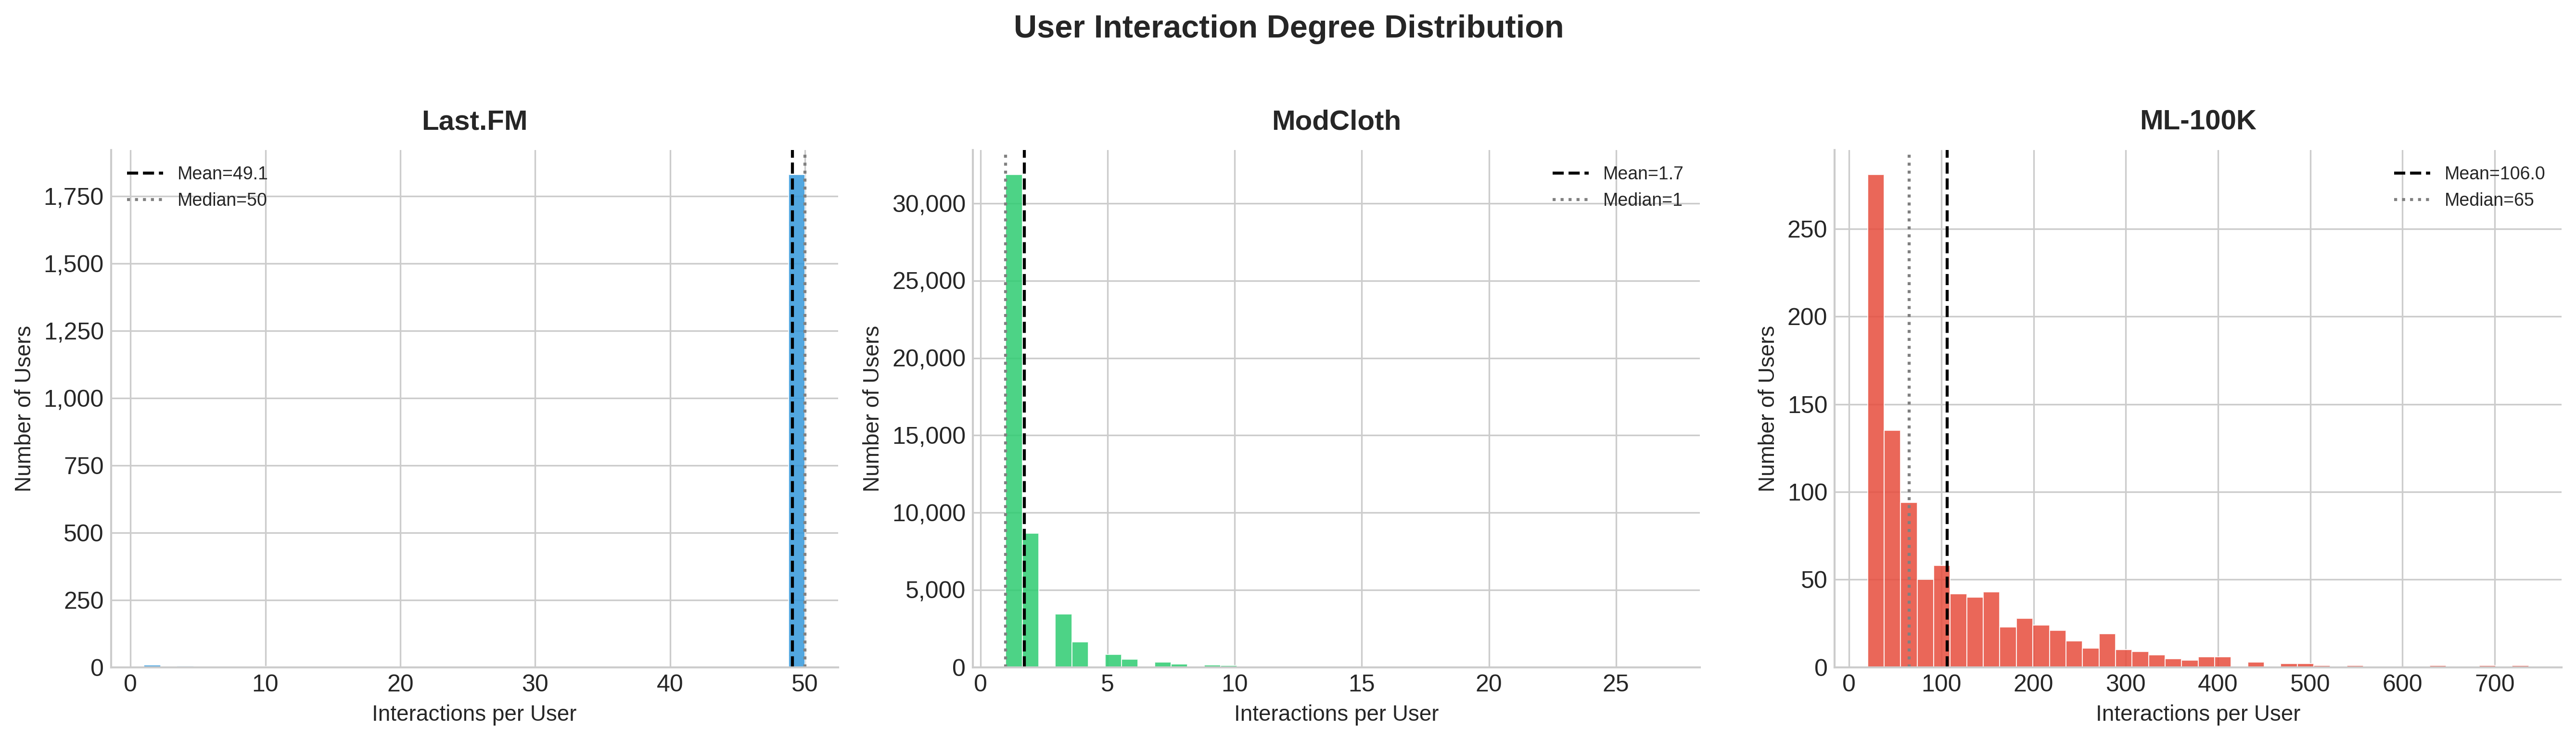


embedding_lastfm_ndcg10.png


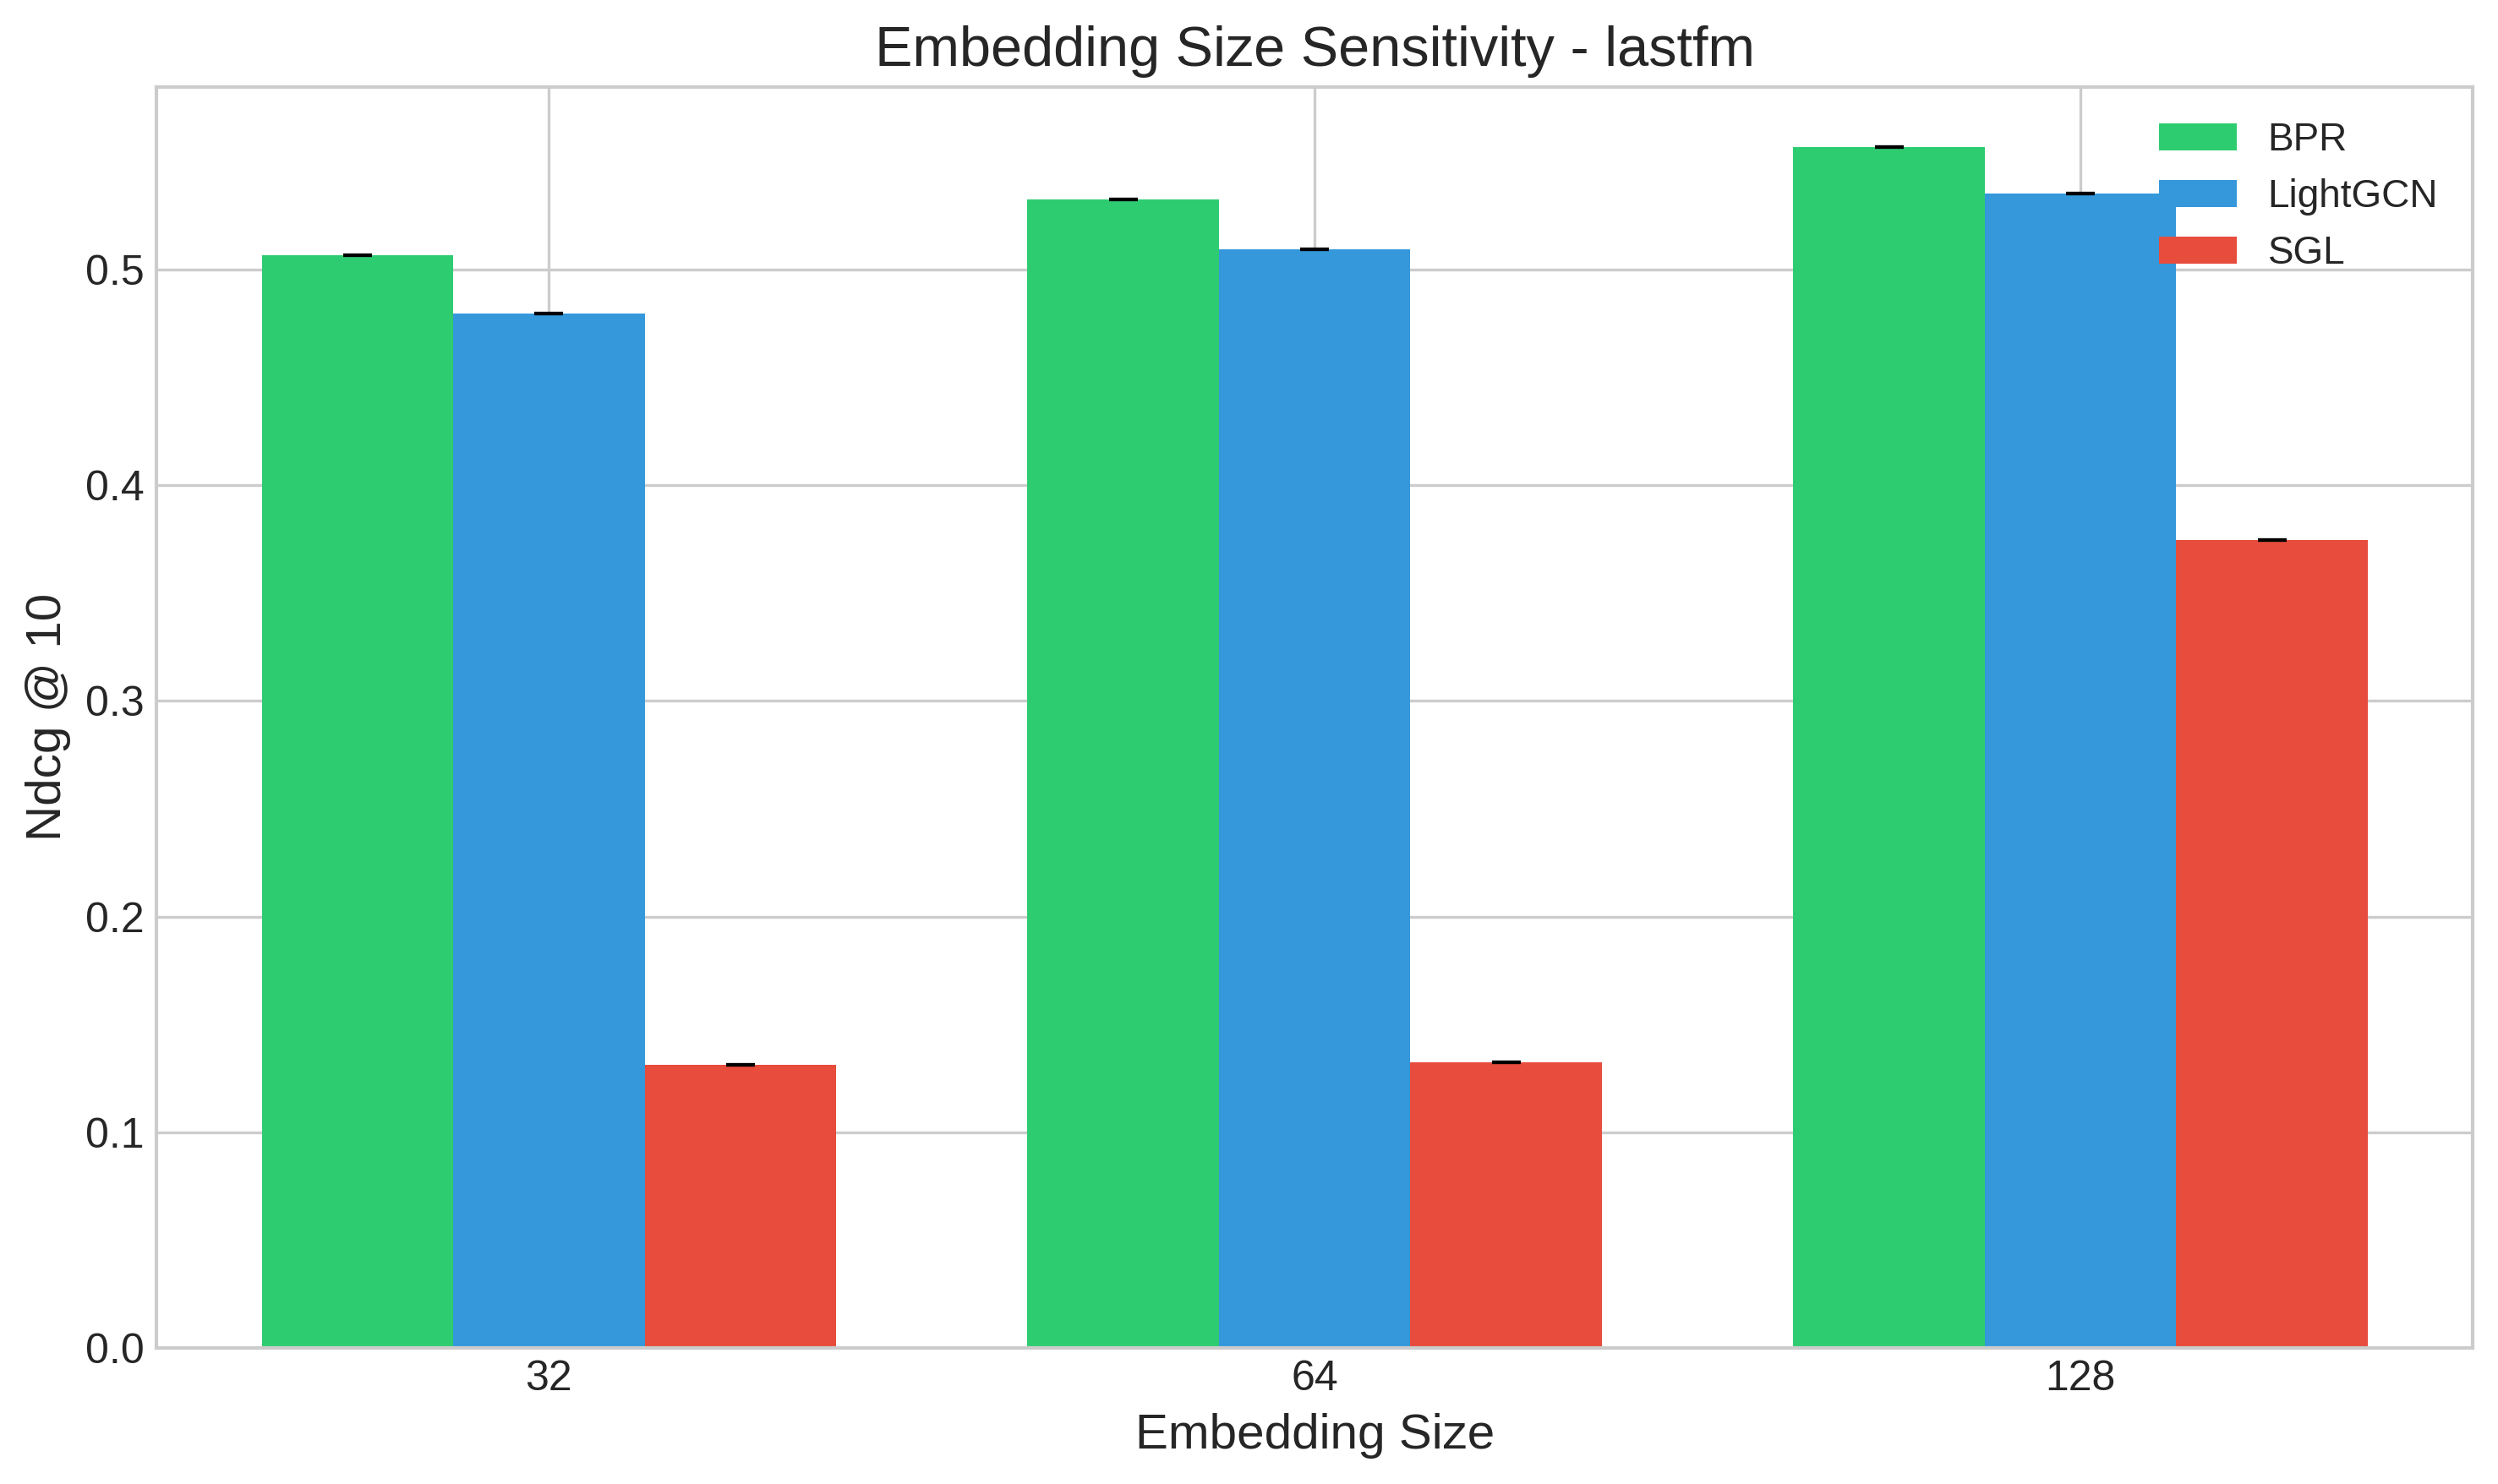


embedding_lastfm_recall10.png


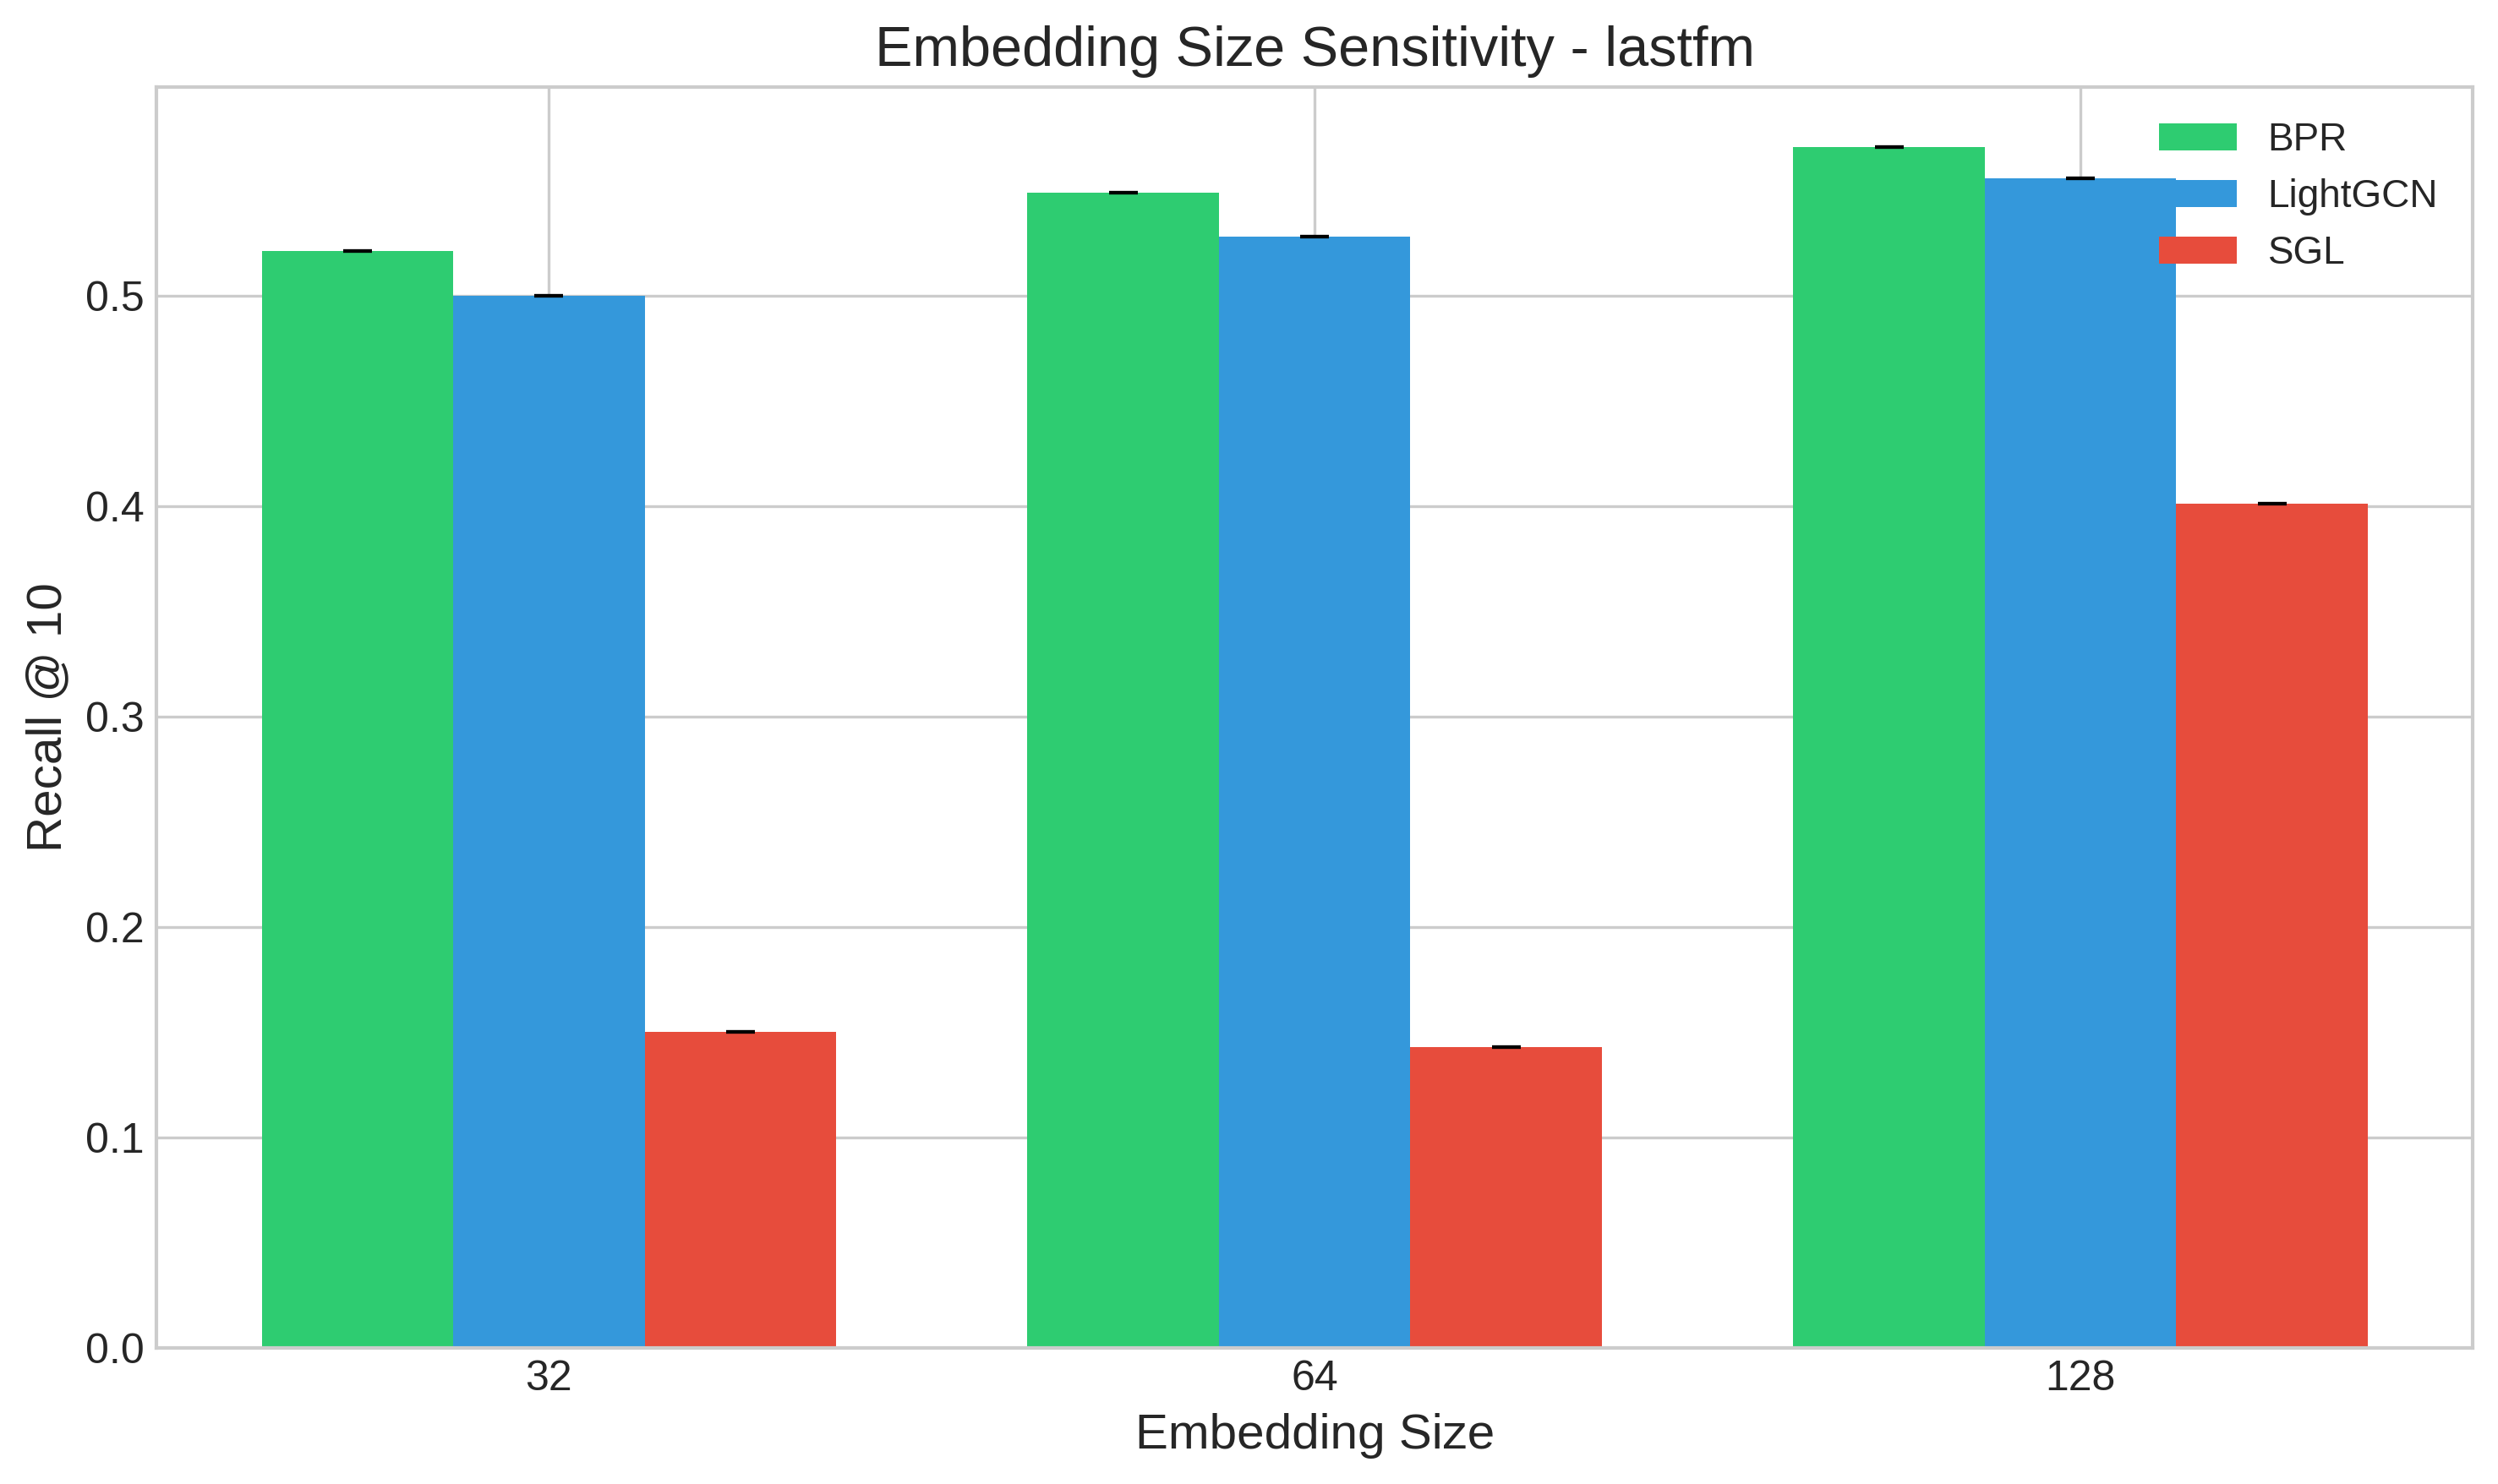


embedding_ml-100k_ndcg10.png


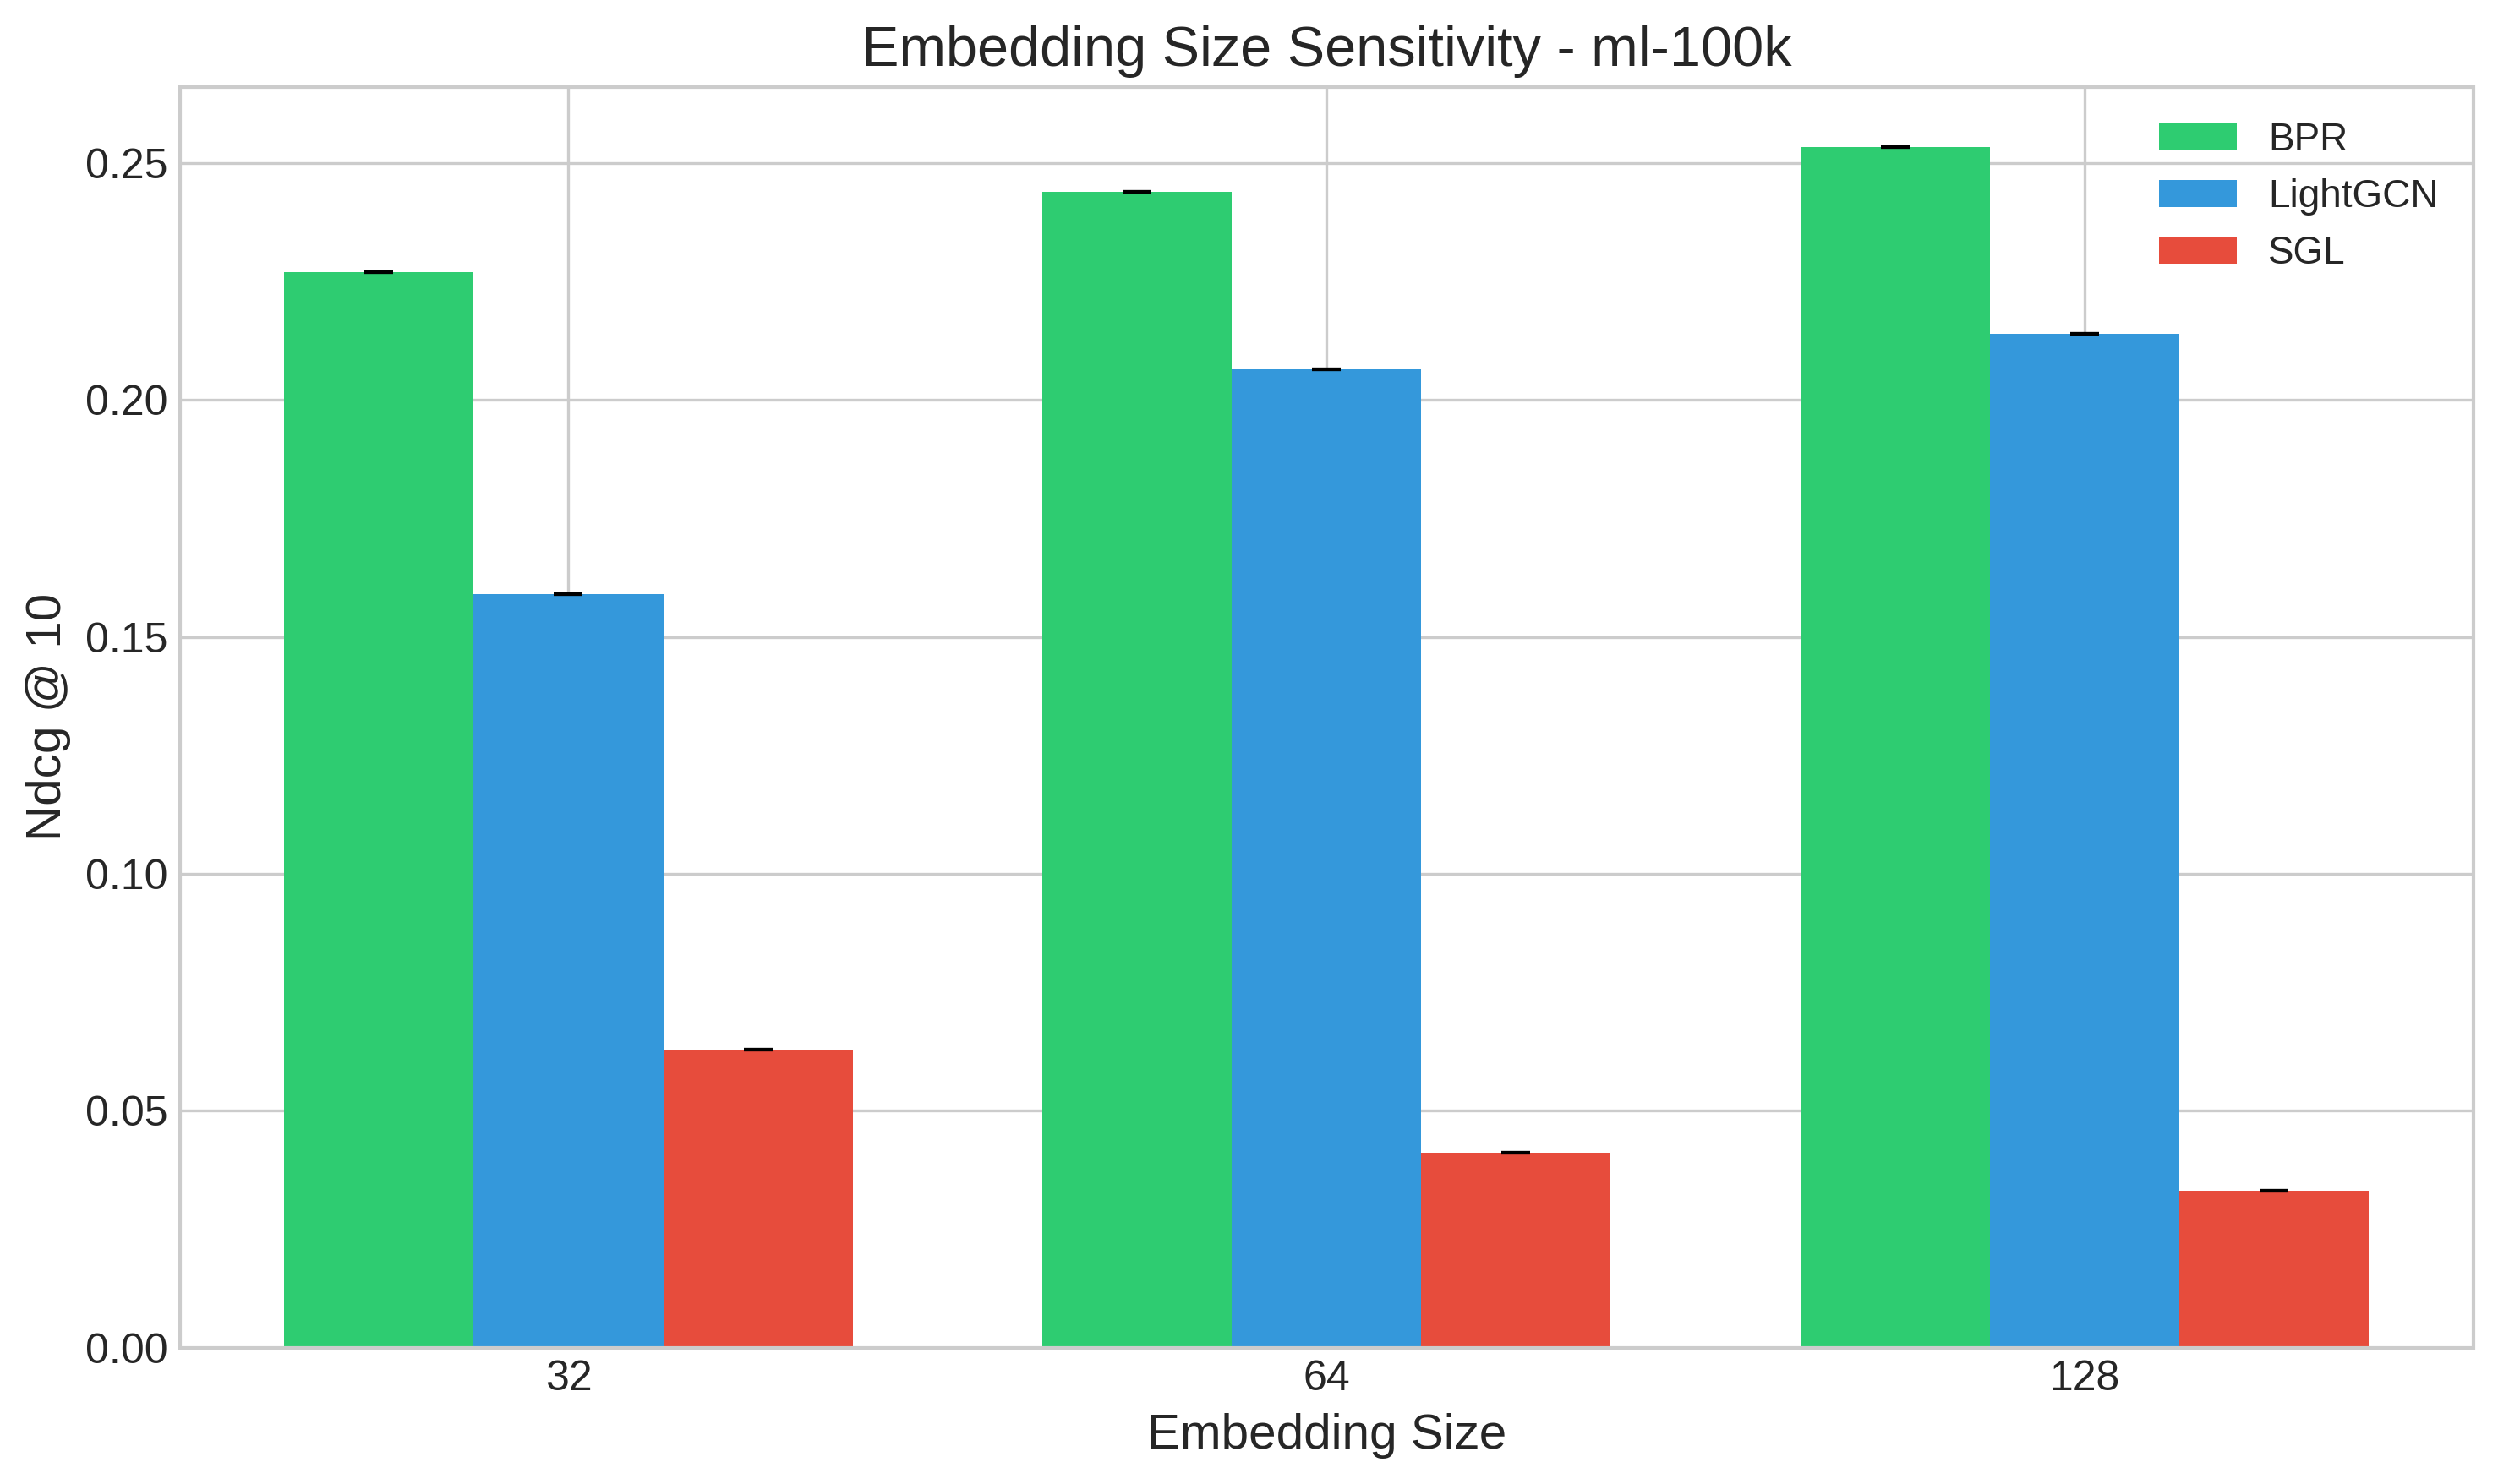


embedding_ml-100k_recall10.png


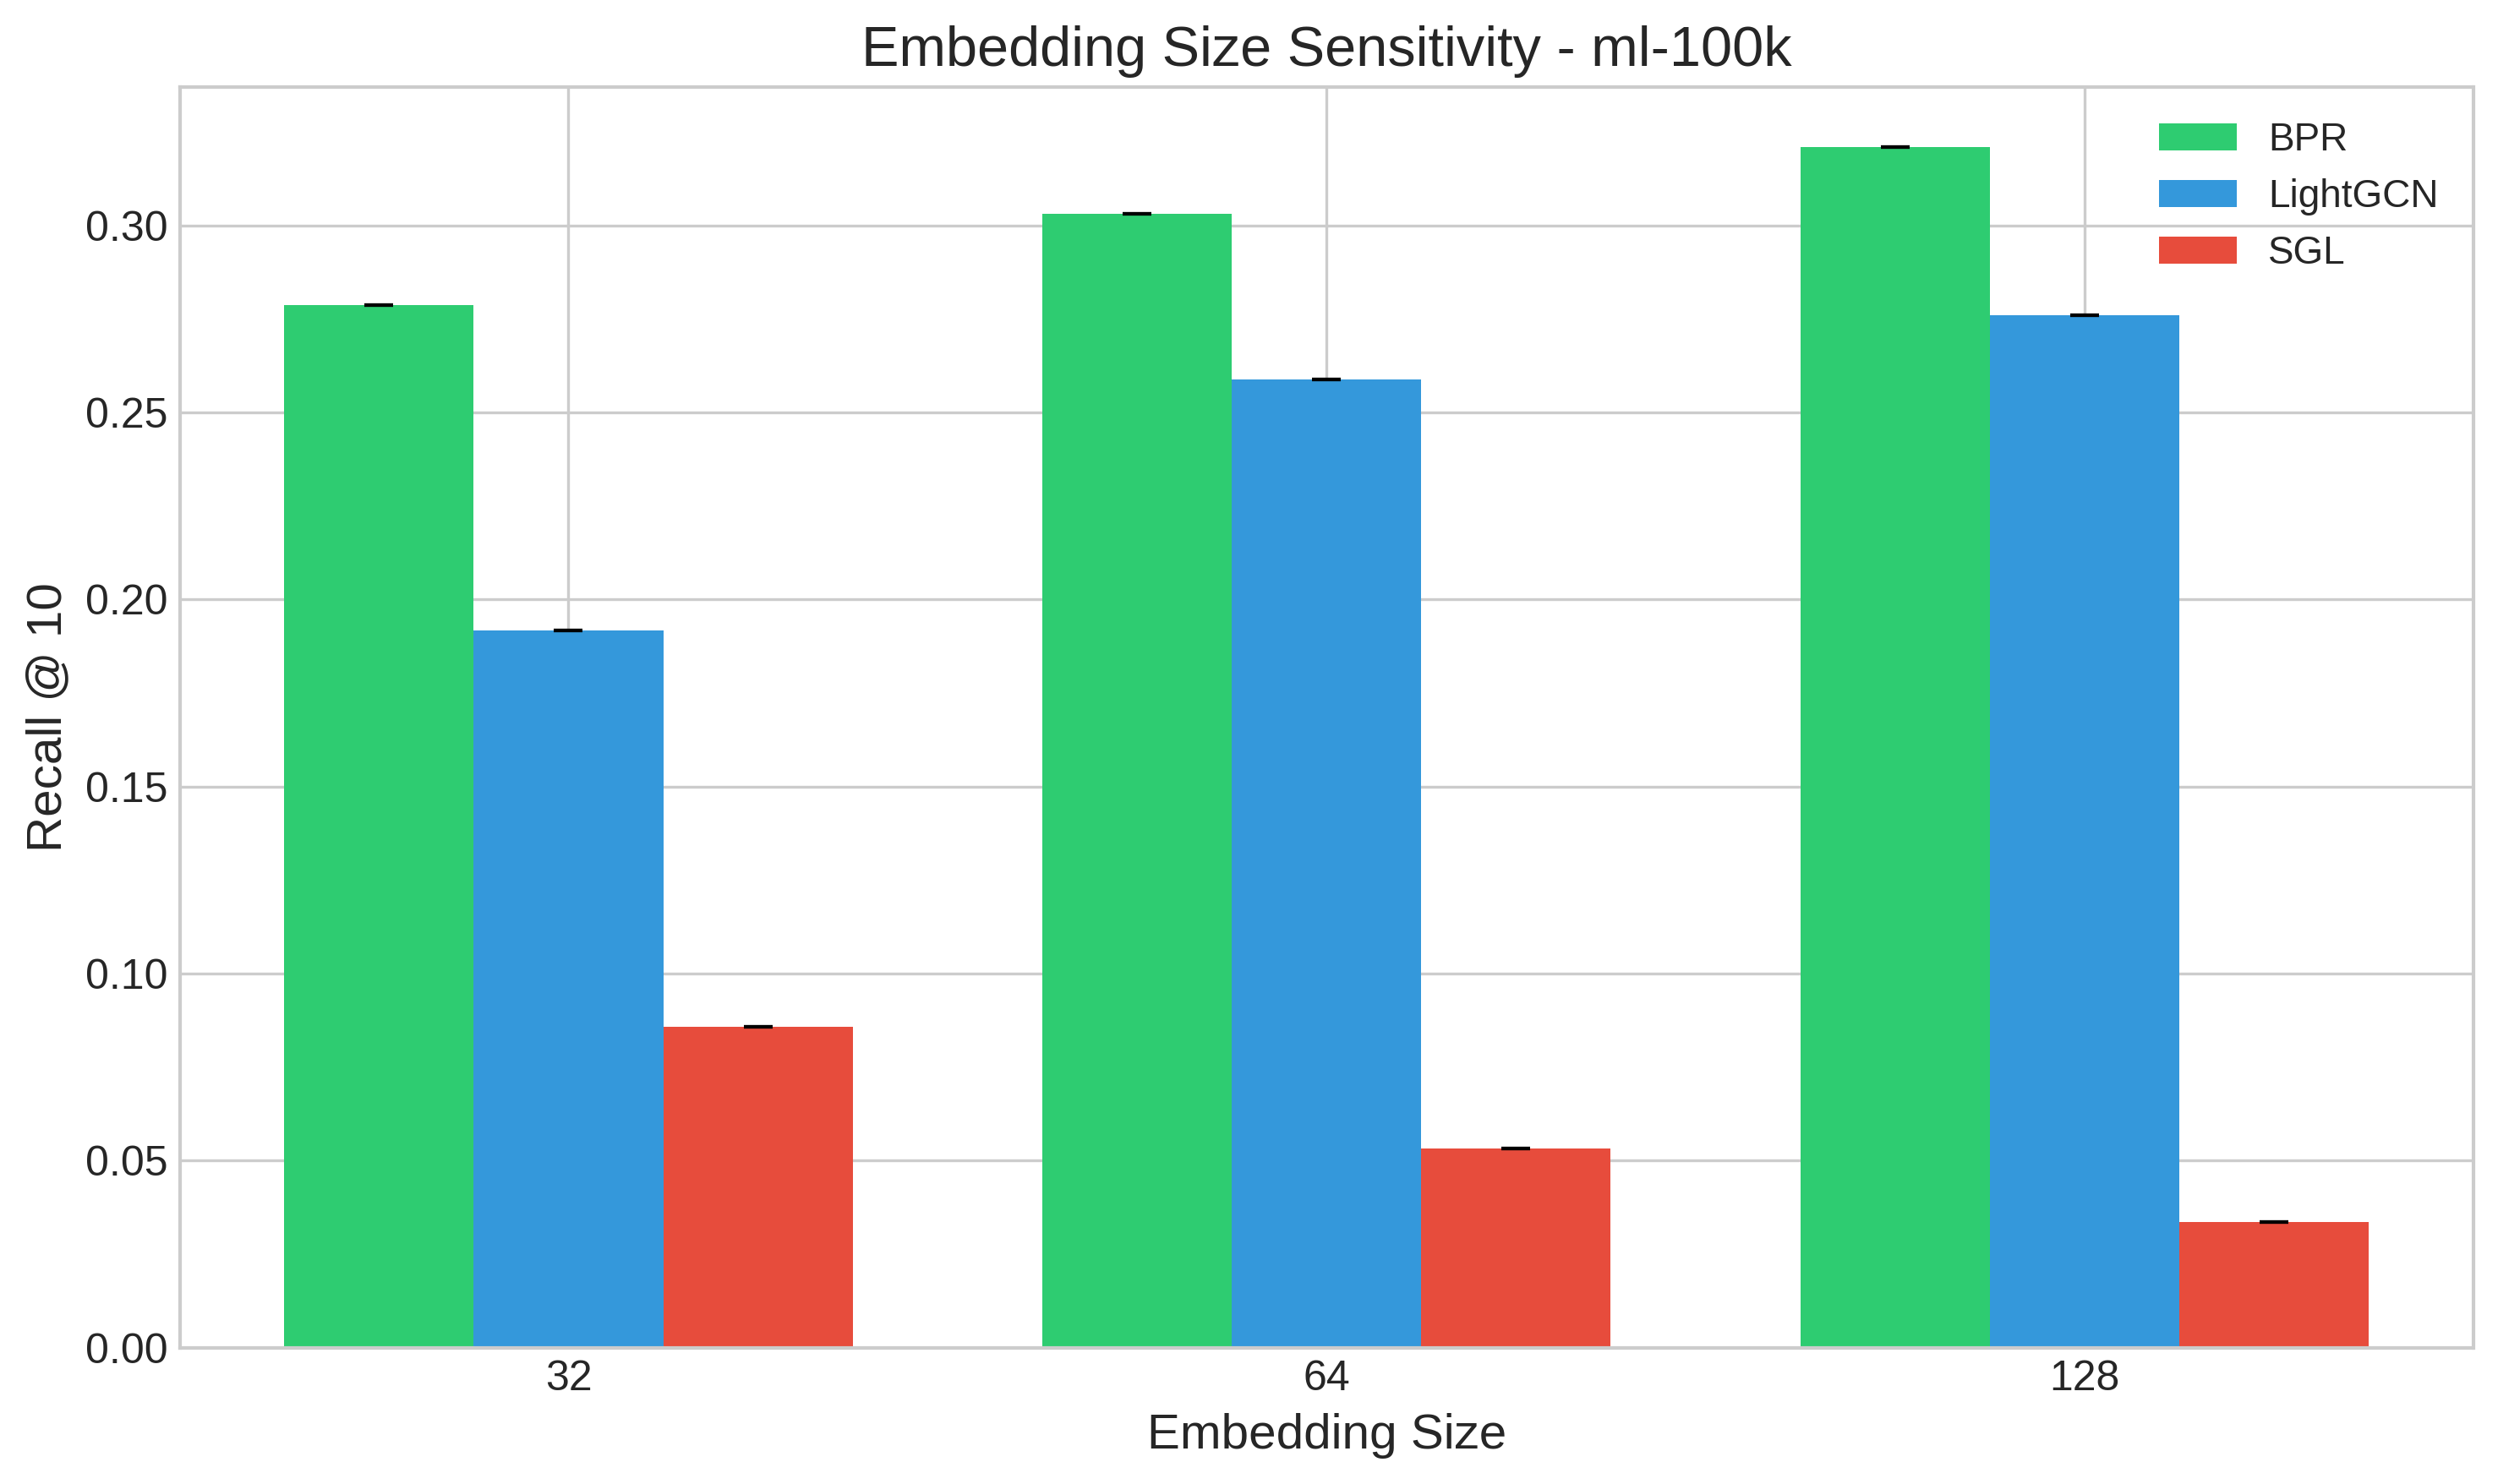


embedding_modcloth_ndcg10.png


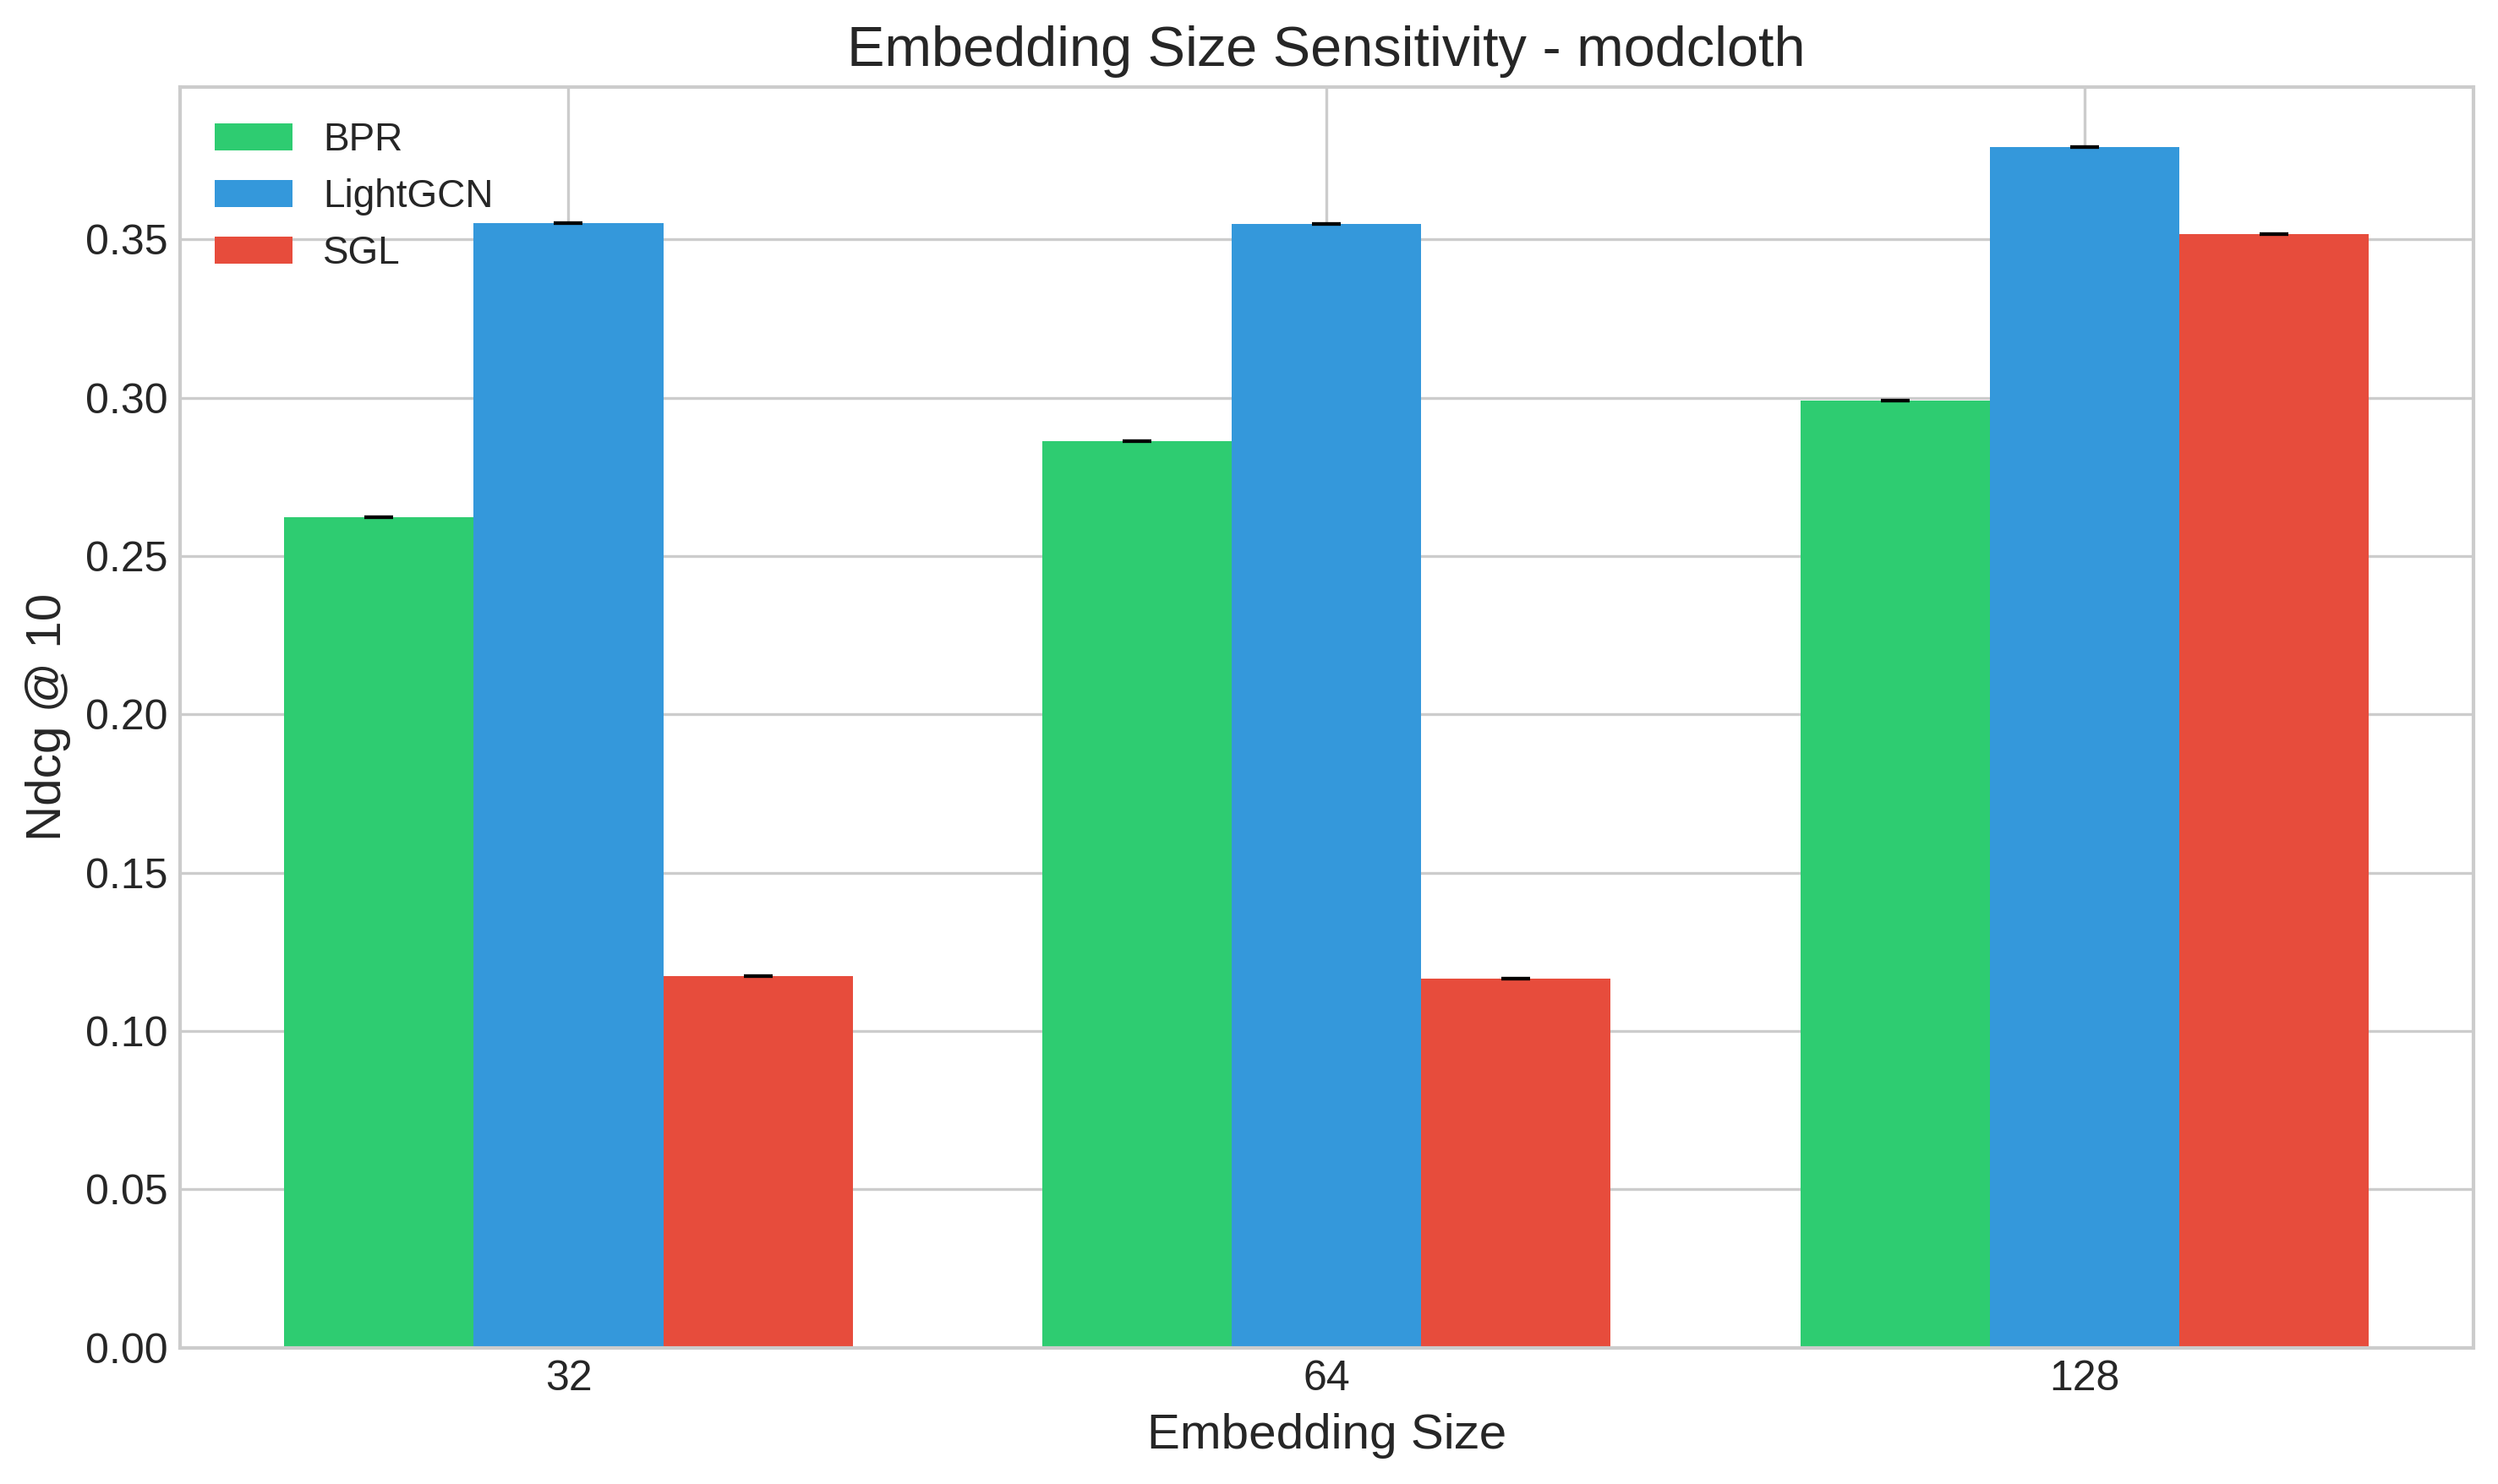


embedding_modcloth_recall10.png


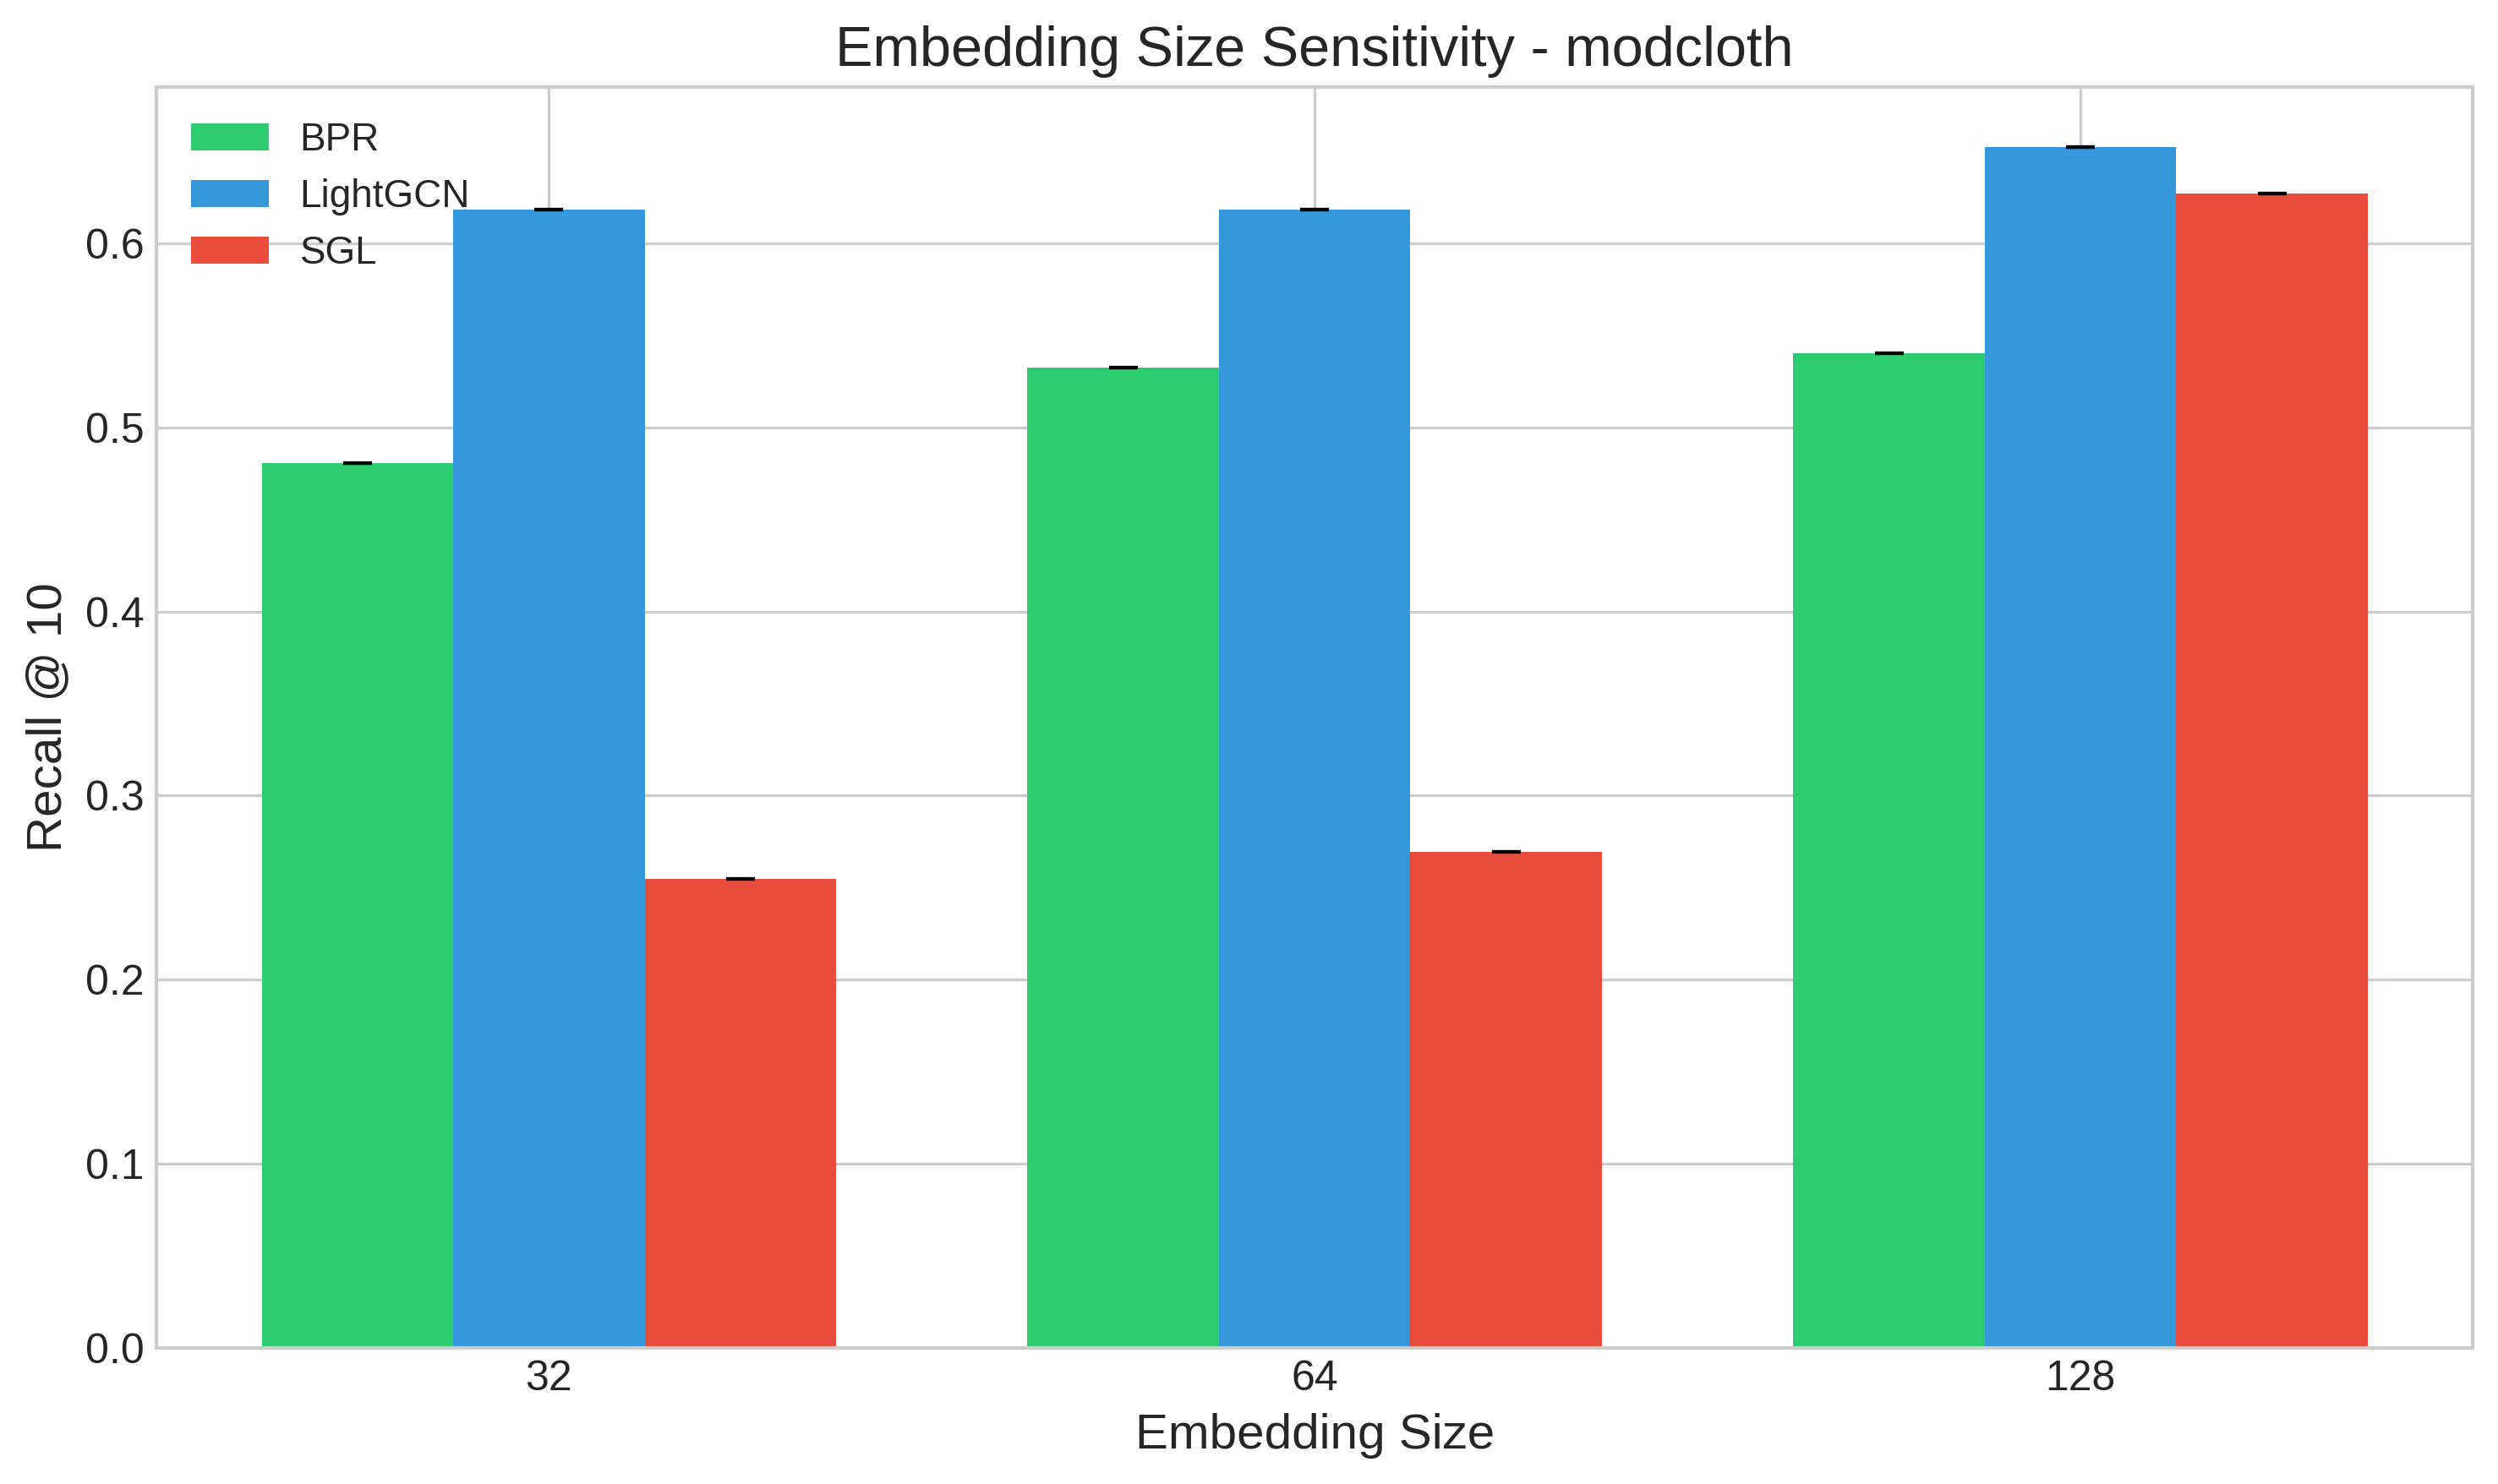


heatmap_ndcg10.png


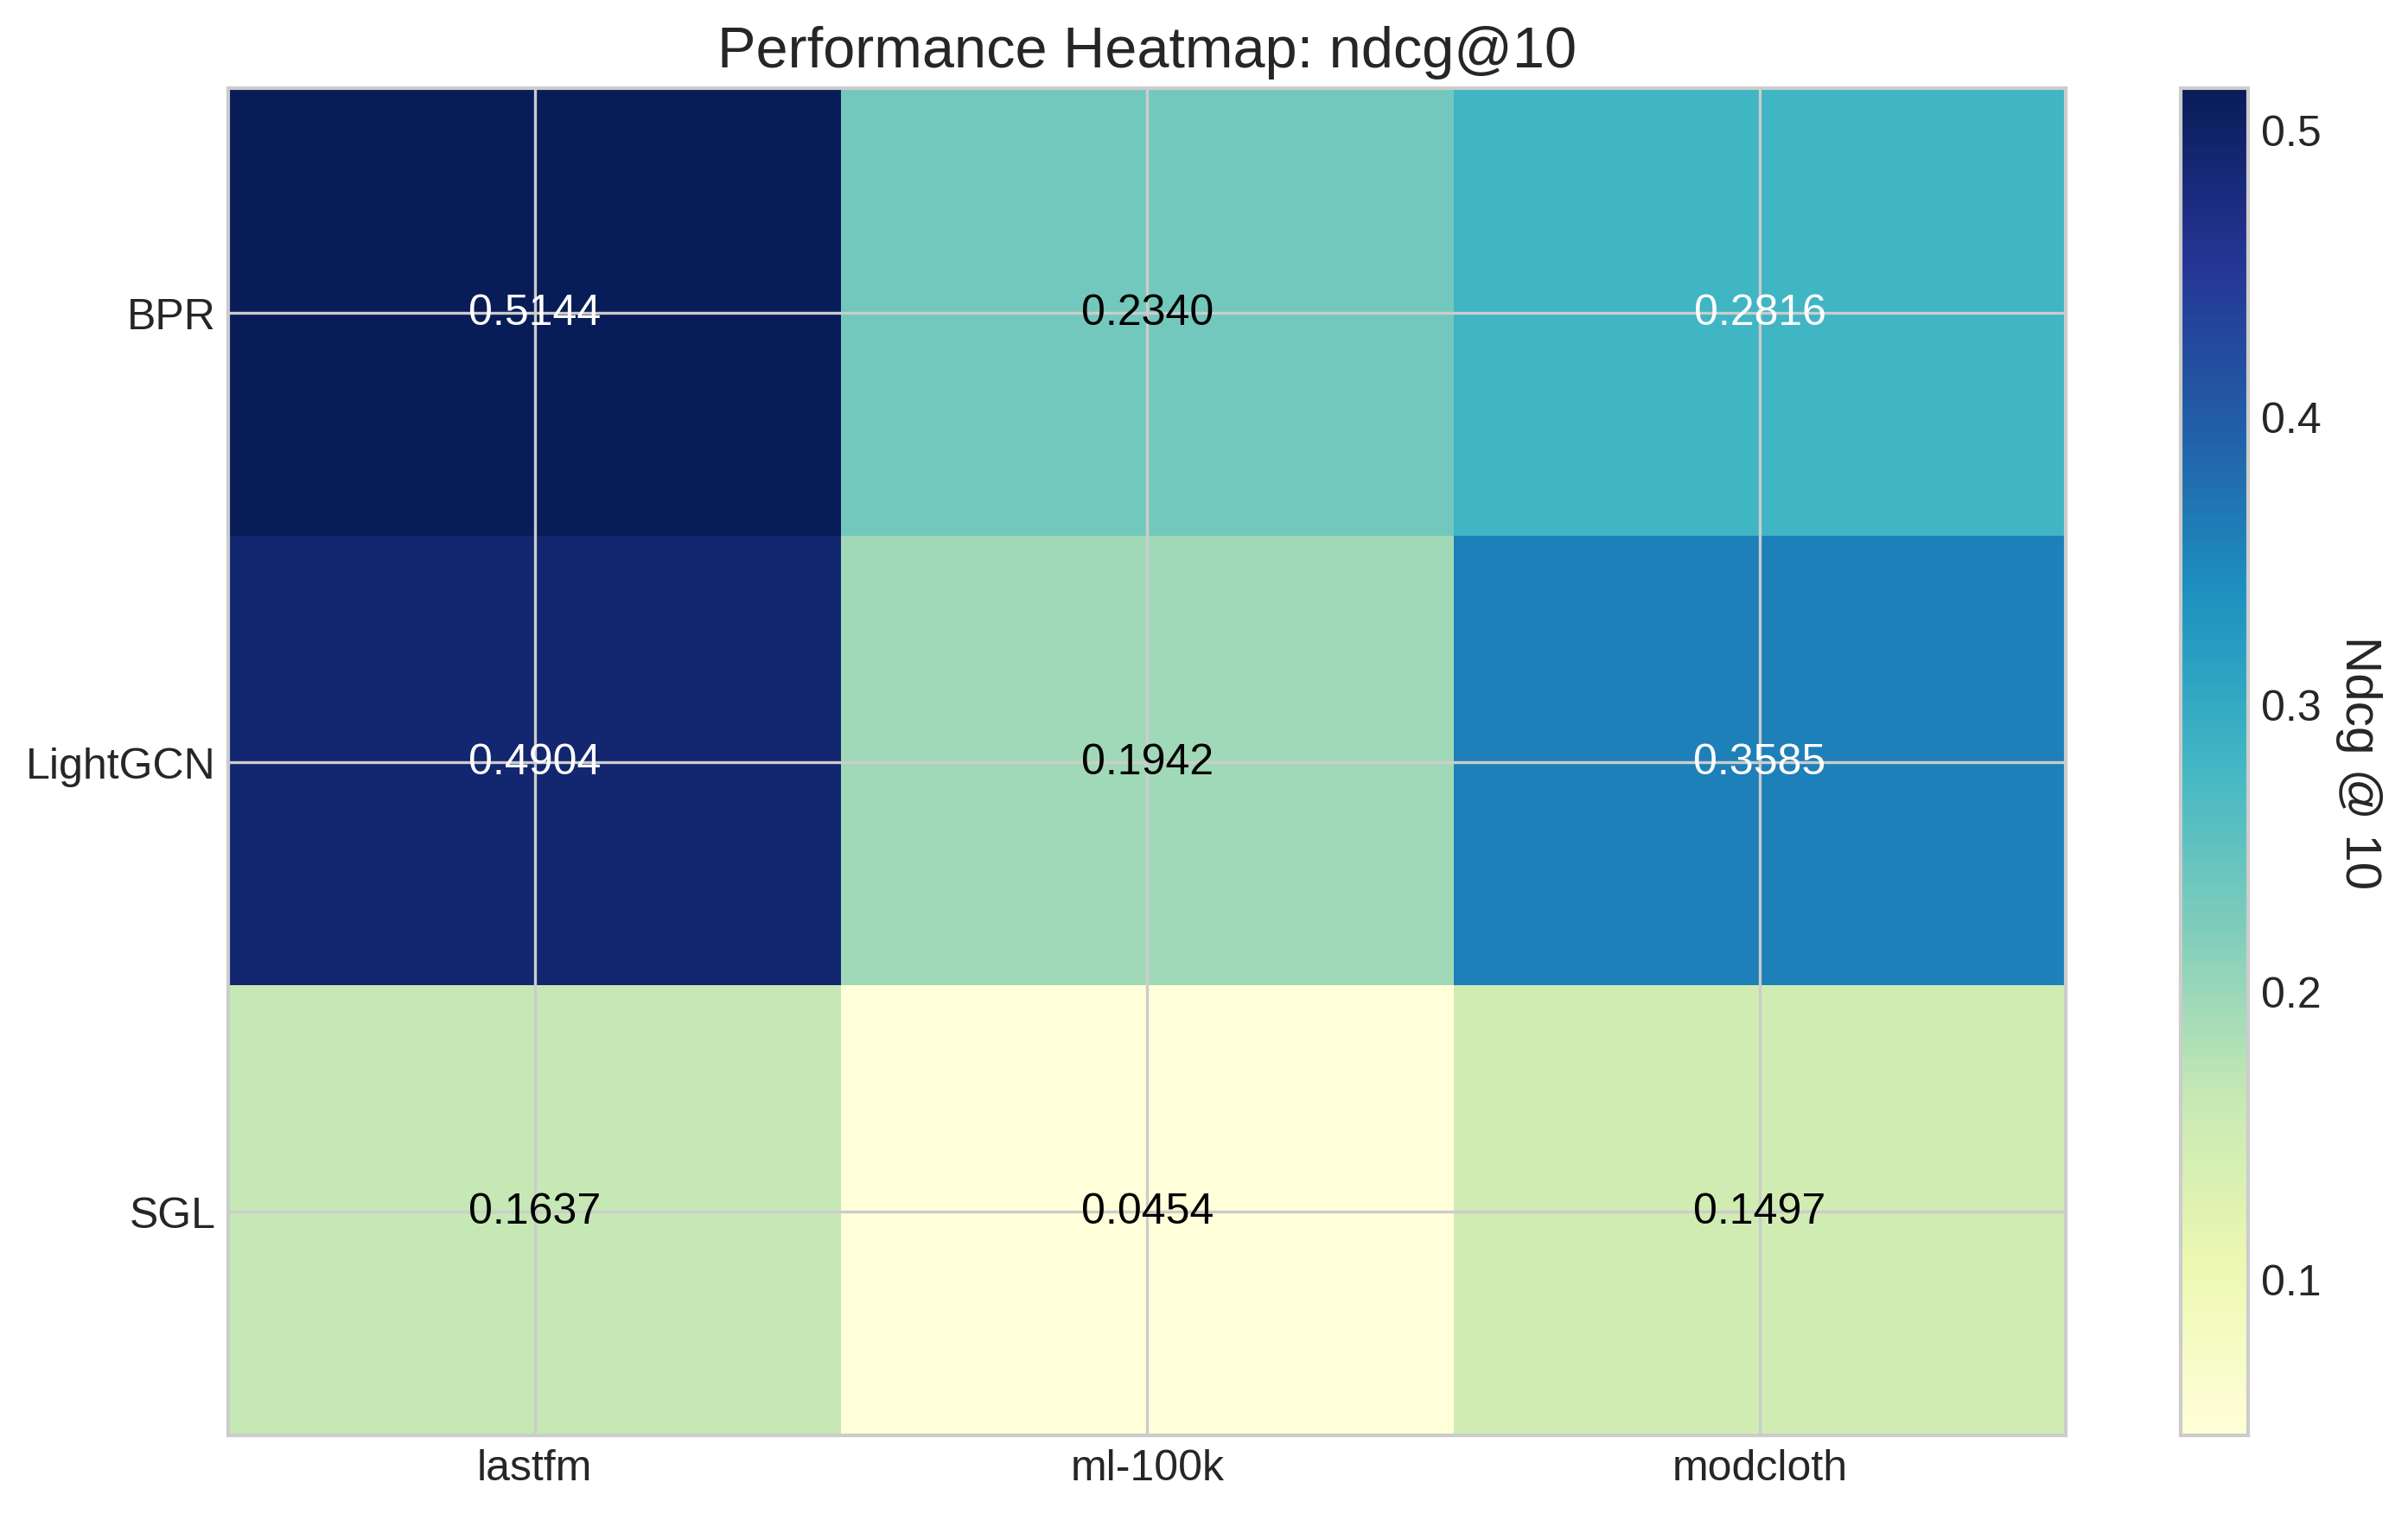


heatmap_recall10.png


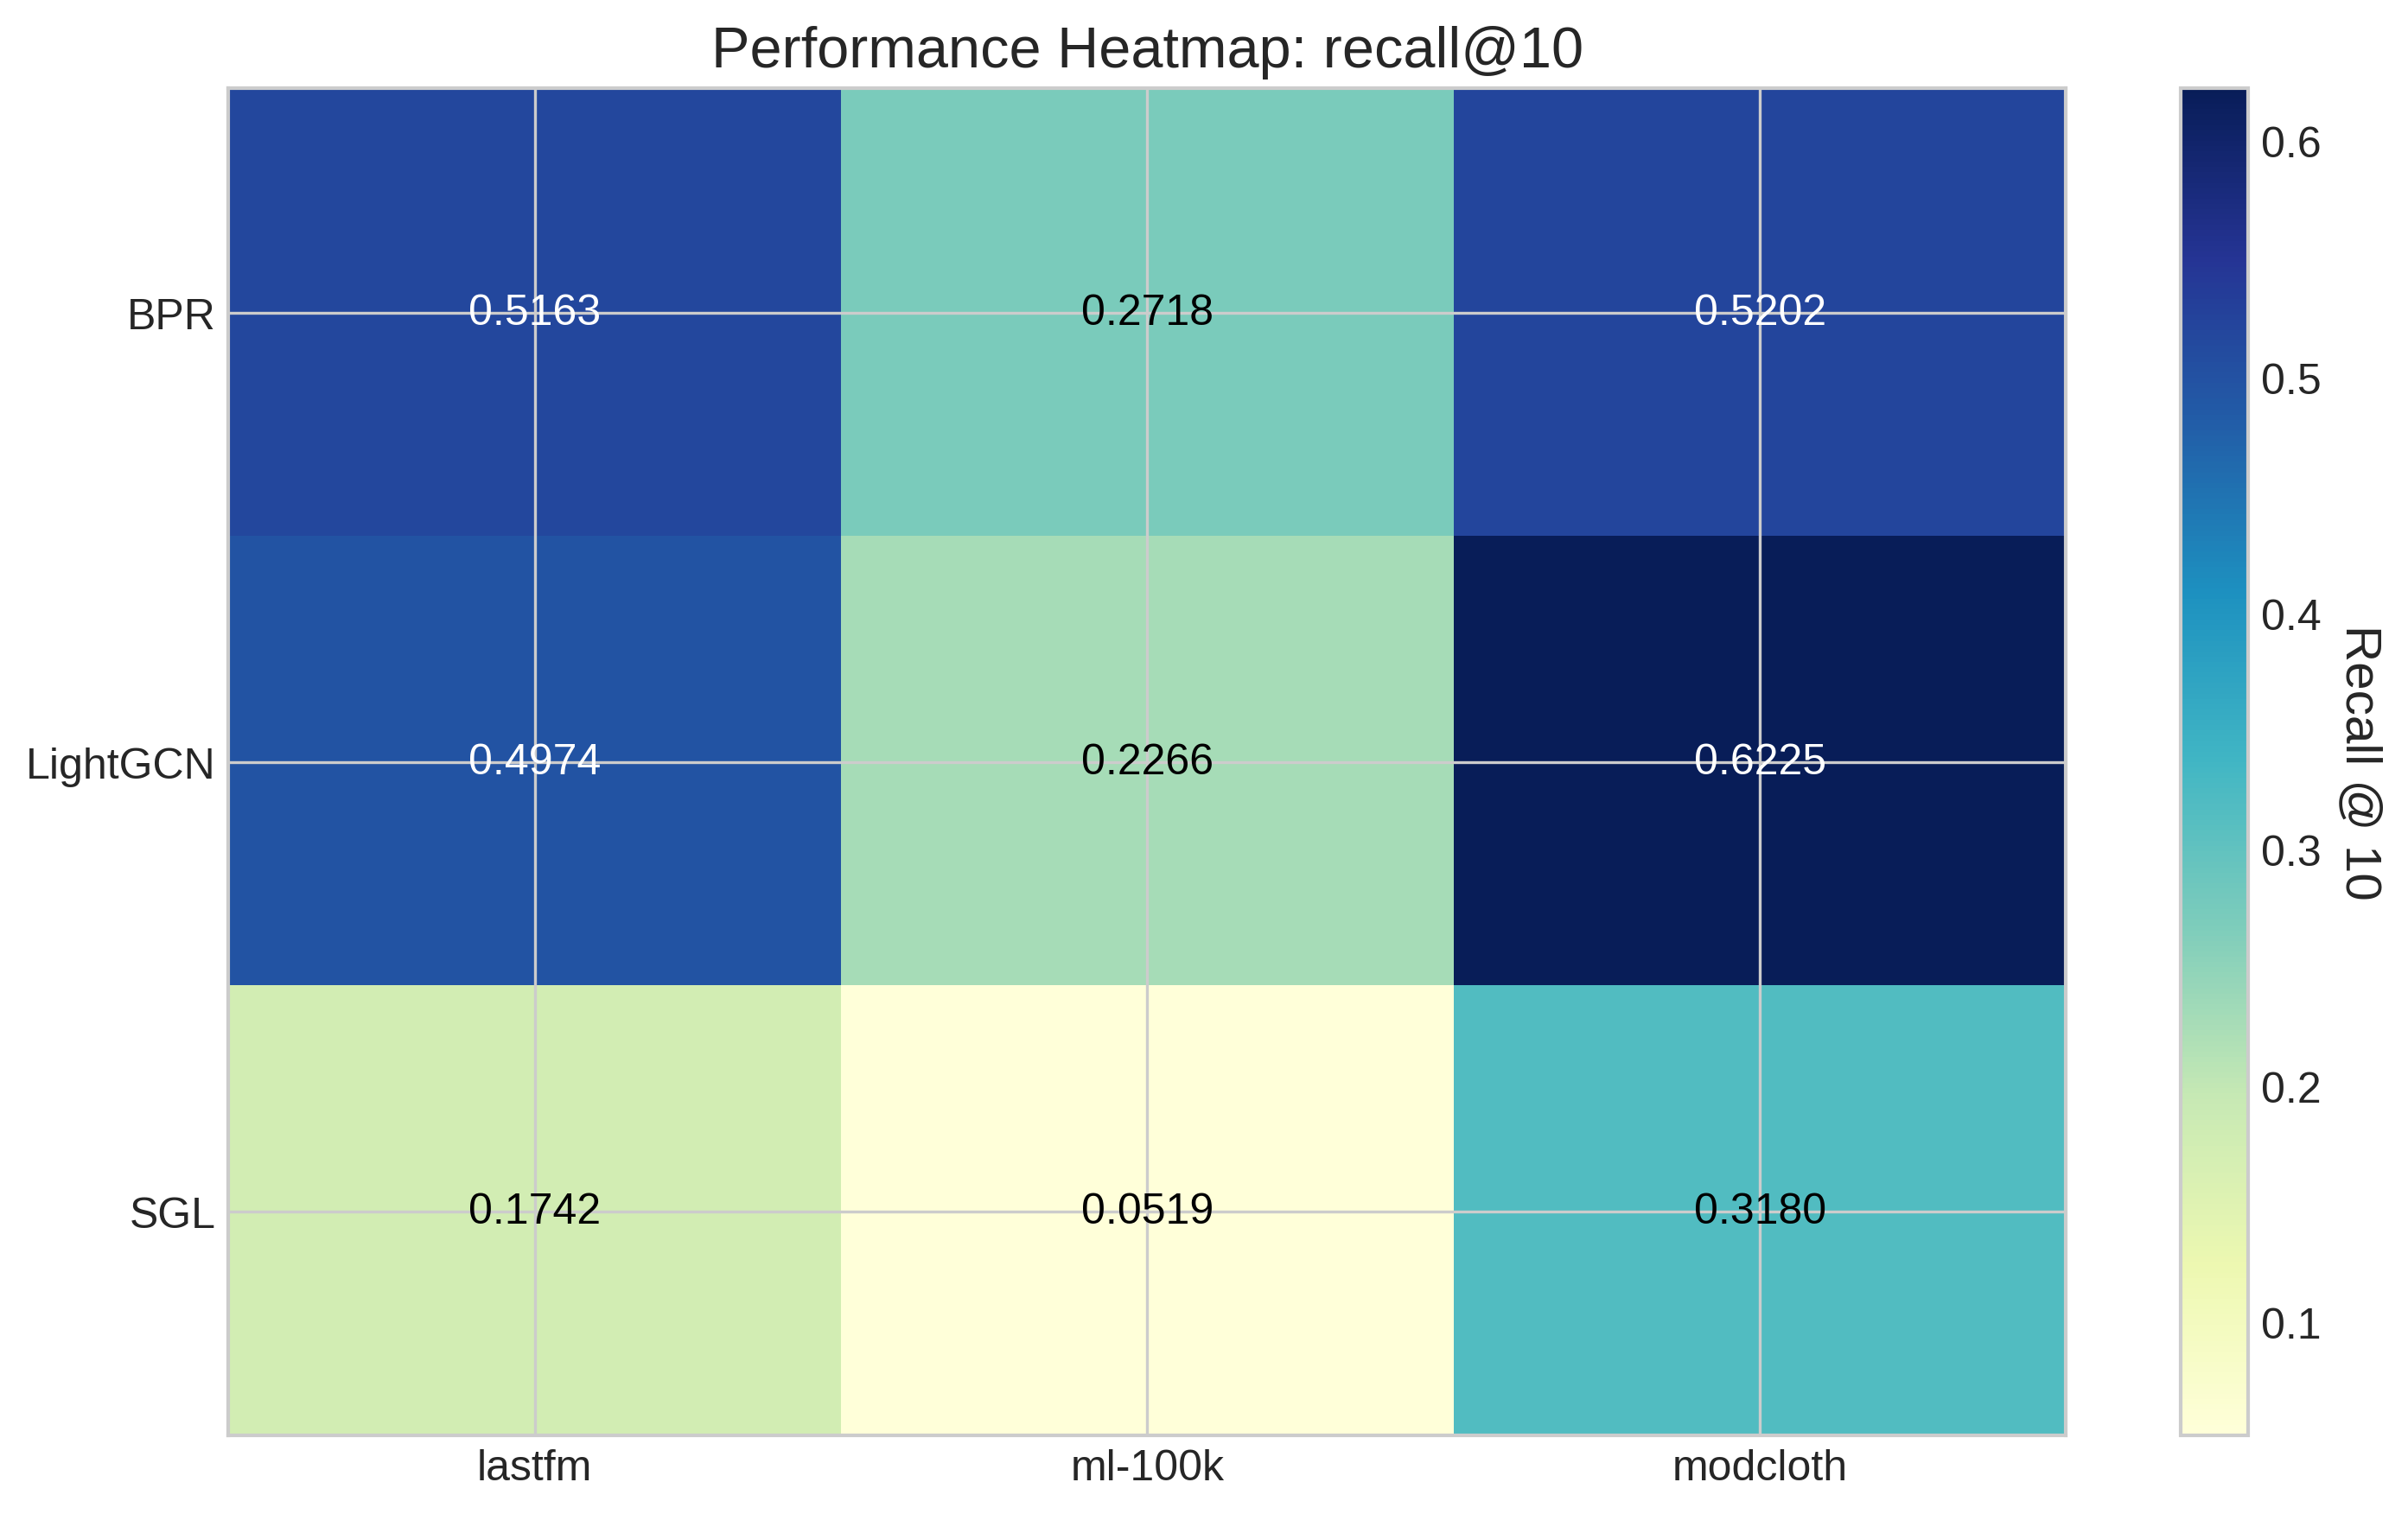


model_comparison.png


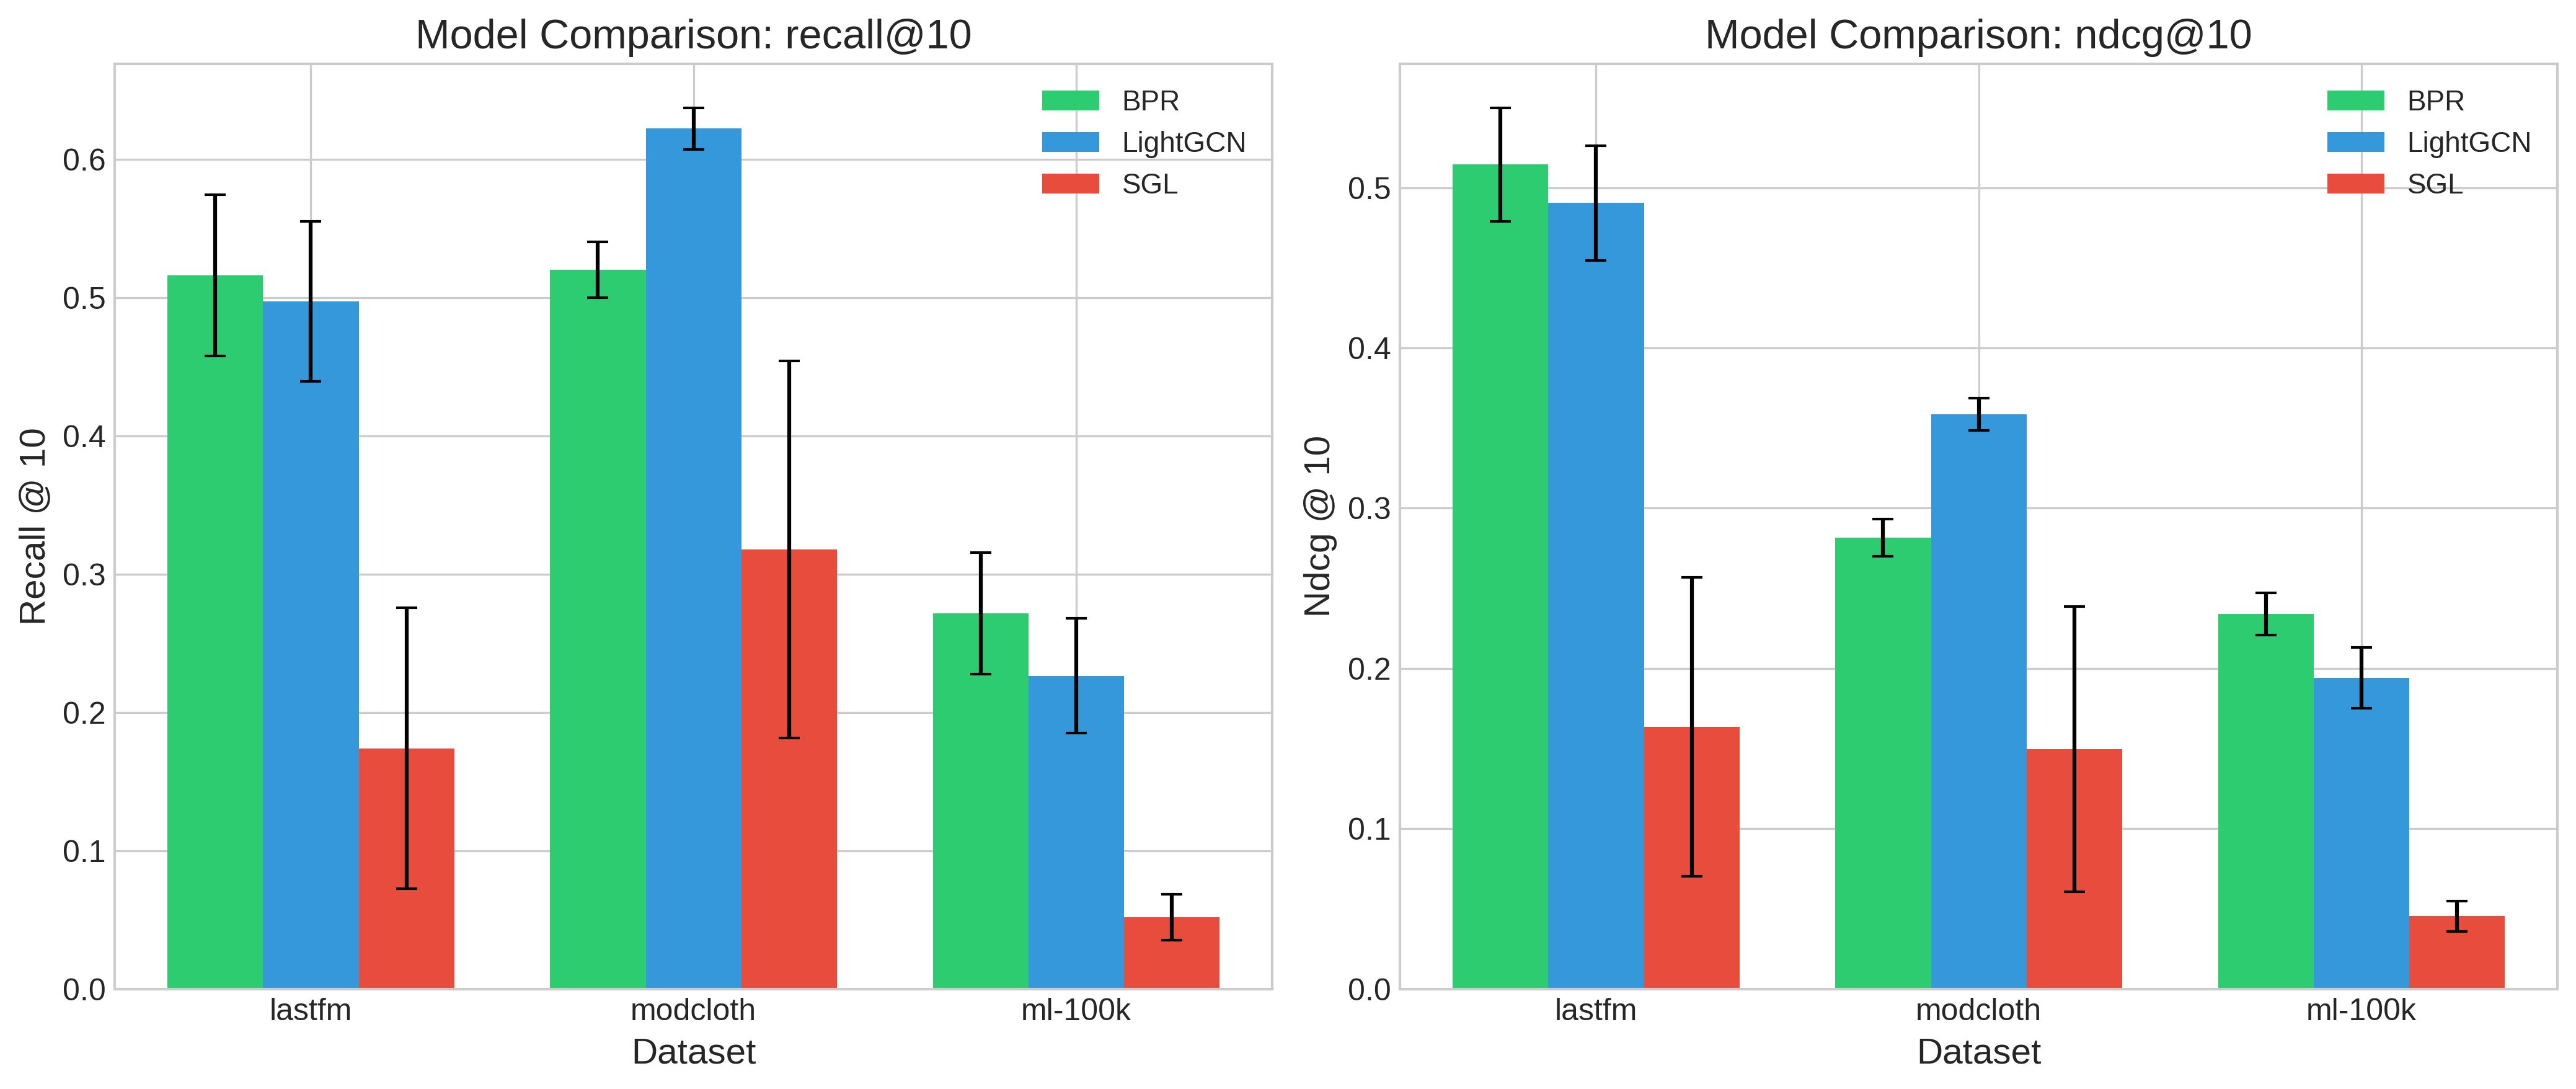


sparsity_lastfm_ndcg10.png


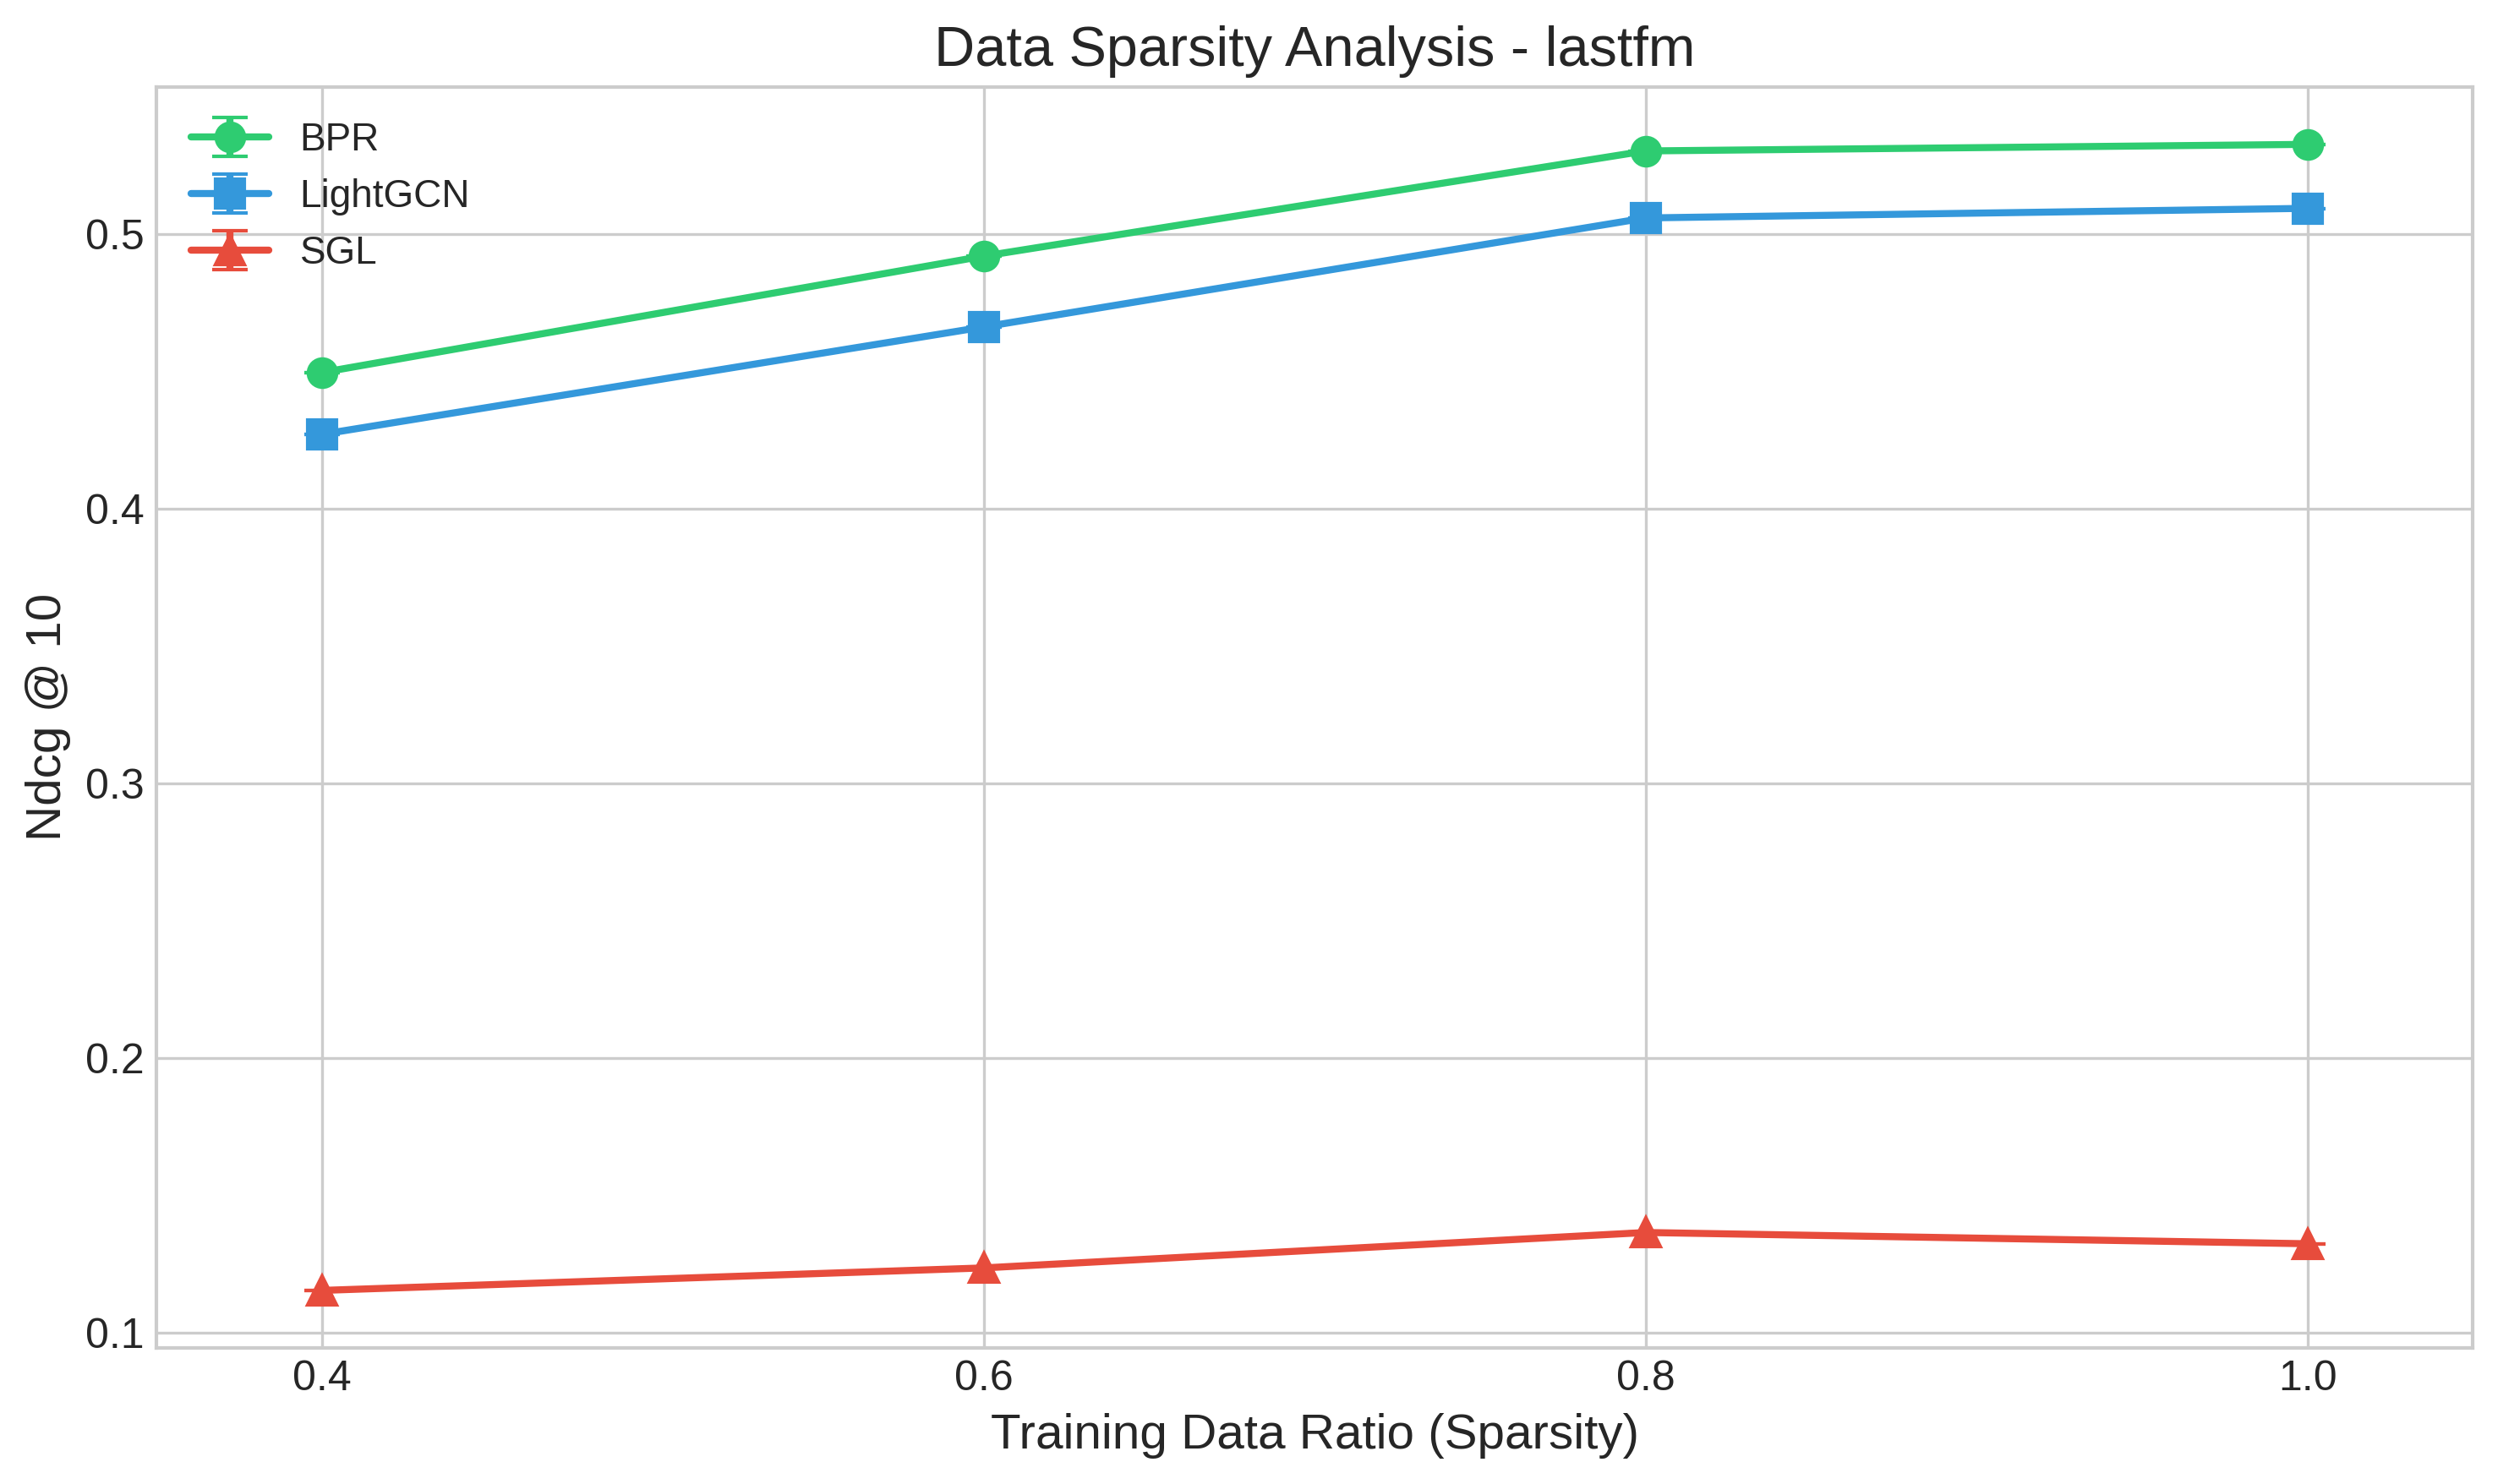


sparsity_lastfm_recall10.png


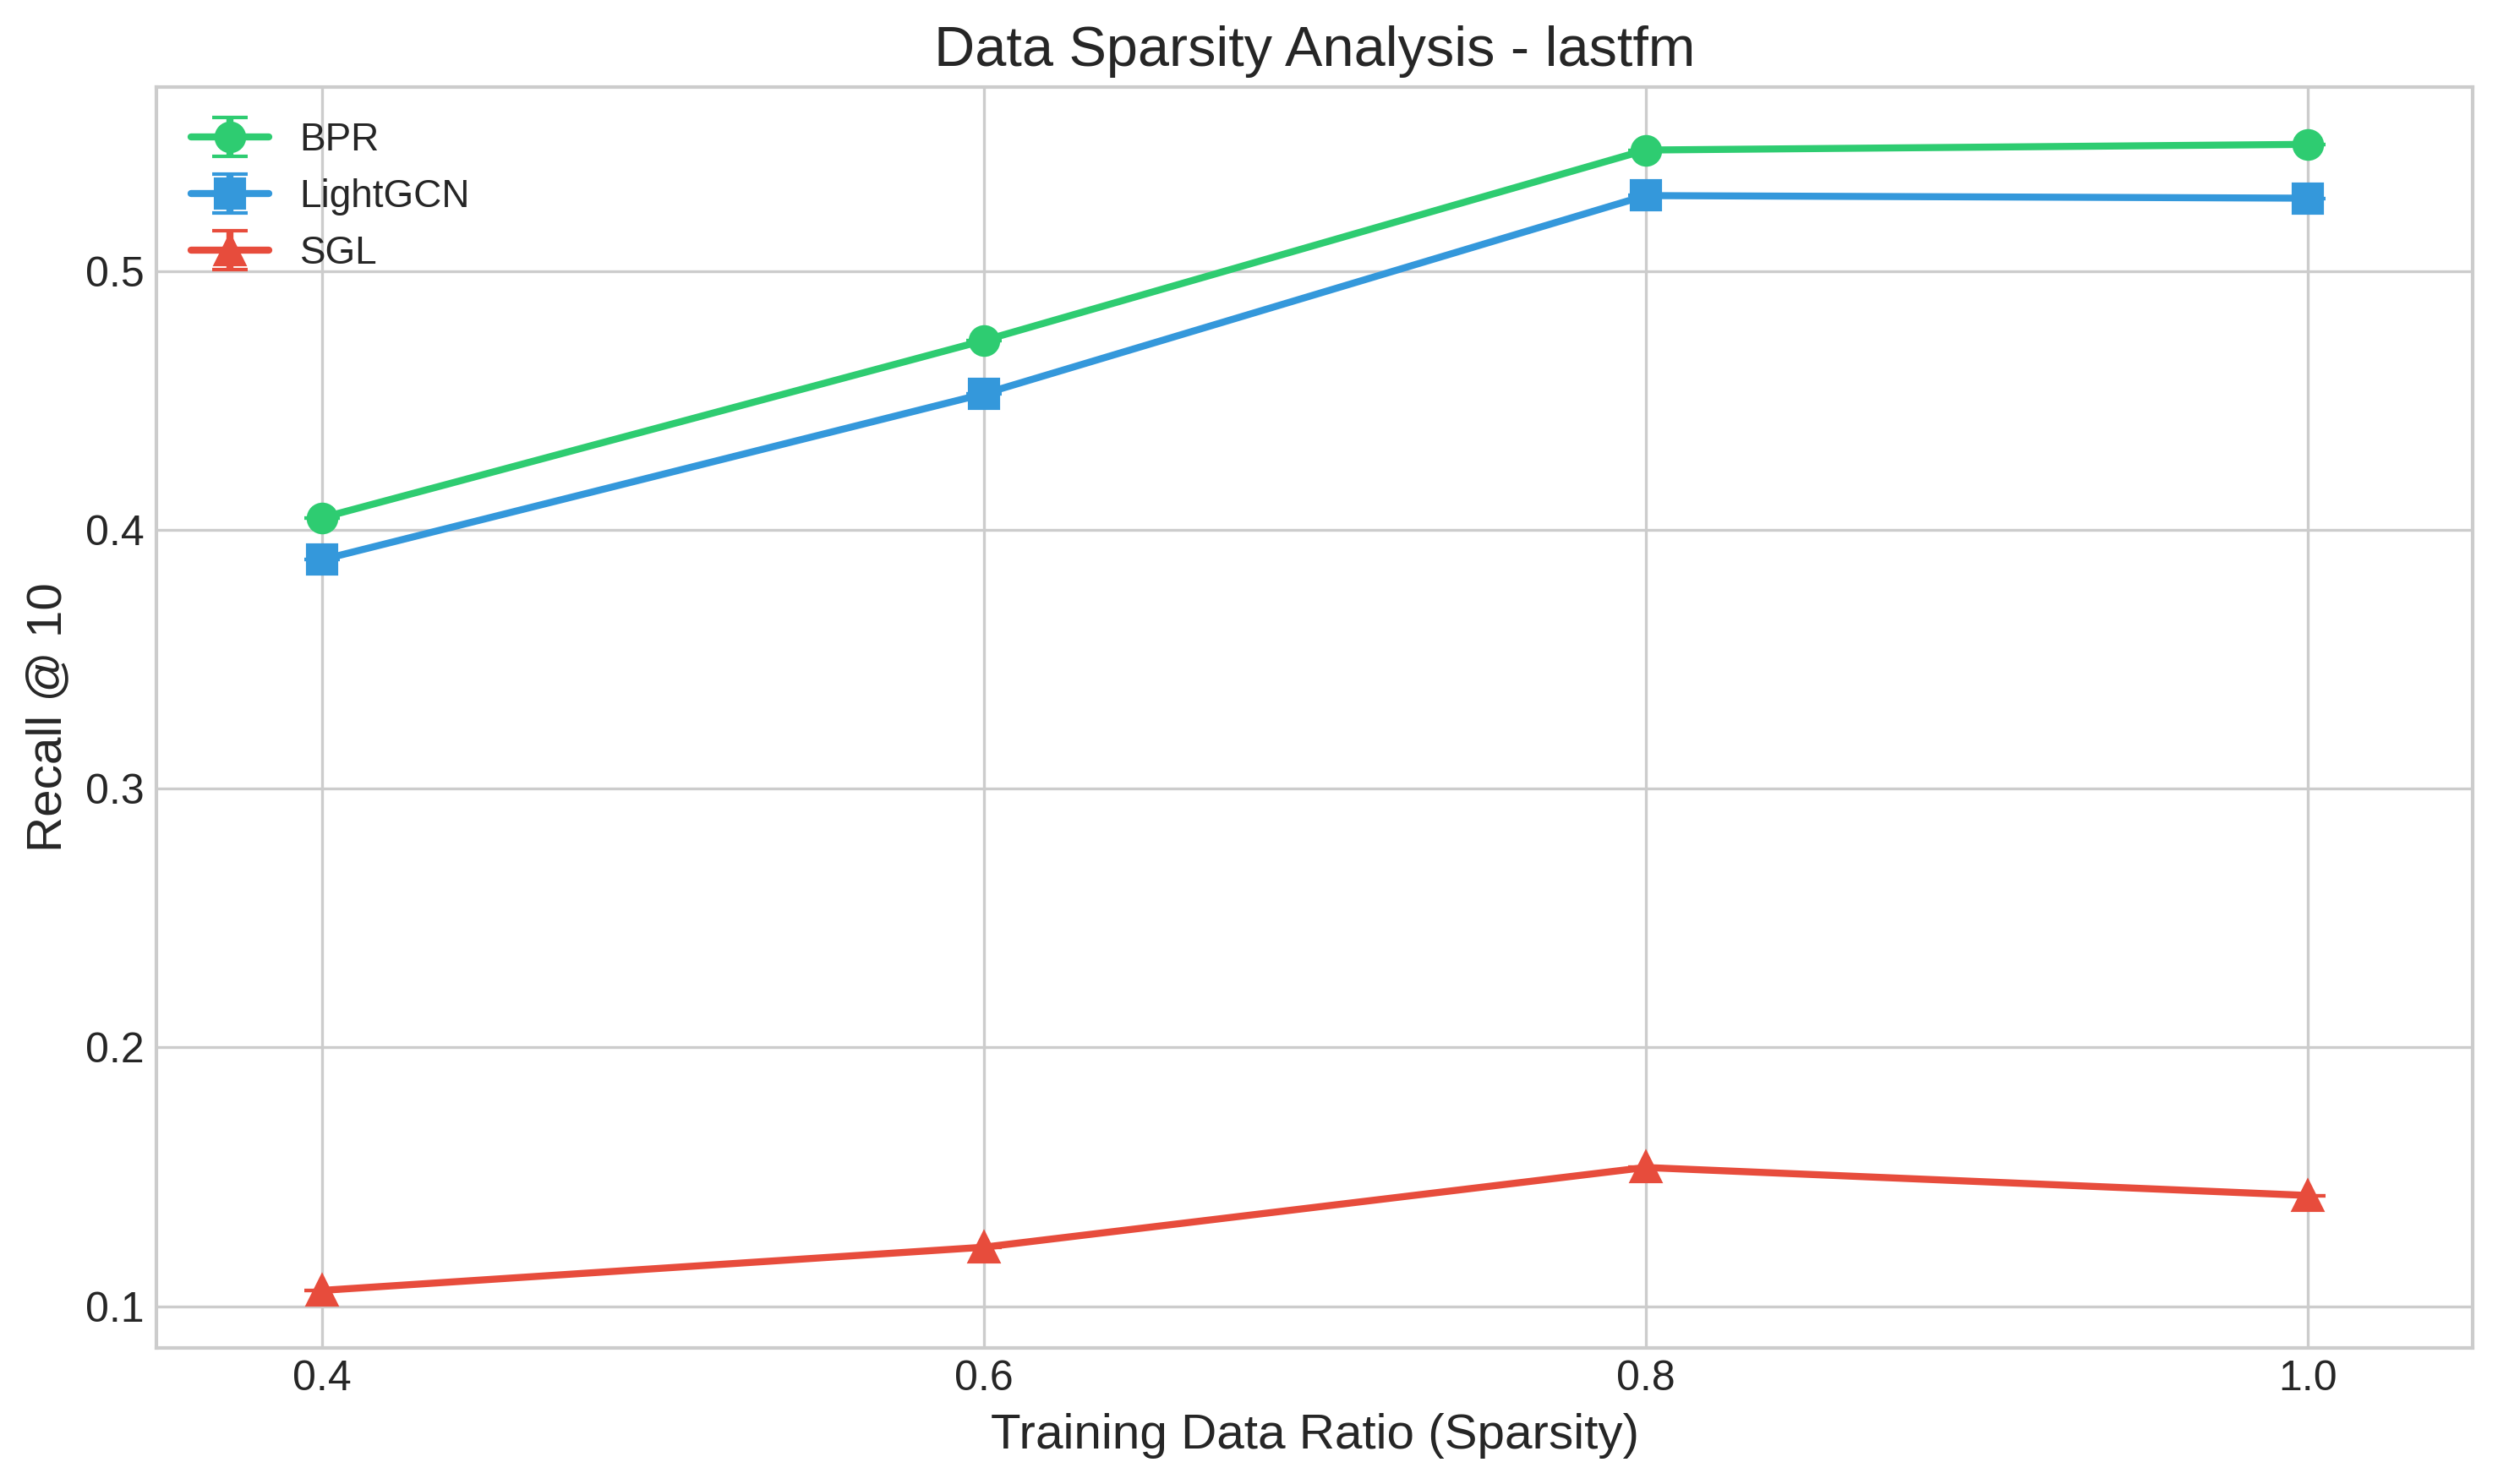


sparsity_ml-100k_ndcg10.png


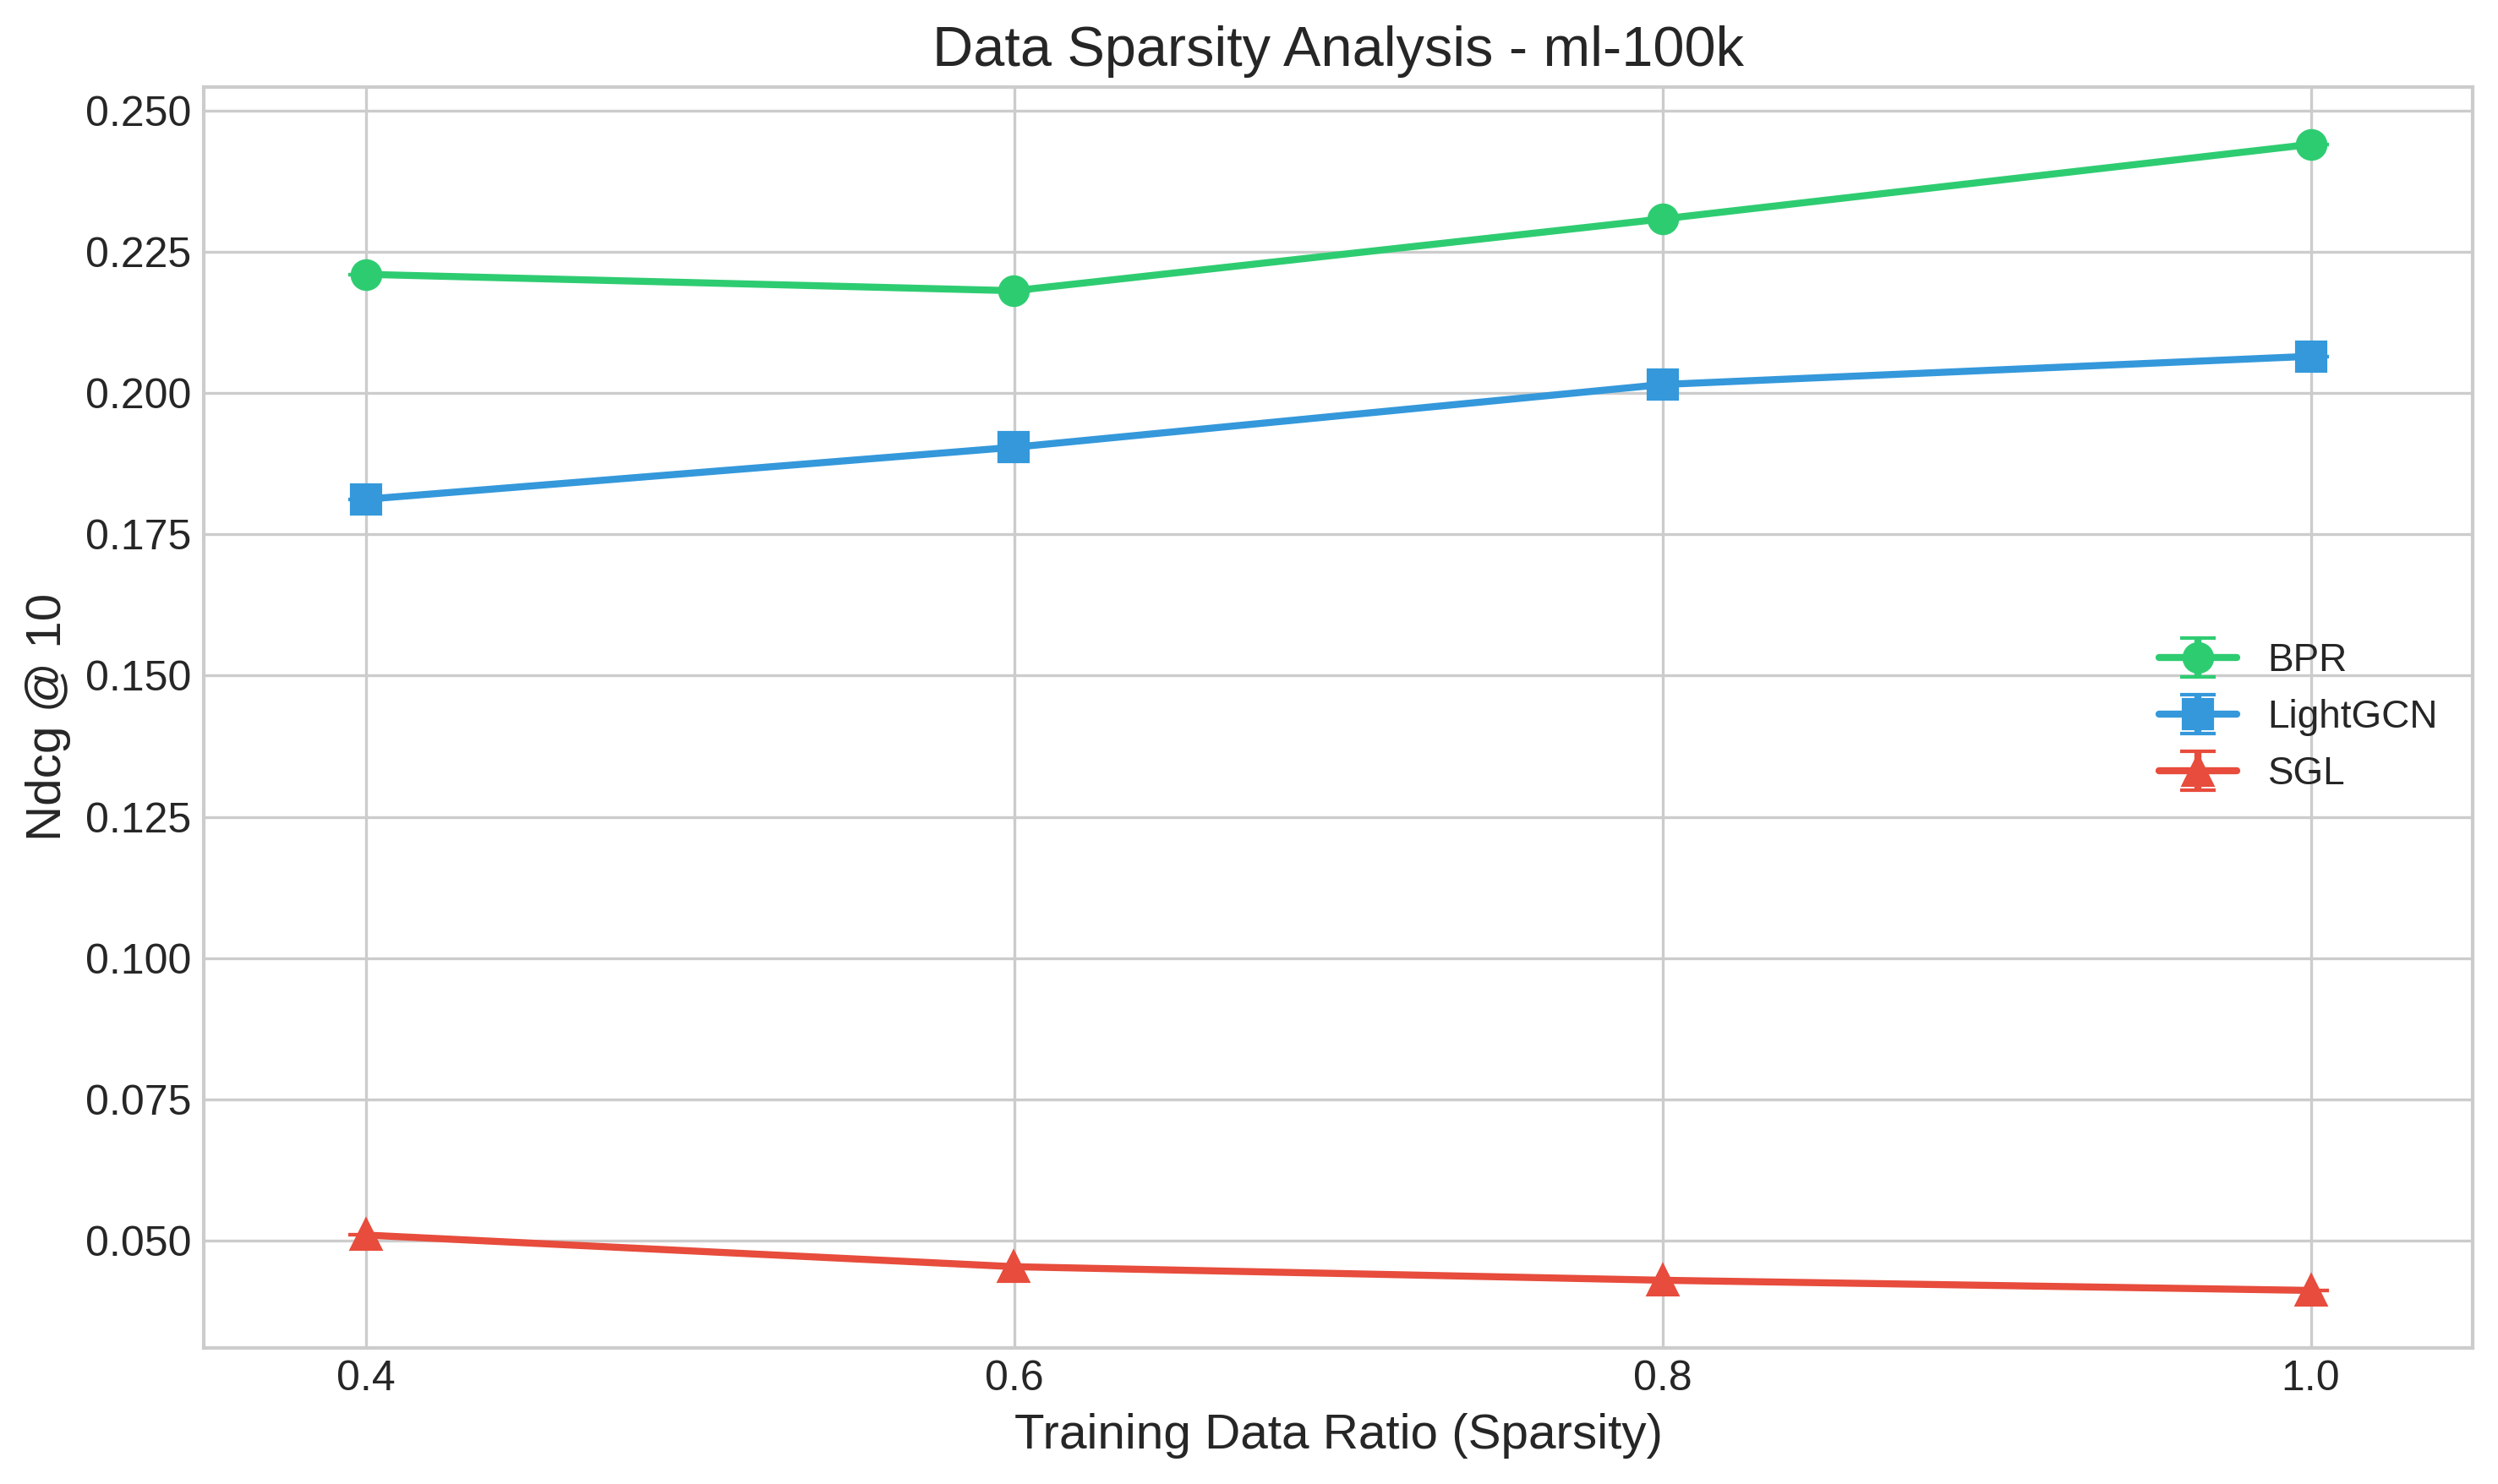


sparsity_ml-100k_recall10.png


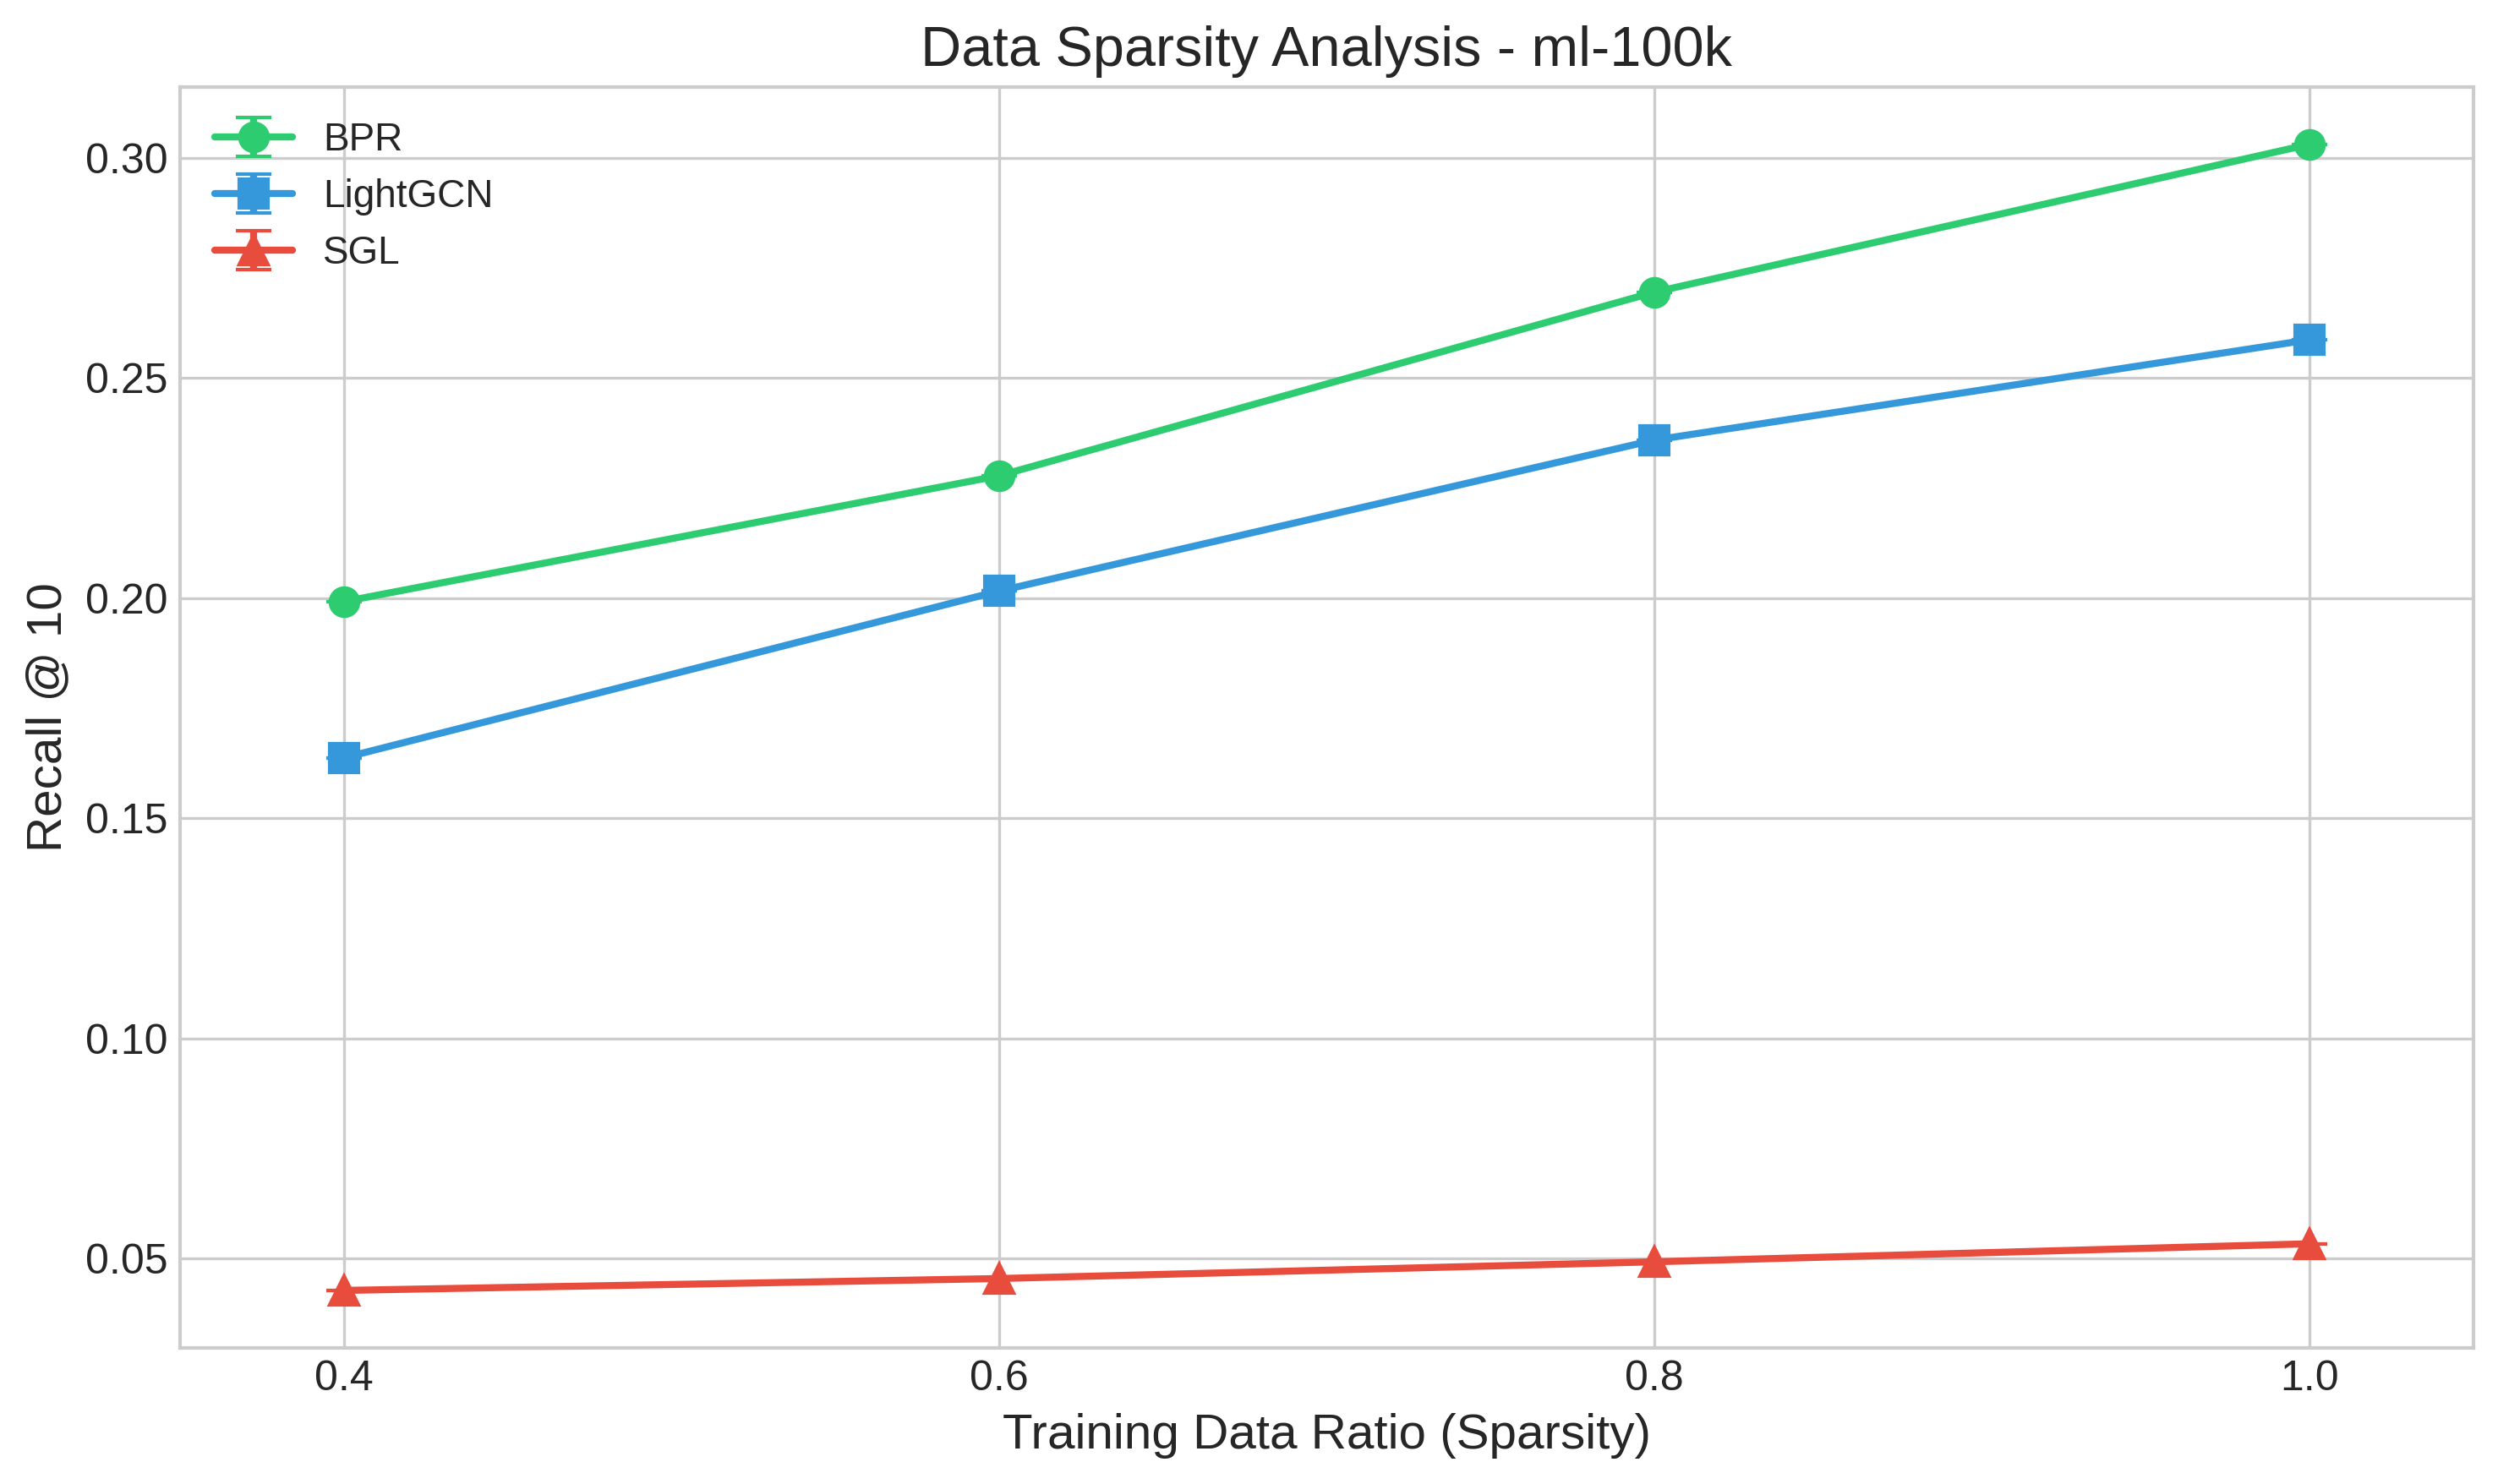


sparsity_modcloth_ndcg10.png


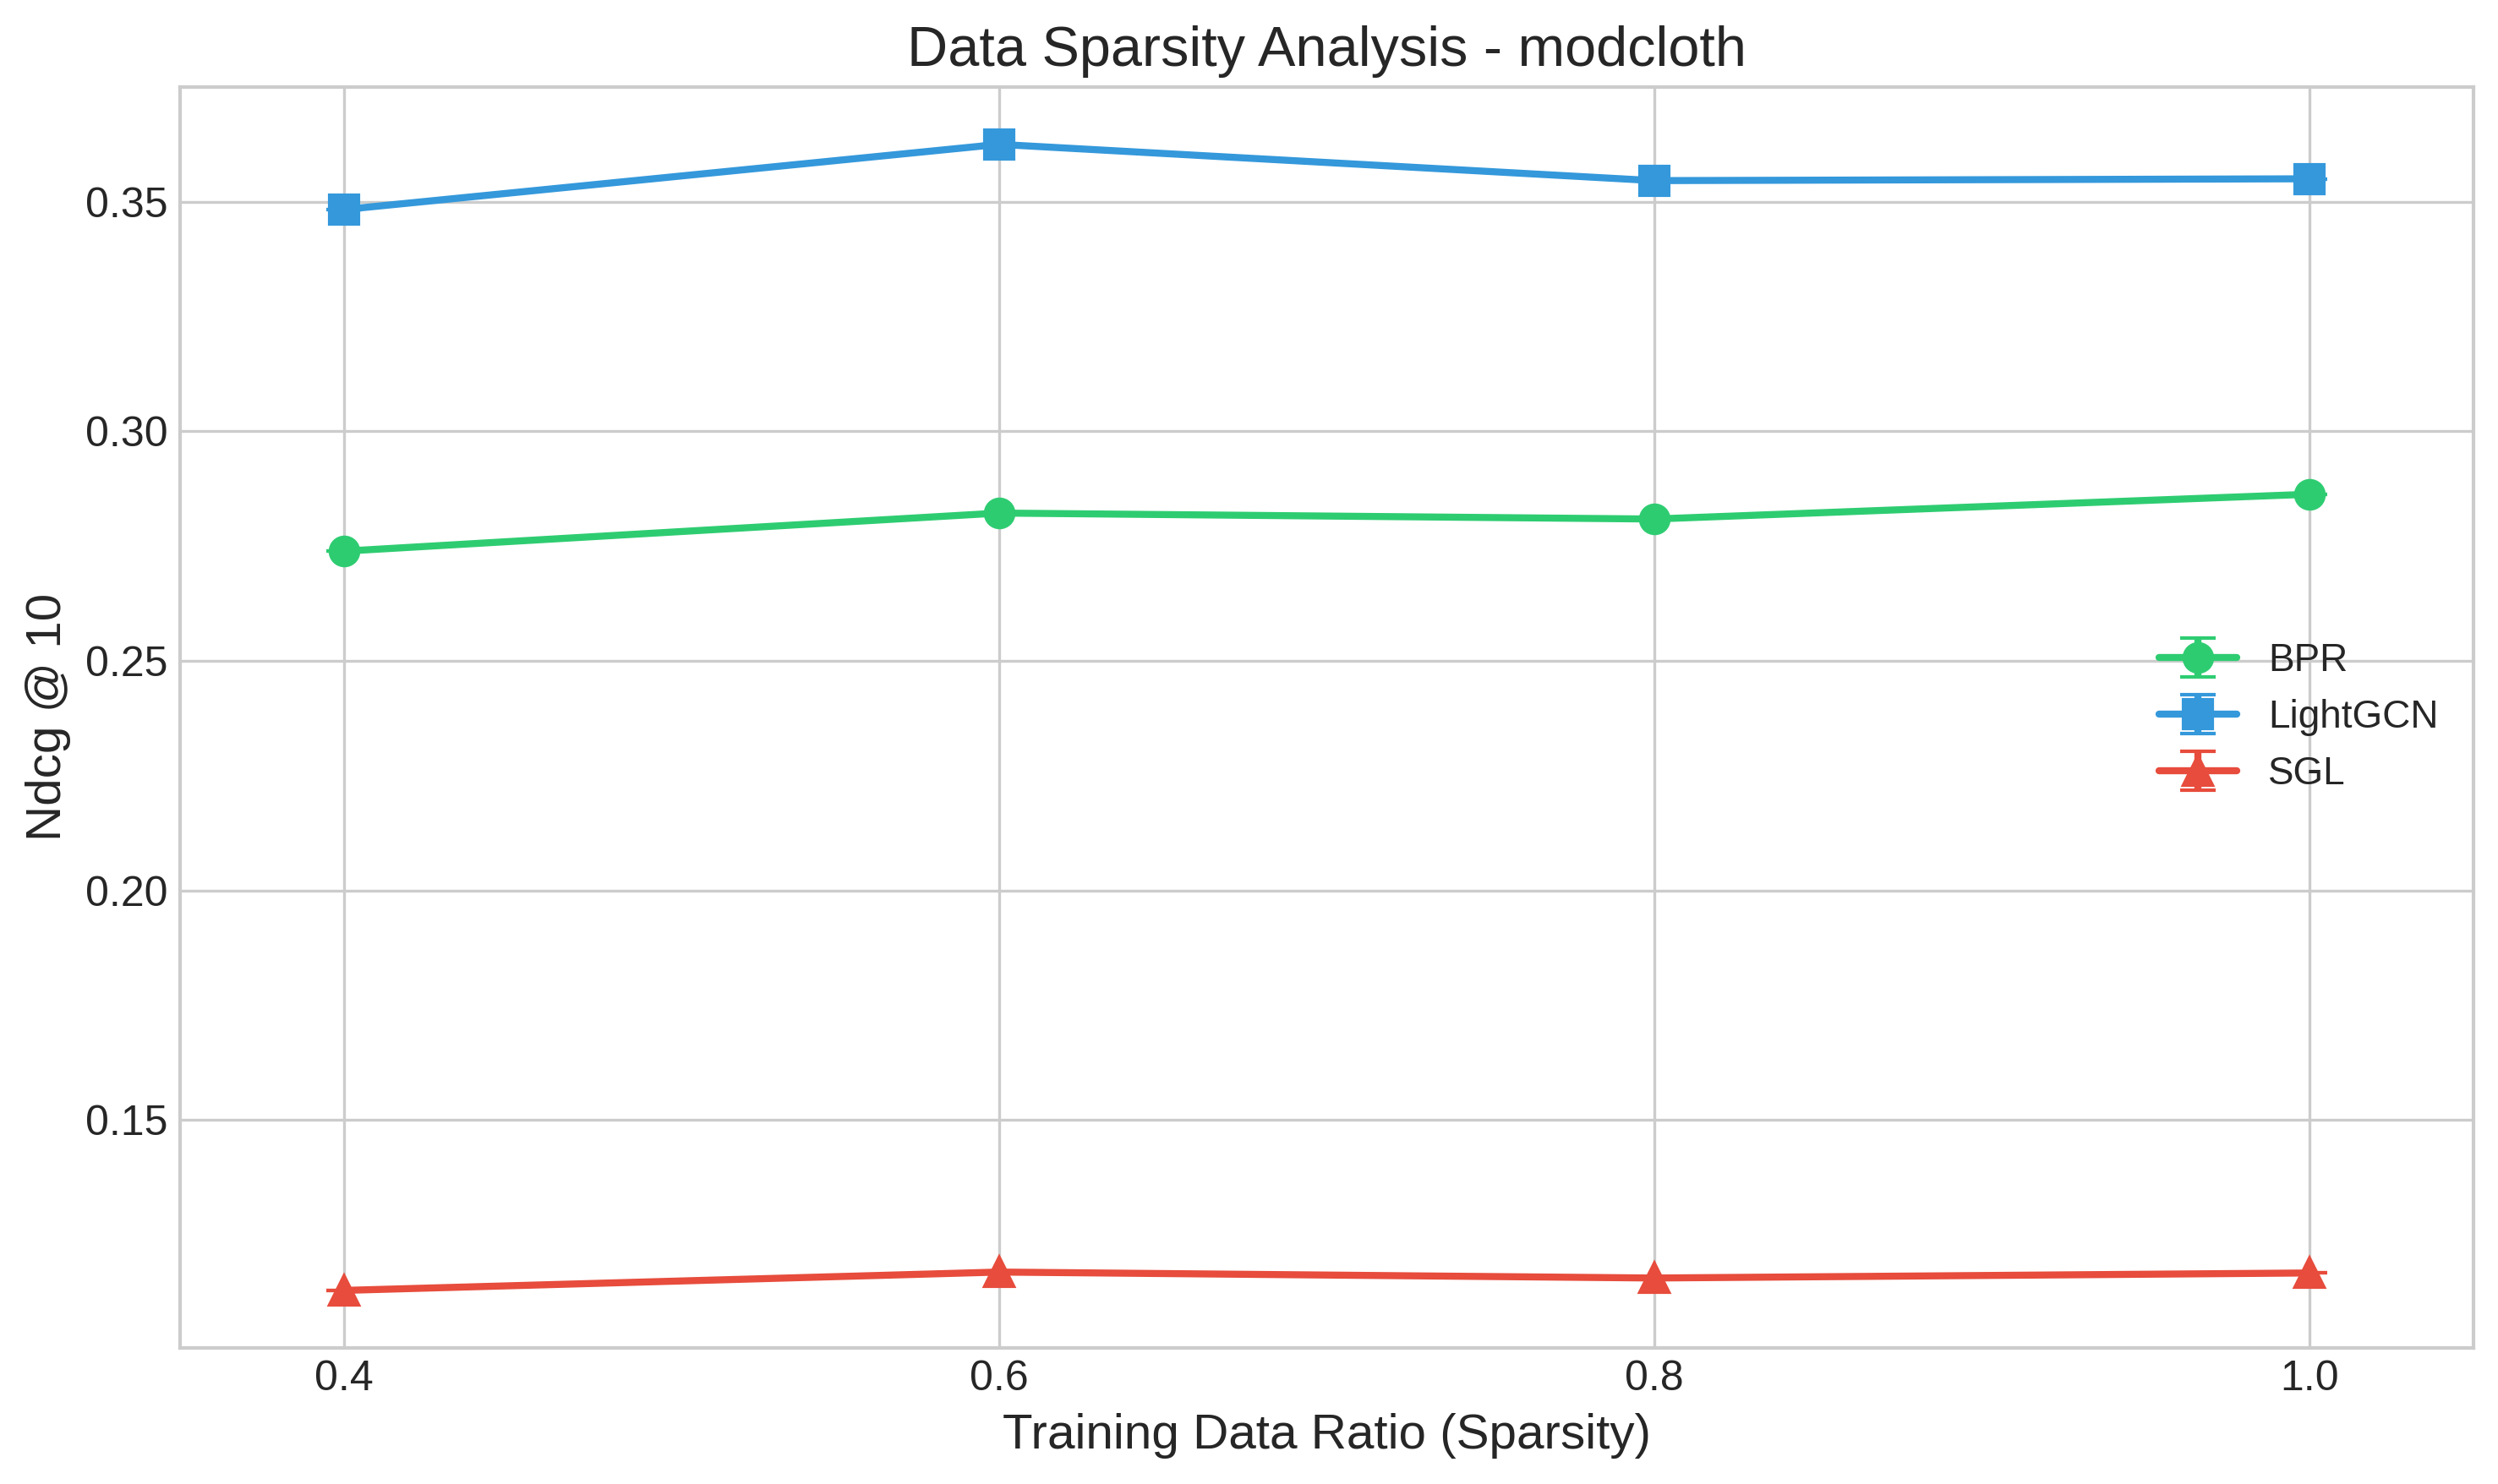


sparsity_modcloth_recall10.png


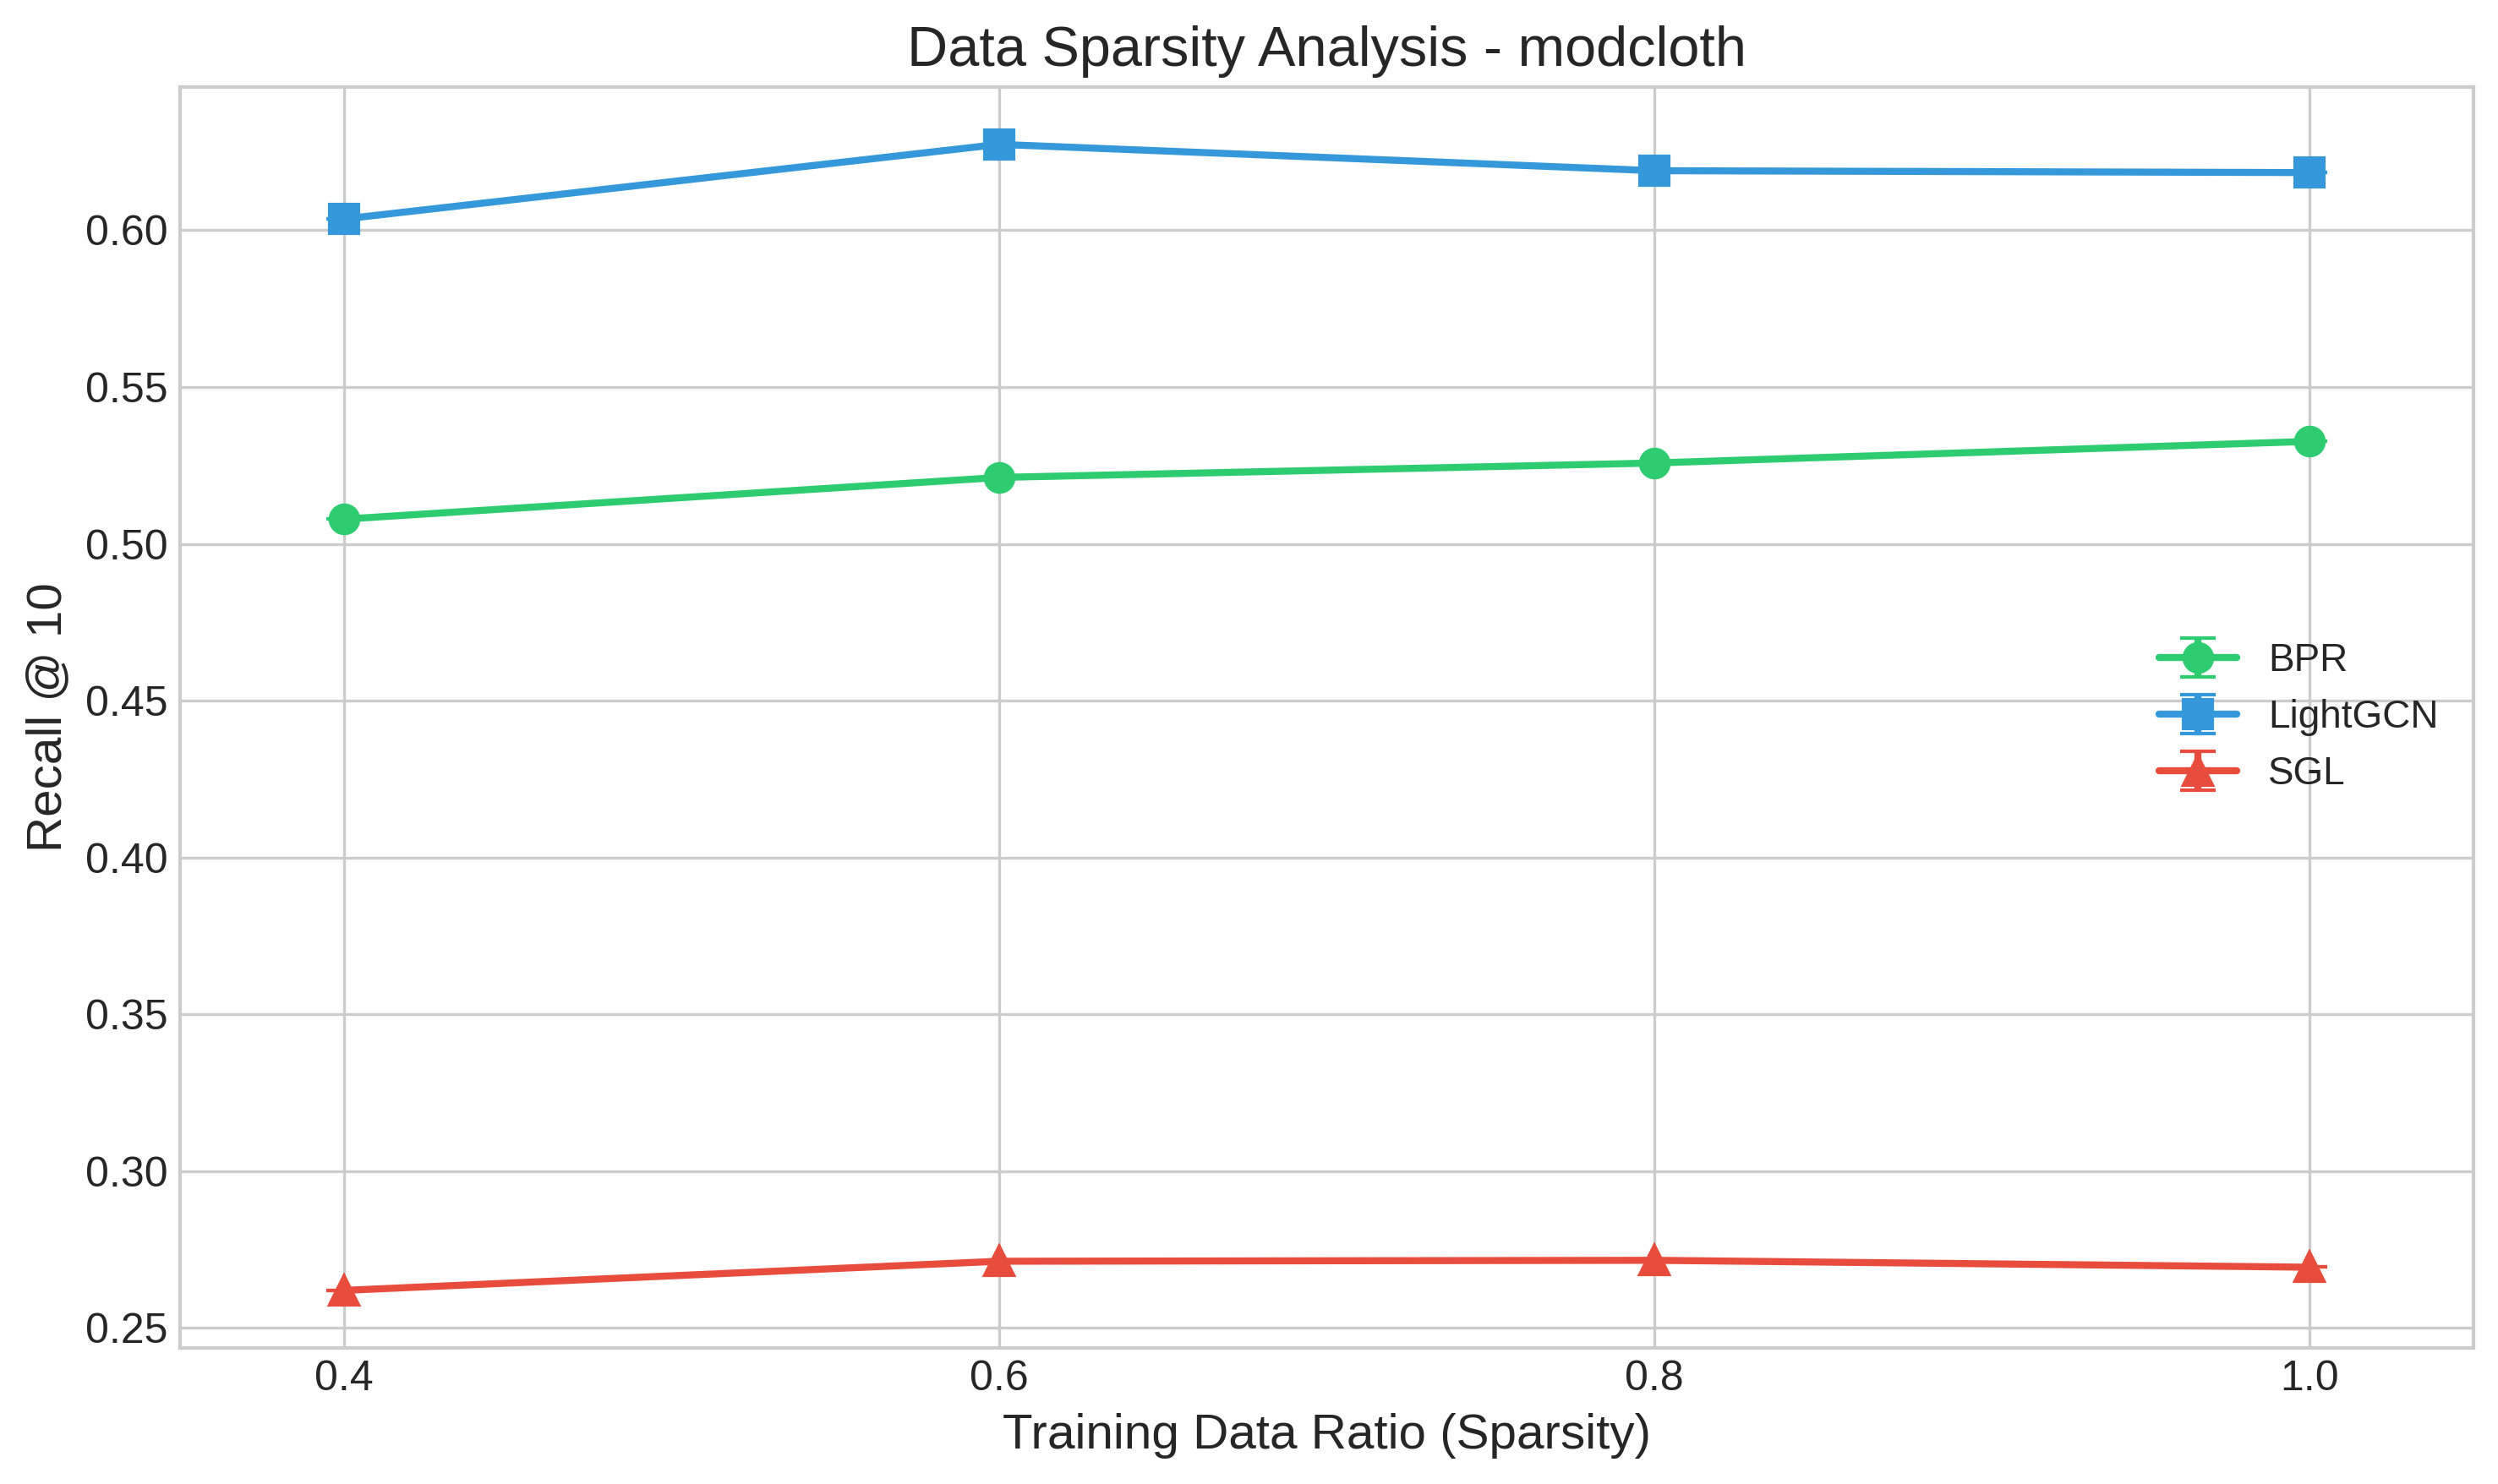

In [59]:
# List all generated figures
import glob
from IPython.display import Image, display

figures = glob.glob(f'{OUTPUT_DIR}/figures/*.png')
print(f"Generated {len(figures)} figures:")
for fig in sorted(figures):
    print(f"  - {fig}")

# Display all figures
for fig_path in sorted(figures):
    print(f"\n{os.path.basename(fig_path)}")
    display(Image(filename=fig_path))

## 13. Long tail analysis

If running in Colab or Jupyter, you can view the saved figures:

In [53]:
print(os.listdir('dataset'))

['.DS_Store', 'amazon-beauty', 'lastfm', 'ModCloth_example', 'README.md', 'modcloth', 'lastfm-example']


In [57]:
import os
result = os.popen('find / -name "ml-100k.inter" 2>/dev/null').read()
print(result)

/usr/local/lib/python3.12/dist-packages/recbole/dataset_example/ml-100k/ml-100k.inter



In [58]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

DATASET_PATHS = {
    'Last.FM':  ('./dataset/lastfm/lastfm.inter',    'user_id:token'),
    'ModCloth': ('./dataset/modcloth/modcloth.inter', 'user_id:token'),
    'ML-100K':  ('/usr/local/lib/python3.12/dist-packages/recbole/dataset_example/ml-100k/ml-100k.inter', 'user_id:token'),
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('User Interaction Degree Distribution', fontsize=16, fontweight='bold', y=1.02)

COLORS = ['#3498db', '#2ecc71', '#e74c3c']

for ax, (name, (path, col)), color in zip(axes, DATASET_PATHS.items(), COLORS):
    df = pd.read_csv(path, sep='\t')
    degrees = df.groupby(col).size()

    ax.hist(degrees, bins=40, color=color, edgecolor='white', linewidth=0.5, alpha=0.85)

    ax.axvline(degrees.mean(),   color='black', linestyle='--', linewidth=1.5, label=f'Mean={degrees.mean():.1f}')
    ax.axvline(degrees.median(), color='gray',  linestyle=':',  linewidth=1.5, label=f'Median={degrees.median():.0f}')

    ax.set_title(name, fontsize=14, fontweight='bold', pad=10)
    ax.set_xlabel('Interactions per User', fontsize=11)
    ax.set_ylabel('Number of Users', fontsize=11)
    ax.legend(fontsize=9, framealpha=0.7)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

    # Print stats below each plot
    print(f"{name}")
    print(f"  Mean:                     {degrees.mean():.2f}")
    print(f"  Median:                   {degrees.median():.2f}")
    print(f"  % users with <= 2:        {(degrees <= 2).mean()*100:.1f}%")
    print(f"  % users with <= 5:        {(degrees <= 5).mean()*100:.1f}%")
    print()

plt.tight_layout()
plt.savefig('results/figures/degree_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

Last.FM
  Mean:                     49.07
  Median:                   50.00
  % users with <= 2:        0.5%
  % users with <= 5:        0.8%

ModCloth
  Mean:                     1.73
  Median:                   1.00
  % users with <= 2:        84.5%
  % users with <= 5:        96.8%

ML-100K
  Mean:                     106.04
  Median:                   65.00
  % users with <= 2:        0.0%
  % users with <= 5:        0.0%



In [47]:
#Downloading all figures
import shutil

shutil.make_archive('figures', 'zip', 'results/figures')

from google.colab import files
files.download('figures.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [60]:
from recbole.quick_start import load_data_and_model
from recbole.utils.case_study import full_sort_topk
import torch

# First re-run a single LightGCN modcloth experiment and save the model
# Add this to your config:
config_dict = {
    **BASE_CONFIG,
    **MODEL_CONFIGS['LightGCN'],
    **DATASET_CONFIGS['modcloth'],
    'checkpoint_dir': 'saved/'
}

result = run_recbole(
    model='LightGCN',
    dataset='modcloth',
    config_dict=config_dict
)

Evaluate   : 100%|███████████████████████| 488/488 [00:37<00:00, 12.91it/s, GPU RAM: 1.70 G/39.49 G]


---

## Notes

### Experiment Parameters
- **Sparsity Analysis**: Tests model robustness by training on 100%, 80%, 60%, 40% of training data
- **Embedding Sensitivity**: Tests embedding dimensions of 32, 64, 128

### Models
- **BPR**: Base model for probability matrix factorisation
- **LightGCN**: Graph-based collaborative filtering (uses BPR loss)
- **SGL**: Self-supervised graph learning (uses BPR loss + contrastive learning)

### Datasets
- **ml-100k**: MovieLens 100K (movies)
- **amazon-beauty**: Amazon Beauty products
- **steam**: Steam video games

### Reproducibility
All experiments use seed=42 by default for reproducibility.